
# TPC drift velocity and \(t_0\) from raw-hit timing QA

Run-by-run comparison of the new fine-binned TPC timing and PHGarfield-\(z\) histograms.

The notebook is organized around the two physical edges:

- **Pad-plane / \(t_0\) edge**: rising edge near raw time bin \(\sim 8\).
- **Central-membrane edge**: falling edge near raw time bin \(\sim 250{-}270\).

For each run and side we:
1. read the 1000-bin timing and PHGarfield-\(z\) histograms;
2. keep the physical upper branch of the PHGarfield-z distribution and reject nonphysical downward dropouts;
3. estimate and subtract the smooth out-of-drift background (important for p+p);
4. compare p+p and Au+Au on the same normalized scale;
5. extract \(t_0\), the CM time, and
\[
v_{\rm drift}^{\rm data}
=
\frac{z_{\rm pad}}
{(t_{\rm CM}-t_0)\,\Delta t_{\rm bin}};
\]
6. inspect the same edges in PHGarfield \(z\), where the CM edge should be near \(z=0\);
7. repeat the edge extraction fee-by-fee using the 2D QA histograms.

The PHGarfield \(z\) histograms already include the run-dependent \(P/T\) effective-field correction used in the reconstruction QA.

FEE edition: histogram loading and channel grouping use `PHGarfieldDriftVelocityQA`;
plot styling, numerical windows, background models, and edge extraction are unchanged.


In [1]:

# ============================================================
# Imports / ROOT style
# ============================================================

from pathlib import Path
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import ROOT as root

root.gROOT.SetBatch(True)
root.TH1.AddDirectory(False)
root.gStyle.SetOptStat(0)

plt.rcParams["figure.figsize"] = (11, 6)
plt.rcParams["font.size"] = 13
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.25

print("ROOT:", root.gROOT.GetVersion())


Welcome to JupyROOT 6.30/06
ROOT: 6.30/06


In [2]:

# ============================================================
# USER CONFIGURATION
# ============================================================

INPUT_DIR = Path("input/qa0")
OUTPUT_DIR = Path("plots_drift_t0")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Merged run-by-run files from the DriftQA production.
FILE_PATTERN = "QA4_{run}.root"

# Edit these lists freely. Missing files are skipped automatically.
PP_RUNS = [
    79508, 79509, 79510, 79511, 79512, 79513, 79514, 79515, 79516,
    79522, 79523, 79524, 79525, 79526, 79527, 79528, 79529, 79530,
    81558, 81566, 80892, 80909
]
AUAU_RUNS = [76905]

RUN_GROUPS = {
    "p+p": PP_RUNS,
    "Au+Au": AUAU_RUNS,
}

SIDE_LABEL = {0: "South", 1: "North"}

# Histogram names written by standalone PHGarfieldDriftVelocityQA.
# Side profiles are summed over the 312 FEE columns in load_run().
H_TIME_FEE = "h_PHGarfieldDriftVelocityQA_h_adc_tbin_vs_fee_side{side}"
H_Z_FEE = "h_PHGarfieldDriftVelocityQA_h_adc_z_vs_fee_side{side}"

# TPC / conversion constants.
TPC_TIME_BIN_NS = 56.8
Z_PAD_CM = 102.605
CM_HALF_WIDTH_CM = 0.28
DRIFT_LENGTH_CM = Z_PAD_CM - CM_HALF_WIDTH_CM  # 102.325 cm

# --- time plots / edge extraction ---
TIME_FULL_XLIM = (0, 1000)

T0_ZOOM = (2, 18)
T0_LEFT_LEVEL = (2.5, 5.5)
T0_RIGHT_LEVEL = (12.0, 16.0)
T0_SEARCH = (5.0, 14.0)
T0_EXPECTED = 8.0

CM_ZOOM = (210, 290)
CM_LEFT_LEVEL = (180, 225)
CM_RIGHT_LEVEL = (300, 360)
CM_SEARCH = (210, 290)
CM_EXPECTED = 250.0

# Smooth background fit for full-profile comparison.
TIME_BG_WINDOWS = [(320, 400), (450, 650), (750, 950)]
TIME_BG_POLY_DEGREE = 2

# Normalize background-subtracted signal here.
TIME_SIGNAL_NORM_WINDOW = (40, 210)

# Very light cleaning: 3-bin median removes isolated one-bin spikes
# without washing out the t0 / CM step.
USE_MEDIAN_CLEAN = True
MEDIAN_WIDTH = 3

# --- folded PHGarfield-z coordinate ---
# u = +z for North and -z for South.
Z_FULL_XLIM = (-25, 125)

Z_CM_ZOOM = (-15, 15)
Z_CM_LEFT_LEVEL = (-15, -5)
Z_CM_RIGHT_LEVEL = (5, 15)
Z_CM_SEARCH = (-8, 8)
Z_CM_EXPECTED = 0.0

Z_PAD_ZOOM = (92, 115)
Z_PAD_LEFT_LEVEL = (92, 98)
Z_PAD_RIGHT_LEVEL = (108, 115)
Z_PAD_SEARCH = (97, 108)
Z_PAD_EXPECTED = Z_PAD_CM

Z_BG_WINDOWS = [(-25, -5), (110, 125)]
Z_BG_POLY_DEGREE = 1

# IMPORTANT:
# The raw PHGarfield-z histogram contains nonphysical downward branches/dropouts.
# Do NOT average/rebin them into the physical branch.
#
# Instead, in consecutive ~1 cm z windows (about 4 original 0.26-cm bins),
# keep the ORIGINAL point with the largest ADC. This follows the upper/physical
# branch and rejects the discrete low-ADC aliases.
#
# Windows are split at the two physical boundaries u=0 (CM) and u=Z_PAD_CM
# so the maximum selection never bridges across a real edge.
Z_MAX_WINDOW_CM = 1.05

# Optional second-stage rejection on the selected upper branch.
# A selected point is rejected only if it is a strong isolated downward dropout
# relative to neighboring selected maxima. Set to None to disable.
Z_SELECTED_DROPOUT_FRACTION = 0.80
Z_SELECTED_NEIGHBORS = 2


# ------------------------------------------------------------
# z-background model for the pad-plane edge
# ------------------------------------------------------------
# p+p background is large (~the level seen at u<0) and slowly changes with z.
#
# Use ONLY two background-controlled regions:
#   1) u < 0        -> determines the background SLOPE
#   2) 103-105 cm   -> determines the background LEVEL near the pad plane
#
# Do NOT use the later ~106+ cm drop to zero: that is not the physical
# background and must not be used as an anchor.
Z_BG_NEGATIVE_FIT_WINDOW = (-25.0, -2.0)
Z_BG_PAD_ANCHOR_WINDOW = (103.0, 105.0)

# For the background-subtracted pad-plane edge:
# before the first crack = signal+background,
# 103-105 cm            = background only.
Z_PAD_BG_LEFT_WINDOW = (97.0, 100.5)
Z_PAD_BG_RIGHT_WINDOW = Z_BG_PAD_ANCHOR_WINDOW
Z_PAD_BG_SEARCH = (100.0, 104.9)

# Only used as a diagnostic / preferred crossing location.
Z_PAD_CRACK_SEARCH = (100.0, 104.9)
Z_PAD_CRACK_MIN_REL_DROP = 0.02

# ------------------------------------------------------------
# CDB comparison file
# ------------------------------------------------------------
# This is the file shown in ROOT in the drift-velocity study. The code below
# tries these paths in order so it also works if the notebook is moved.

# ------------------------------------------------------------
# CDB comparison file
# ------------------------------------------------------------
# This is the file shown in ROOT in the drift-velocity study. The code below
# tries these paths in order so it also works if the notebook is moved.
CDB_REFERENCE_FILE_CANDIDATES = [
    Path("../distort/code/dv/input/tpc_dv_postprocess_whole.root"),
    Path("input/tpc_dv_postprocess_whole.root"),
    Path("tpc_dv_postprocess_whole.root"),
]

#CDB_DV_GRAPH_NAME = "g_cdb"
CDB_DV_GRAPH_NAME = "g_cdb_t0corr"
#CDB_DV_GRAPH_NAME = "g_mean_combined"
CDB_T0_GRAPH_NAME = "g_cdb_t0_ns"
# CDB t0 is stored with the signed ns convention used by reconstruction.
# For direct comparison with the observed positive raw-time-bin edge:
#     raw t0 bin = - t0_CDB[ns] / 56.8 ns
CDB_T0_NS_TO_RAW_BIN_SIGN = -1.0

SAVE_FIGURES = True



## ROOT helpers

The QA manager may store histograms either at the file top level or inside a directory.  
The recursive lookup below handles both.

All ROOT histograms are immediately converted to NumPy arrays so the input files can be closed safely.


In [3]:

# ============================================================
# ROOT / NumPy helpers
# ============================================================

def resolve_run_file(run):
    preferred = INPUT_DIR / FILE_PATTERN.format(run=run)
    if preferred.exists():
        return preferred

    matches = sorted(INPUT_DIR.glob(f"*{run}*.root"))
    if len(matches) == 1:
        return matches[0]
    if len(matches) > 1:
        qa3 = [p for p in matches if p.name.startswith("QA3_")]
        if len(qa3) == 1:
            return qa3[0]
        print(f"WARNING run {run}: multiple files found:")
        for p in matches:
            print("  ", p)
        return matches[0]
    return None


def find_root_object(directory, name):
    obj = directory.Get(name)
    if obj:
        return obj

    keys = directory.GetListOfKeys()
    if not keys:
        return None

    for key in keys:
        cls = root.gROOT.GetClass(key.GetClassName())
        if cls and cls.InheritsFrom("TDirectory"):
            sub = directory.Get(key.GetName())
            found = find_root_object(sub, name)
            if found:
                return found
    return None


def th1_to_numpy(h):
    n = h.GetNbinsX()
    x = np.array([h.GetXaxis().GetBinCenter(i) for i in range(1, n + 1)], dtype=float)
    y = np.array([h.GetBinContent(i) for i in range(1, n + 1)], dtype=float)
    e = np.array([h.GetBinError(i) for i in range(1, n + 1)], dtype=float)
    return x, y, e


def th2_to_numpy(h):
    nx = h.GetNbinsX()
    ny = h.GetNbinsY()

    x = np.array([h.GetXaxis().GetBinCenter(i) for i in range(1, nx + 1)], dtype=float)
    y = np.array([h.GetYaxis().GetBinCenter(i) for i in range(1, ny + 1)], dtype=float)

    values = np.empty((ny, nx), dtype=float)
    for iy in range(1, ny + 1):
        for ix in range(1, nx + 1):
            values[iy - 1, ix - 1] = h.GetBinContent(ix, iy)

    labels = [h.GetXaxis().GetBinLabel(i) for i in range(1, nx + 1)]
    return x, y, values, labels


def load_run(run):
    path = resolve_run_file(run)
    if path is None:
        print(f"SKIP run {run}: no ROOT file found in {INPUT_DIR}")
        return None

    f = root.TFile.Open(str(path), "READ")
    if not f or f.IsZombie():
        print(f"SKIP run {run}: cannot open {path}")
        return None

    out = {"path": path, "time": {}, "time_fee": {}, "z": {}, "z_fee": {}}

    for side in (0, 1):
        names = {
            "time_fee": H_TIME_FEE.format(side=side),
            "z_fee": H_Z_FEE.format(side=side),
        }

        for kind, name in names.items():
            h = find_root_object(f, name)
            if not h:
                print(f"WARNING run {run}: missing {name}")
                continue
            if not h.InheritsFrom("TH2"):
                raise TypeError(f"{name} is not a TH2 histogram")
            if h.GetNbinsX() != 312:
                raise ValueError(f"{name}: expected 312 FEEs, got {h.GetNbinsX()}")

            out[kind][side] = th2_to_numpy(h)
            # Sum only physical FEE bins. ROOT propagates the stored bin errors.
            # This recreates the side-level TH1 expected by all existing plots.
            profile = h.ProjectionY(
                f"profile_{kind}_run{run}_side{side}", 1, h.GetNbinsX(), "e"
            )
            profile.SetDirectory(0)
            out[kind.removesuffix("_fee")][side] = th1_to_numpy(profile)

    f.Close()
    print(f"loaded run {run}: {path}")
    return out


def window_mask(x, window):
    return (x >= window[0]) & (x <= window[1])


def window_median(x, y, window):
    m = window_mask(x, window) & np.isfinite(y)
    if not np.any(m):
        return np.nan
    return float(np.median(y[m]))


def median_smooth(y, width=3):
    y = np.asarray(y, dtype=float)
    if width <= 1:
        return y.copy()
    if width % 2 == 0:
        raise ValueError("median width must be odd")

    half = width // 2
    yp = np.pad(y, (half, half), mode="edge")
    return np.array([np.median(yp[i:i + width]) for i in range(len(y))], dtype=float)


def display_clean(y):
    return median_smooth(y, MEDIAN_WIDTH) if USE_MEDIAN_CLEAN else np.asarray(y, dtype=float).copy()


In [4]:

# ============================================================
# Load all available requested runs
# ============================================================

DATA = {}
GROUP_OF_RUN = {}

for group, runs in RUN_GROUPS.items():
    for run in runs:
        if run in DATA:
            continue
        loaded = load_run(run)
        if loaded is not None:
            DATA[run] = loaded
            GROUP_OF_RUN[run] = group

AVAILABLE_RUNS = sorted(DATA)

print()
print("Available runs:", AVAILABLE_RUNS)

if not AVAILABLE_RUNS:
    raise RuntimeError("No requested QA ROOT files were found. Edit INPUT_DIR / run lists above.")


SKIP run 79508: no ROOT file found in input/qa0
loaded run 79509: input/qa0/QA4_79509.root
loaded run 79510: input/qa0/QA4_79510.root
loaded run 79511: input/qa0/QA4_79511.root
loaded run 79512: input/qa0/QA4_79512.root
loaded run 79513: input/qa0/QA4_79513.root
loaded run 79514: input/qa0/QA4_79514.root
loaded run 79515: input/qa0/QA4_79515.root
loaded run 79516: input/qa0/QA4_79516.root
SKIP run 79522: no ROOT file found in input/qa0
SKIP run 79523: no ROOT file found in input/qa0
SKIP run 79524: no ROOT file found in input/qa0
SKIP run 79525: no ROOT file found in input/qa0
WARNING run 79526: missing h_PHGarfieldDriftVelocityQA_h_adc_tbin_vs_fee_side0
WARNING run 79526: missing h_PHGarfieldDriftVelocityQA_h_adc_z_vs_fee_side0
WARNING run 79526: missing h_PHGarfieldDriftVelocityQA_h_adc_tbin_vs_fee_side1
WARNING run 79526: missing h_PHGarfieldDriftVelocityQA_h_adc_z_vs_fee_side1
loaded run 79526: input/qa0/QA4_79526.root
SKIP run 79527: no ROOT file found in input/qa0
loaded run 7952


## Smooth pedestal/background subtraction

For the **full time profile**, the background is determined only from bins after the central-membrane edge.  
This is especially important for p+p, where the drift signal sits on a large slowly varying background.

A low-order polynomial is fitted robustly with iterative clipping. The exact fit windows are kept in the configuration cell.

For the actual \(t_0\) and CM edge positions, the notebook additionally uses **local left/right levels** around each edge. This avoids bias from a long-range pedestal model.


In [5]:

# ============================================================
# Background fit + edge extraction
# ============================================================

def robust_poly_background(x, y, windows, degree=1, n_iter=5, clip_sigma=4.0):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)

    base = np.zeros_like(x, dtype=bool)
    for w in windows:
        base |= window_mask(x, w)
    base &= np.isfinite(y)

    if np.count_nonzero(base) < degree + 2:
        return np.zeros_like(y), np.full(degree + 1, np.nan), base

    fit_mask = base.copy()

    for _ in range(n_iter):
        p = np.polyfit(x[fit_mask], y[fit_mask], degree)
        pred = np.polyval(p, x)

        r = y - pred
        rr = r[fit_mask]
        med = np.median(rr)
        mad = np.median(np.abs(rr - med))
        sigma = 1.4826 * mad

        if not np.isfinite(sigma) or sigma <= 0:
            break

        new_mask = base & (np.abs(r - med) < clip_sigma * sigma)
        if np.array_equal(new_mask, fit_mask):
            break
        if np.count_nonzero(new_mask) < degree + 2:
            break
        fit_mask = new_mask

    p = np.polyfit(x[fit_mask], y[fit_mask], degree)
    return np.polyval(p, x), p, fit_mask


def interpolate_crossing(x1, y1, x2, y2, target):
    if y2 == y1:
        return 0.5 * (x1 + x2)
    return x1 + (target - y1) * (x2 - x1) / (y2 - y1)


def find_crossing(x, y, target, search_window, expected=None):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)

    m = window_mask(x, search_window) & np.isfinite(y)
    xx = x[m]
    yy = y[m]

    if len(xx) < 2:
        return np.nan

    candidates = []
    for i in range(len(xx) - 1):
        a = yy[i] - target
        b = yy[i + 1] - target
        if a == 0:
            candidates.append(xx[i])
        elif a * b <= 0:
            candidates.append(interpolate_crossing(xx[i], yy[i], xx[i + 1], yy[i + 1], target))

    if not candidates:
        return float(xx[np.nanargmin(np.abs(yy - target))])

    if expected is None:
        return float(candidates[0])

    return float(min(candidates, key=lambda value: abs(value - expected)))


def edge_metrics(x, y, left_window, right_window, search_window, expected=None):
    # Works for rising and falling edges.
    # fraction=0 is the left-side level; fraction=1 is the right-side level.
    yy = display_clean(y)

    left = window_median(x, yy, left_window)
    right = window_median(x, yy, right_window)

    result = {
        "left_level": left,
        "right_level": right,
        "x10": np.nan,
        "x50": np.nan,
        "x90": np.nan,
        "width_10_90": np.nan,
    }

    if not np.isfinite(left) or not np.isfinite(right) or left == right:
        return result

    xs = {}
    for frac in (0.10, 0.50, 0.90):
        target = left + frac * (right - left)
        xs[frac] = find_crossing(x, yy, target, search_window, expected)

    result["x10"] = xs[0.10]
    result["x50"] = xs[0.50]
    result["x90"] = xs[0.90]
    result["width_10_90"] = abs(xs[0.90] - xs[0.10])
    return result


def normalize_between_levels(y, left_level, right_level):
    denom = right_level - left_level
    if not np.isfinite(denom) or denom == 0:
        return np.full_like(np.asarray(y, dtype=float), np.nan)
    return (np.asarray(y, dtype=float) - left_level) / denom


def subtract_time_background(x, y):
    yy = display_clean(y)
    bg, p, used = robust_poly_background(
        x, yy, TIME_BG_WINDOWS, degree=TIME_BG_POLY_DEGREE
    )
    return yy - bg, bg, p, used


def normalize_drift_signal(x, y_sub):
    level = window_median(x, y_sub, TIME_SIGNAL_NORM_WINDOW)
    if not np.isfinite(level) or level == 0:
        return np.full_like(y_sub, np.nan)
    return y_sub / level


def _select_window_max(x, y, width_cm):
    """
    Keep the ORIGINAL (x,y) point with maximum y in consecutive fixed-width x windows.
    No averaging and no summing.
    """
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)

    if len(x) == 0:
        return x.copy(), y.copy()

    xmin = float(np.min(x))
    xmax = float(np.max(x))

    xs = []
    ys = []

    lo = xmin
    while lo <= xmax:
        hi = lo + width_cm
        # Include the upper endpoint only for the final window.
        if hi >= xmax:
            m = (x >= lo) & (x <= hi)
        else:
            m = (x >= lo) & (x < hi)

        inds = np.flatnonzero(m & np.isfinite(y))
        if len(inds):
            best = inds[np.argmax(y[inds])]
            xs.append(x[best])
            ys.append(y[best])

        lo = hi

    return np.asarray(xs, dtype=float), np.asarray(ys, dtype=float)


def _reject_selected_downward_dropouts(x, y, fraction=0.80, nneighbor=2):
    """
    Second stage for the already selected window maxima.

    Compare each point only to nearby selected maxima. Reject a point if it is
    an isolated strong downward excursion. Endpoints are kept.
    """
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)

    if fraction is None or len(y) < 2 * nneighbor + 1:
        return x.copy(), y.copy()

    keep = np.ones(len(y), dtype=bool)

    for i in range(nneighbor, len(y) - nneighbor):
        neighbors = np.r_[y[i-nneighbor:i], y[i+1:i+nneighbor+1]]
        neighbors = neighbors[np.isfinite(neighbors)]
        if len(neighbors) == 0:
            continue

        # Local physical reference from surrounding upper-branch points.
        ref = np.median(neighbors)

        if np.isfinite(ref) and ref > 0 and y[i] < fraction * ref:
            keep[i] = False

    return x[keep], y[keep]


def select_physical_z_branch(side, z, y):
    """
    Fold to u = |z| convention and keep the upper/physical branch.

    The selection is performed independently in three regions:
      u < 0            : beyond CM / background
      0 <= u <= z_pad  : active drift volume
      u > z_pad        : beyond pad plane

    This prevents the cleaner from smearing the real discontinuities at CM and
    the pad plane.
    """
    sign = +1.0 if side == 1 else -1.0
    u = sign * np.asarray(z, dtype=float)
    yy = np.asarray(y, dtype=float)

    order = np.argsort(u)
    u = u[order]
    yy = yy[order]

    boundaries = [-np.inf, 0.0, Z_PAD_CM, np.inf]

    all_u = []
    all_y = []

    for lo, hi in zip(boundaries[:-1], boundaries[1:]):
        if np.isneginf(lo):
            m = u < hi
        elif np.isposinf(hi):
            m = u > lo
        else:
            # include 0 with active side; include pad-plane boundary here too
            m = (u >= lo) & (u <= hi)

        us = u[m]
        ys = yy[m]
        if len(us) == 0:
            continue

        usel, ysel = _select_window_max(us, ys, Z_MAX_WINDOW_CM)

        usel, ysel = _reject_selected_downward_dropouts(
            usel,
            ysel,
            fraction=Z_SELECTED_DROPOUT_FRACTION,
            nneighbor=Z_SELECTED_NEIGHBORS,
        )

        all_u.append(usel)
        all_y.append(ysel)

    if not all_u:
        return np.array([]), np.array([])

    uout = np.concatenate(all_u)
    yout = np.concatenate(all_y)

    order = np.argsort(uout)
    return uout[order], yout[order]


def select_physical_z_branch_2d(side, z, values):
    """
    Apply the same z upper-branch selection separately to every fee column.

    Returns a list of (u_selected, y_selected) tuples, one per fee.
    """
    out = []
    for imod in range(values.shape[1]):
        out.append(select_physical_z_branch(side, z, values[:, imod]))
    return out


In [6]:
# ============================================================
# z-specific background model for the pad-plane edge
# ============================================================

def robust_line_fit(x, y, fit_window, n_iter=5, clip_sigma=4.0):
    """
    Robust y = slope*x + intercept fit in one x window.
    Used only to determine the z-background slope from u < 0.
    """
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)

    base = window_mask(x, fit_window) & np.isfinite(x) & np.isfinite(y)
    if np.count_nonzero(base) < 3:
        return np.nan, np.nan, base

    keep = base.copy()

    for _ in range(n_iter):
        p = np.polyfit(x[keep], y[keep], 1)
        residual = y - np.polyval(p, x)

        rr = residual[keep]
        med = np.median(rr)
        mad = np.median(np.abs(rr - med))
        sigma = 1.4826 * mad

        if not np.isfinite(sigma) or sigma <= 0:
            break

        new_keep = base & (np.abs(residual - med) < clip_sigma * sigma)
        if np.array_equal(new_keep, keep) or np.count_nonzero(new_keep) < 3:
            break

        keep = new_keep

    p = np.polyfit(x[keep], y[keep], 1)
    return float(p[0]), float(p[1]), keep


def find_first_pad_crack(
    u,
    y,
    search_window=Z_PAD_CRACK_SEARCH,
    min_rel_drop=Z_PAD_CRACK_MIN_REL_DROP,
):
    """
    Find the FIRST significant downward step in the expected pad-plane region.

    We deliberately use the first significant crack, not the largest later drop.
    The upper-branch cleaning has already removed the unrelated low-z aliases.
    """
    u = np.asarray(u, dtype=float)
    y = np.asarray(y, dtype=float)

    m = window_mask(u, search_window) & np.isfinite(y)
    xx = u[m]
    yy = y[m]

    if len(xx) < 2:
        return np.nan

    order = np.argsort(xx)
    xx = xx[order]
    yy = yy[order]

    # Local scale before the edge. This makes the threshold run independent.
    pre = (xx >= search_window[0]) & (xx <= min(search_window[0] + 3.0, search_window[1]))
    scale = np.median(np.abs(yy[pre])) if np.any(pre) else np.median(np.abs(yy))
    if not np.isfinite(scale) or scale <= 0:
        scale = np.nanmax(np.abs(yy))

    dy = np.diff(yy)

    # First clearly negative step.
    for i, dyi in enumerate(dy):
        if dyi < -min_rel_drop * scale:
            return float(0.5 * (xx[i] + xx[i + 1]))

    # Fallback: use the strongest downward step in the search region.
    if len(dy):
        i = int(np.argmin(dy))
        return float(0.5 * (xx[i] + xx[i + 1]))

    return np.nan


def z_background_from_negative_slope_and_pad_anchor(u, y):
    """
    Background model for the cleaned PHGarfield-z upper branch.

    Physics choice:
      - slope comes from the background-only u < 0 region;
      - absolute level comes from the narrow 103-105 cm region, after the
        first pad-plane crack but BEFORE the later nonphysical drop to zero.

    The model is therefore:
        bg(u) = slope*u + intercept
    with 'slope' from u<0 and 'intercept' fixed by 103-105 cm.
    """
    u = np.asarray(u, dtype=float)
    y = np.asarray(y, dtype=float)

    crack = find_first_pad_crack(
        u,
        y,
        search_window=Z_PAD_CRACK_SEARCH,
        min_rel_drop=Z_PAD_CRACK_MIN_REL_DROP,
    )

    slope, neg_intercept, neg_keep = robust_line_fit(
        u, y, Z_BG_NEGATIVE_FIT_WINDOW
    )

    info = {
        "crack_cm": crack,
        "slope_adc_per_cm": slope,
        "negative_fit_intercept": neg_intercept,
        "anchor_u_cm": np.nan,
        "anchor_adc": np.nan,
        "anchor_window": Z_BG_PAD_ANCHOR_WINDOW,
        "intercept_from_anchor": np.nan,
    }

    if not np.isfinite(slope):
        return np.full_like(y, np.nan), info

    anchor = (
        window_mask(u, Z_BG_PAD_ANCHOR_WINDOW)
        & np.isfinite(u)
        & np.isfinite(y)
    )

    if np.count_nonzero(anchor) < 1:
        return np.full_like(y, np.nan), info

    # Fix the line level using all selected points in 103-105 cm.
    # For a known slope, every point gives intercept_i = y_i - slope*u_i.
    intercept = float(np.median(y[anchor] - slope * u[anchor]))

    anchor_u = float(np.median(u[anchor]))
    anchor_y = float(np.median(y[anchor]))

    bg = slope * u + intercept

    info["anchor_u_cm"] = anchor_u
    info["anchor_adc"] = anchor_y
    info["intercept_from_anchor"] = intercept

    return bg, info


def z_pad_edge_after_background(u, y_sub, crack):
    """
    Extract the pad-plane signal edge after the corrected z-background subtraction.

    The right-side level is explicitly taken from 103-105 cm.
    The search stops below 105 cm so the later nonphysical drop to zero cannot
    be mistaken for the pad-plane edge.
    """
    u = np.asarray(u, dtype=float)
    y_sub = np.asarray(y_sub, dtype=float)

    left = window_median(u, y_sub, Z_PAD_BG_LEFT_WINDOW)
    right = window_median(u, y_sub, Z_PAD_BG_RIGHT_WINDOW)

    out = {
        "left_level": left,
        "right_level": right,
        "x10": np.nan,
        "x50": np.nan,
        "x90": np.nan,
        "width_10_90": np.nan,
        "left_window": Z_PAD_BG_LEFT_WINDOW,
        "right_window": Z_PAD_BG_RIGHT_WINDOW,
        "search_window": Z_PAD_BG_SEARCH,
    }

    if not np.isfinite(left) or not np.isfinite(right) or left == right:
        return out

    expected = crack if np.isfinite(crack) else Z_PAD_CM

    crossings = {}
    for frac in (0.10, 0.50, 0.90):
        target = left + frac * (right - left)
        crossings[frac] = find_crossing(
            u,
            y_sub,
            target,
            Z_PAD_BG_SEARCH,
            expected=expected,
        )

    out["x10"] = crossings[0.10]
    out["x50"] = crossings[0.50]
    out["x90"] = crossings[0.90]
    out["width_10_90"] = abs(crossings[0.90] - crossings[0.10])

    return out


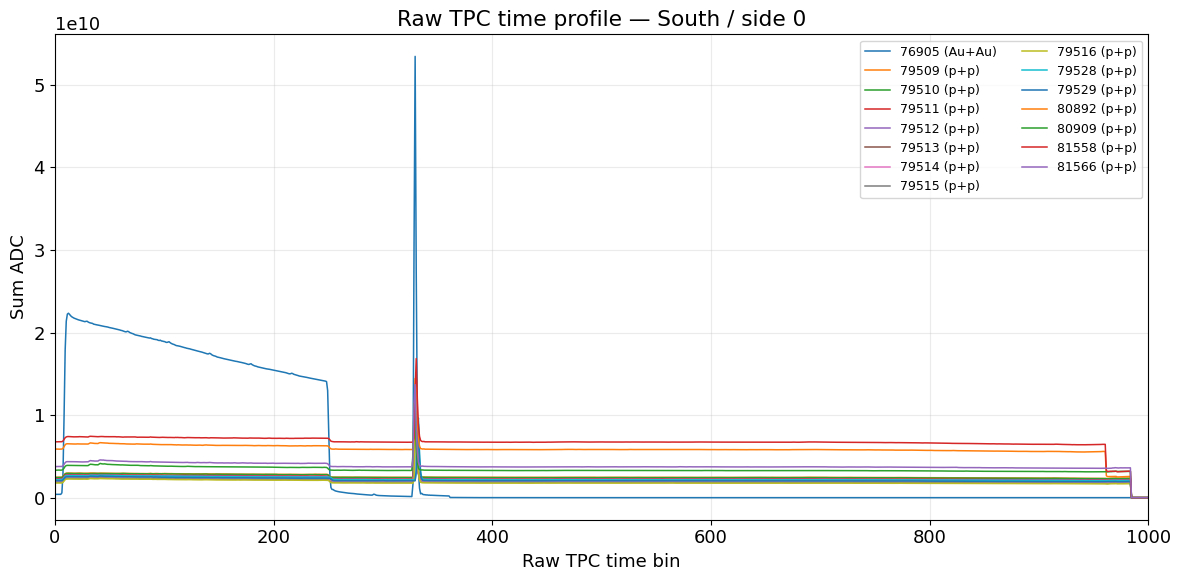

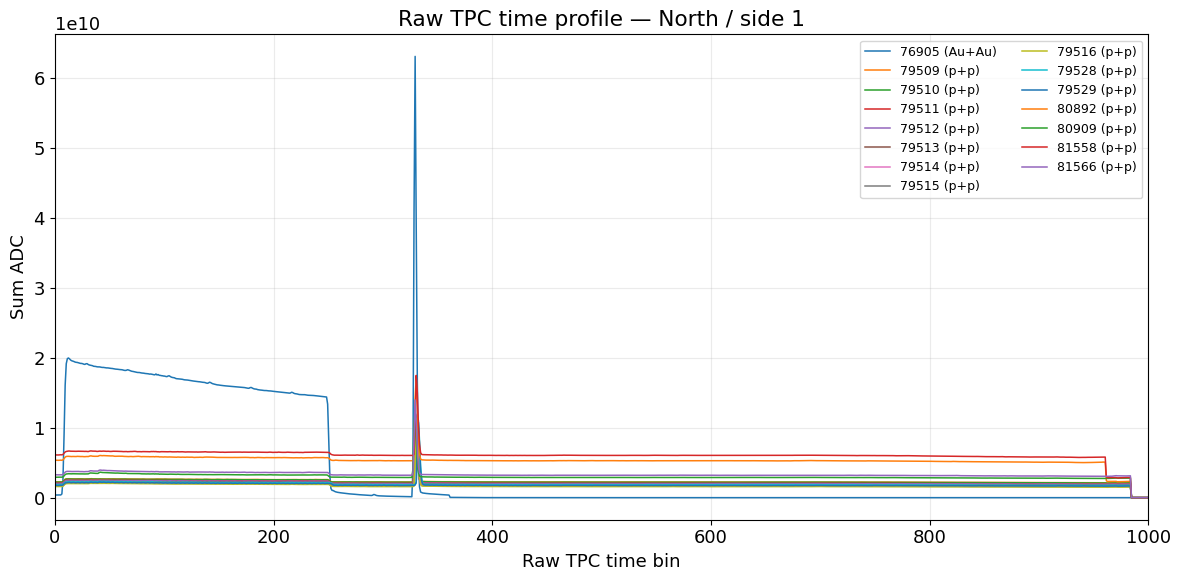

In [7]:

# ============================================================
# 1. Raw full time profiles
# ============================================================

for side in (0, 1):
    fig, ax = plt.subplots(figsize=(12, 6))

    for run in AVAILABLE_RUNS:
        if side not in DATA[run]["time"]:
            continue
        x, y, _ = DATA[run]["time"][side]
        ax.plot(x, y, lw=1.1, label=f"{run} ({GROUP_OF_RUN[run]})")

    ax.set_xlim(*TIME_FULL_XLIM)
    ax.set_xlabel("Raw TPC time bin")
    ax.set_ylabel("Sum ADC")
    ax.set_title(f"Raw TPC time profile — {SIDE_LABEL[side]} / side {side}")
    ax.legend(fontsize=9, ncol=2)
    fig.tight_layout()

    if SAVE_FIGURES:
        fig.savefig(OUTPUT_DIR / f"time_raw_side{side}.png", dpi=160)
        fig.savefig(OUTPUT_DIR / f"time_raw_side{side}.pdf")

    plt.show()


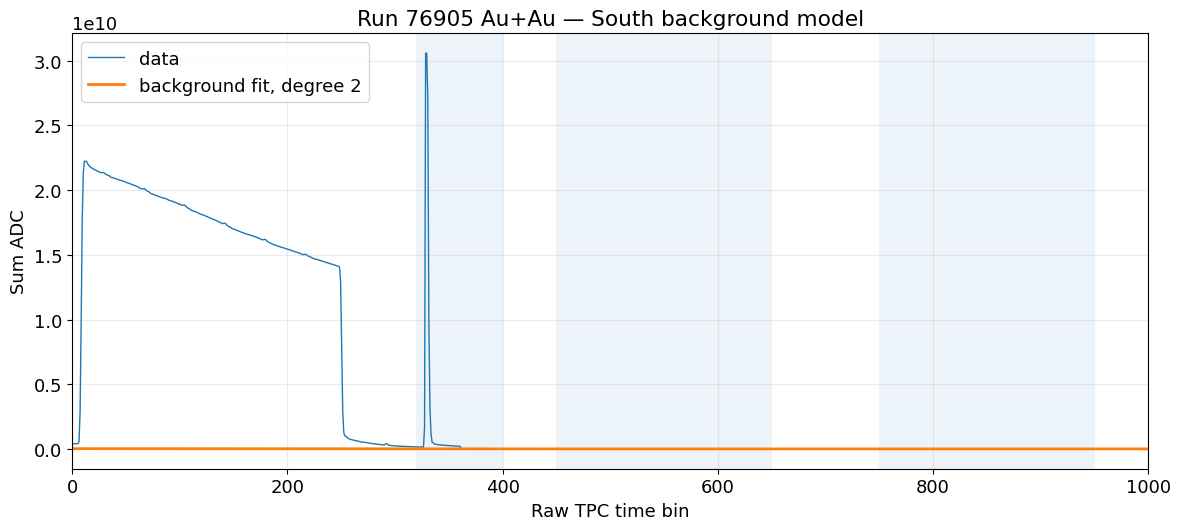

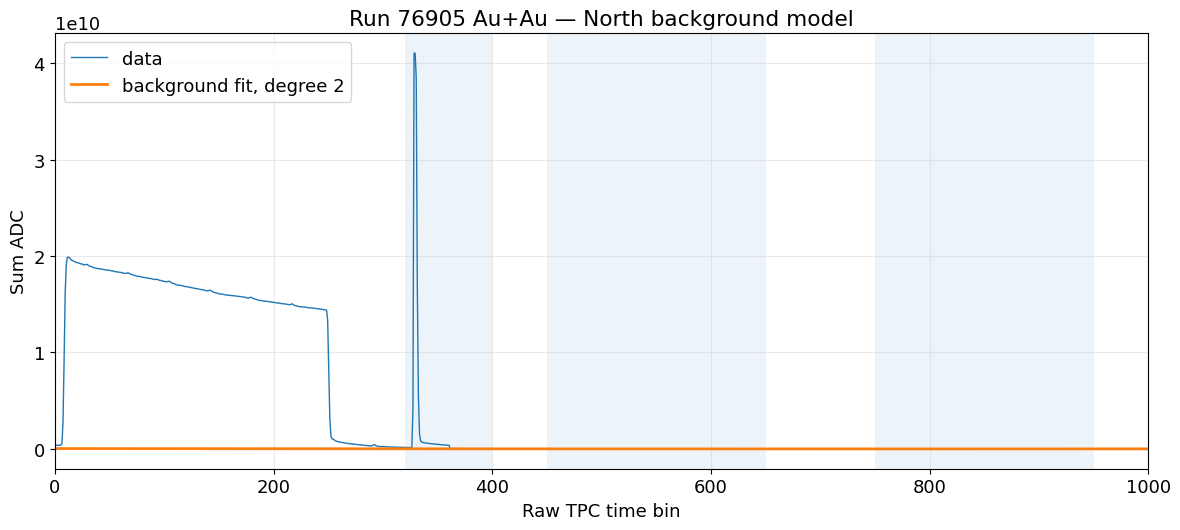

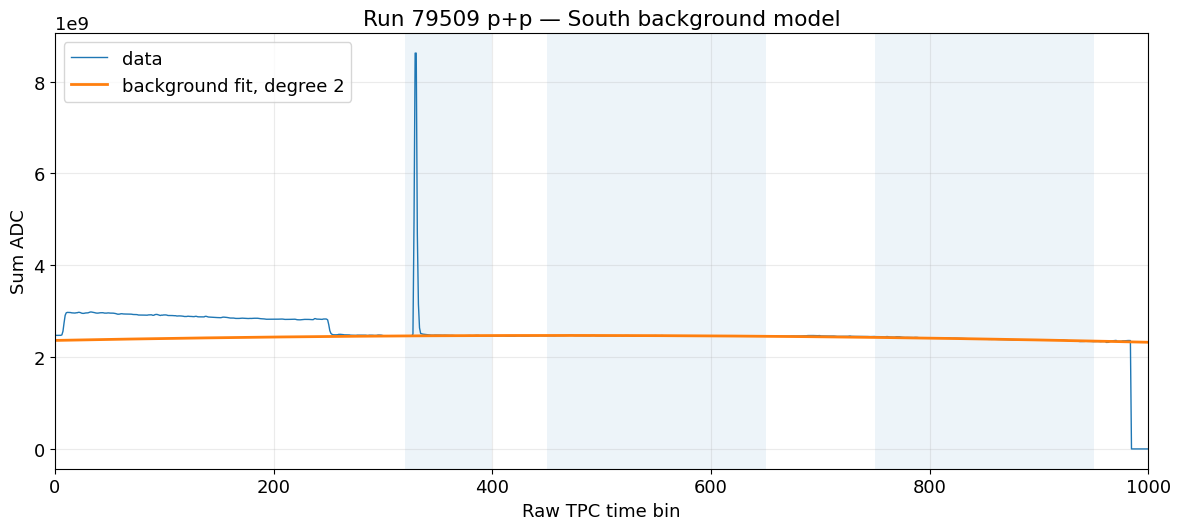

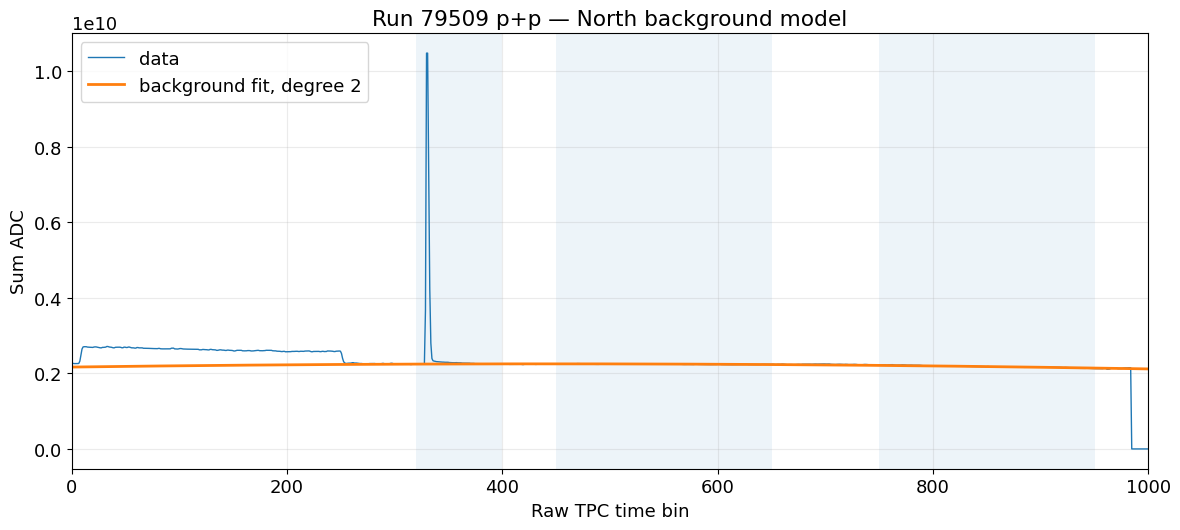

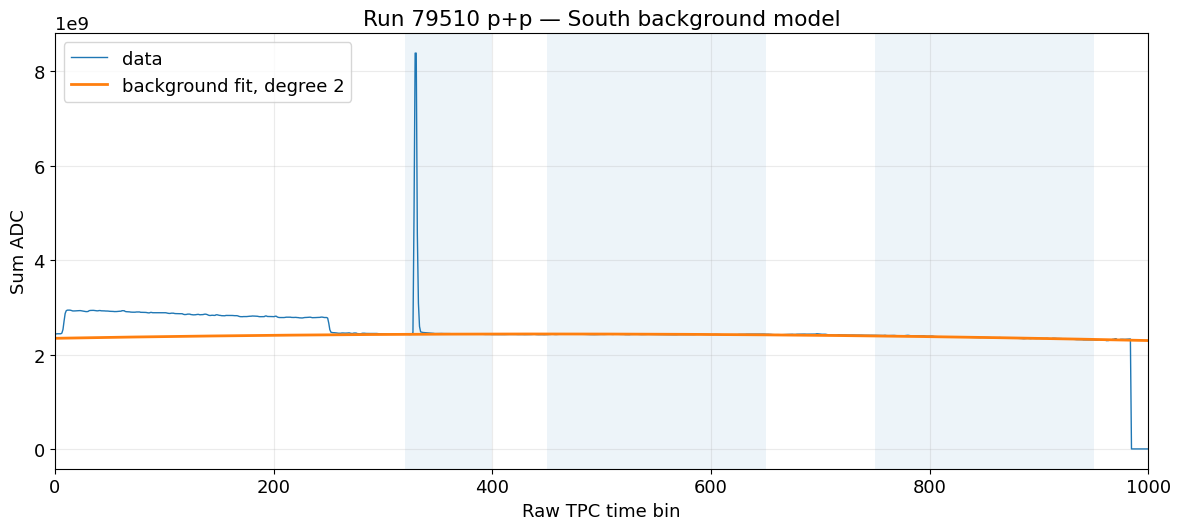

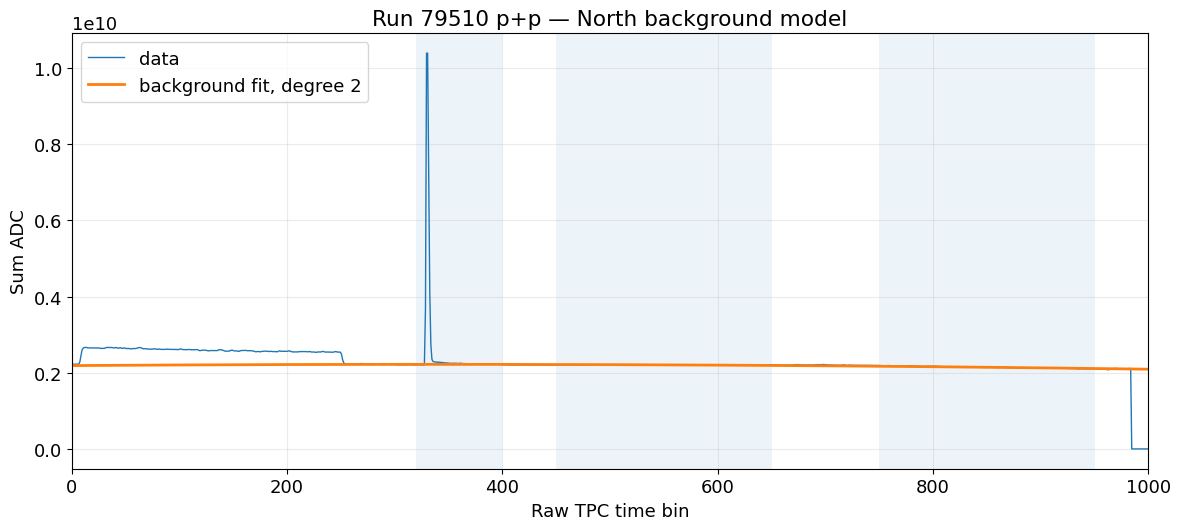

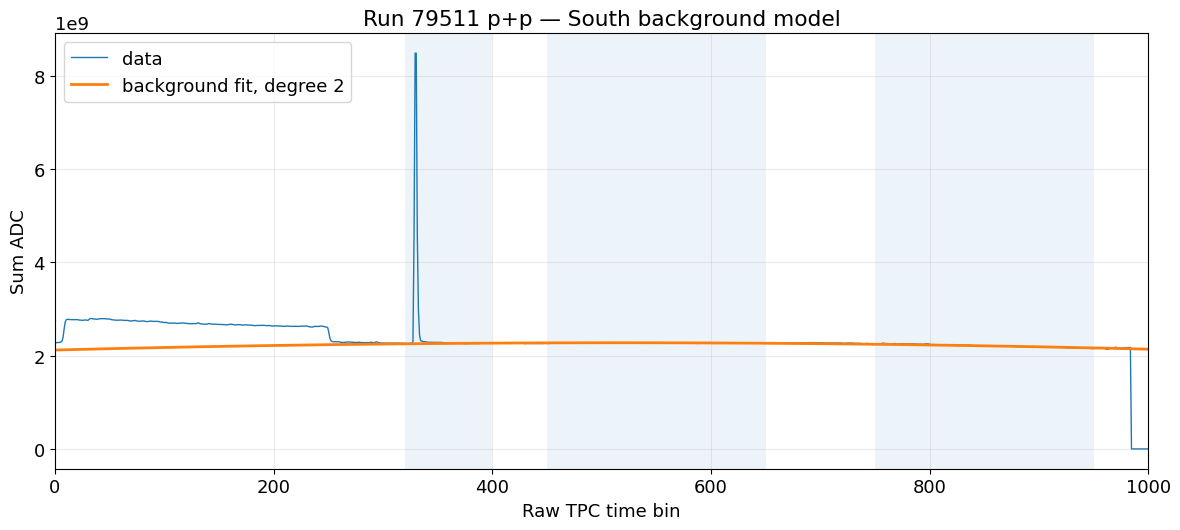

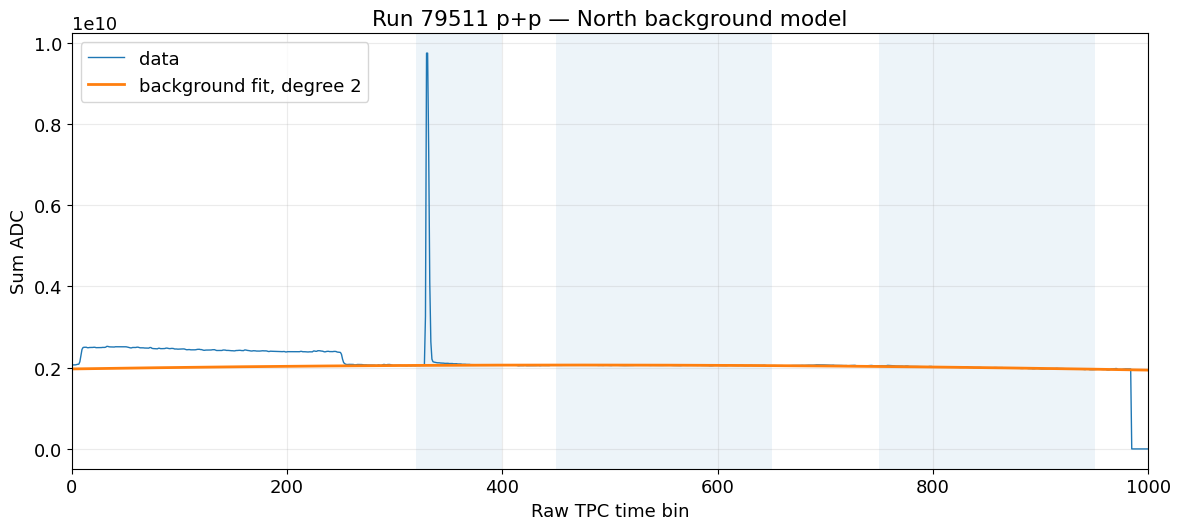

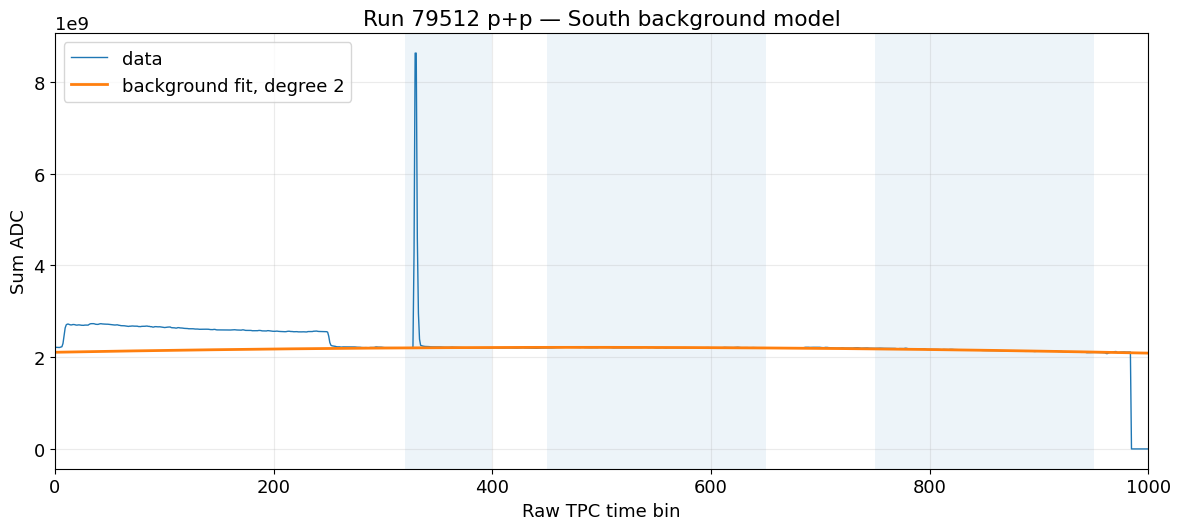

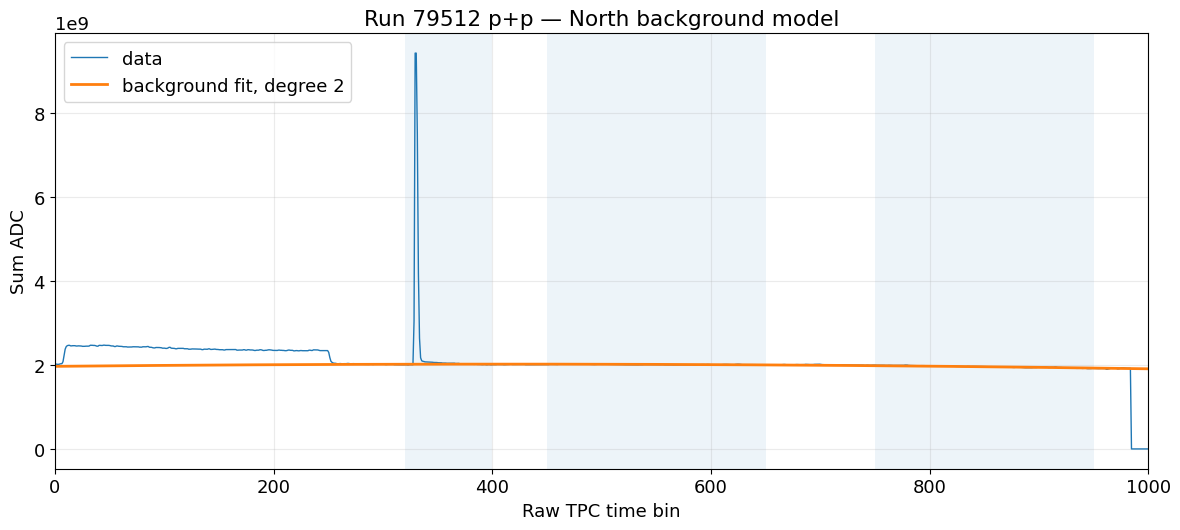

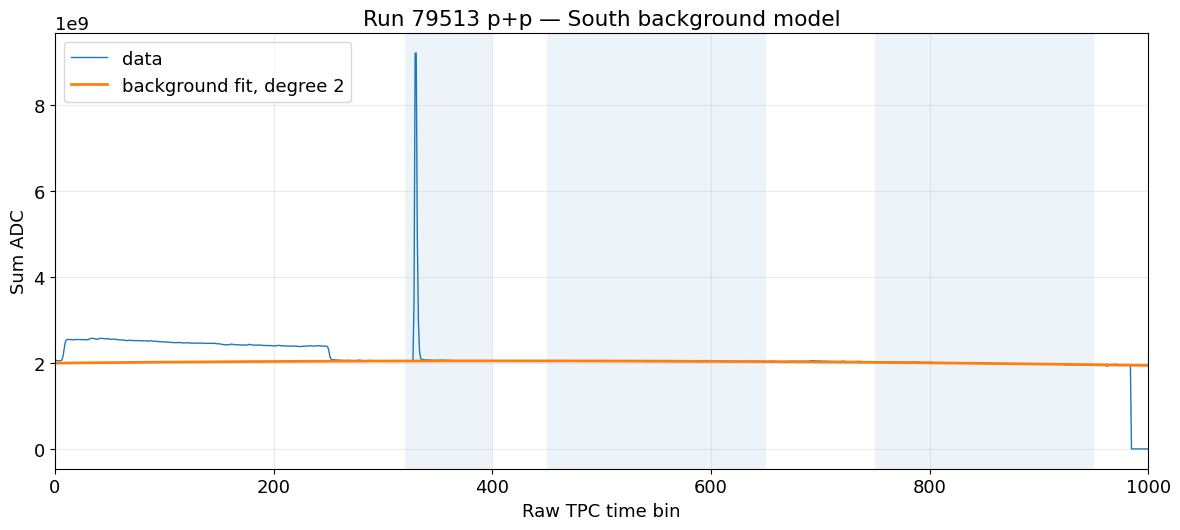

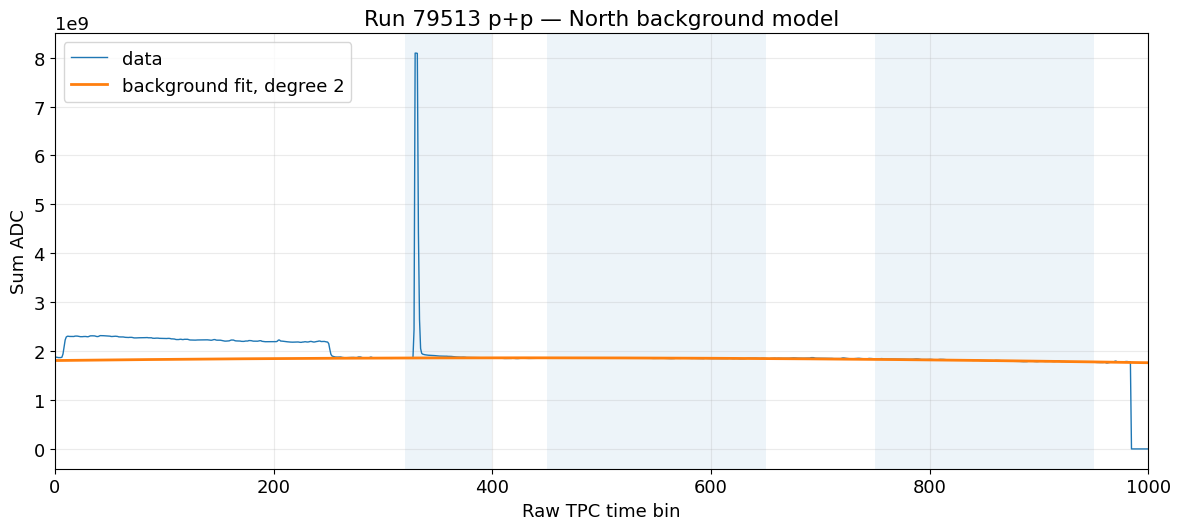

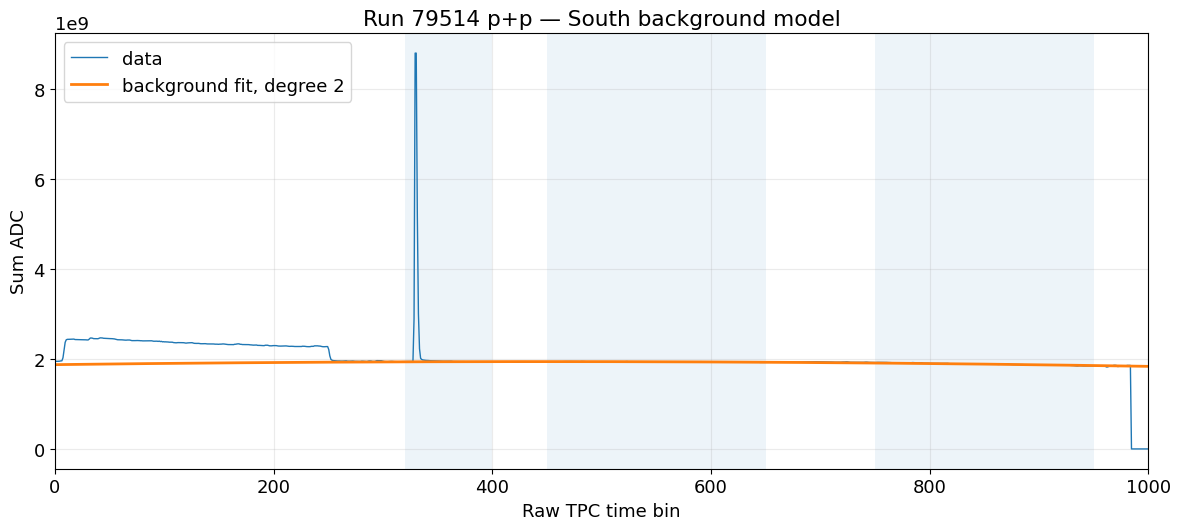

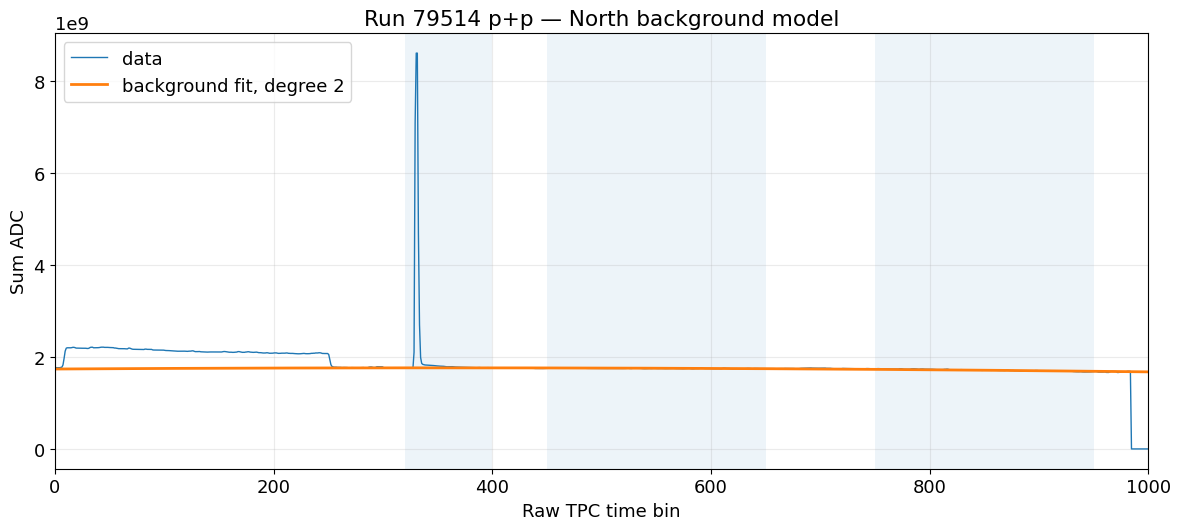

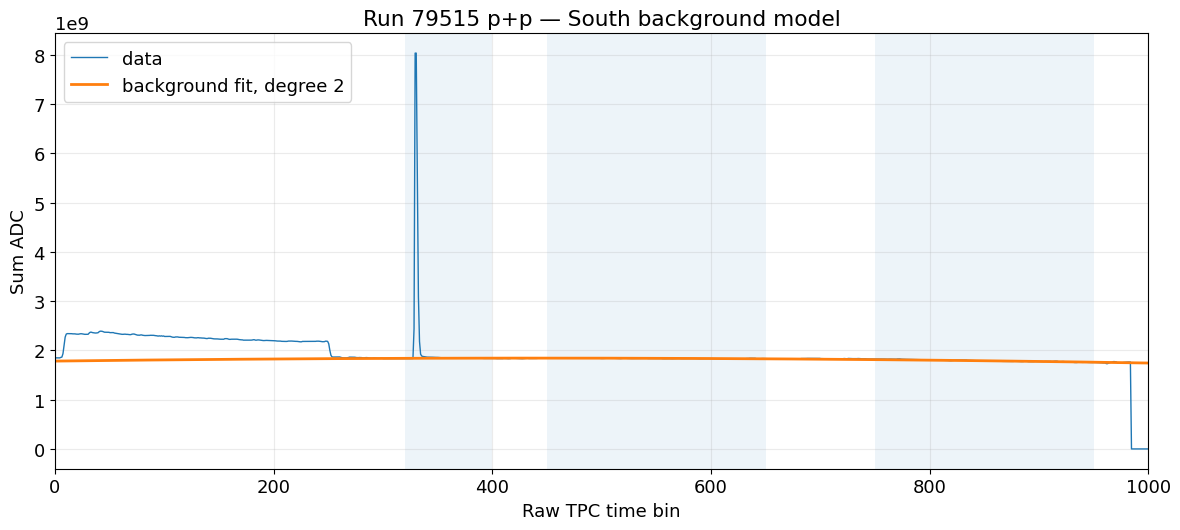

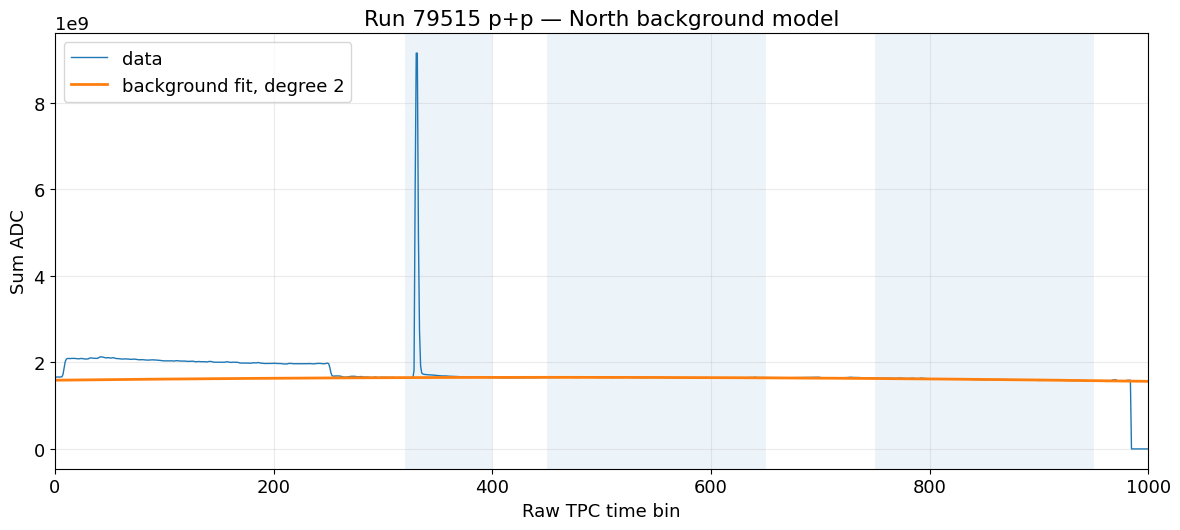

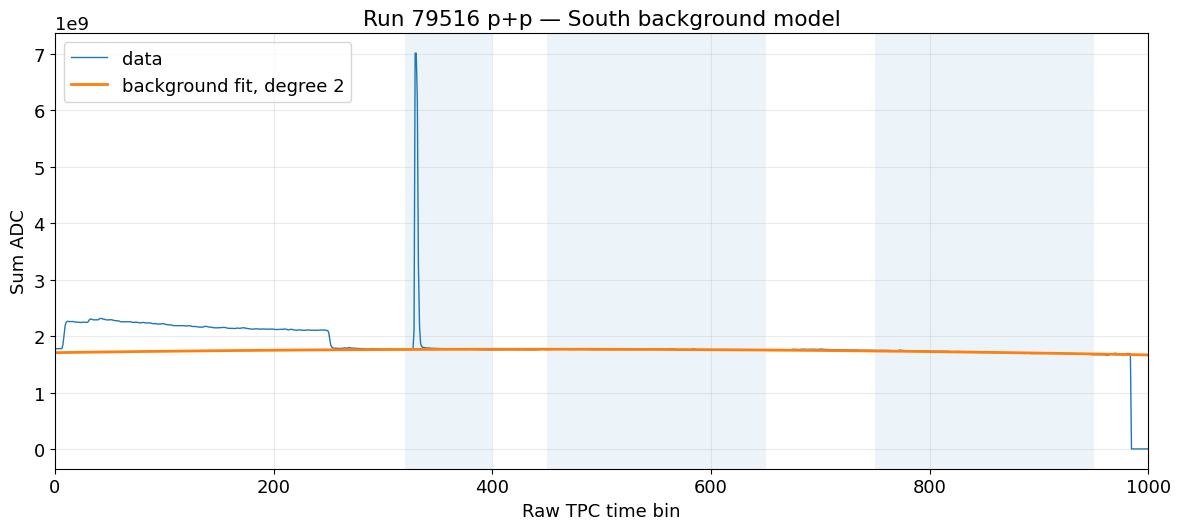

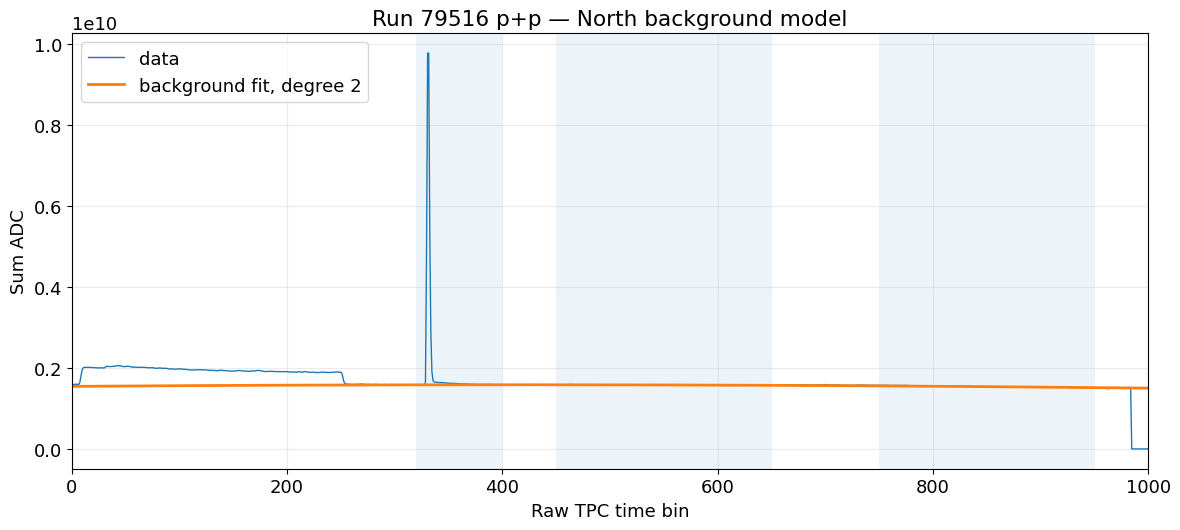

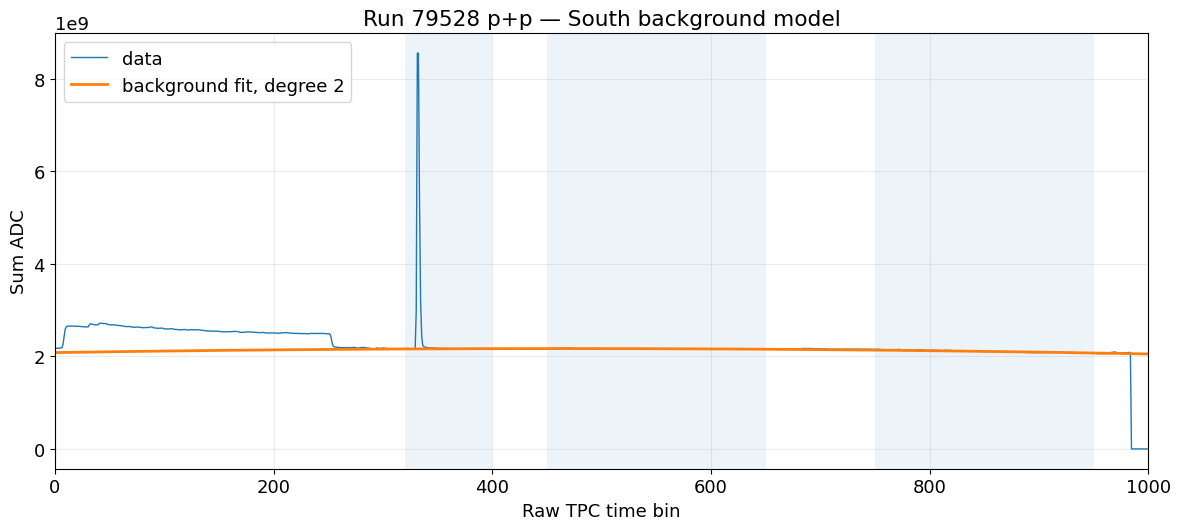

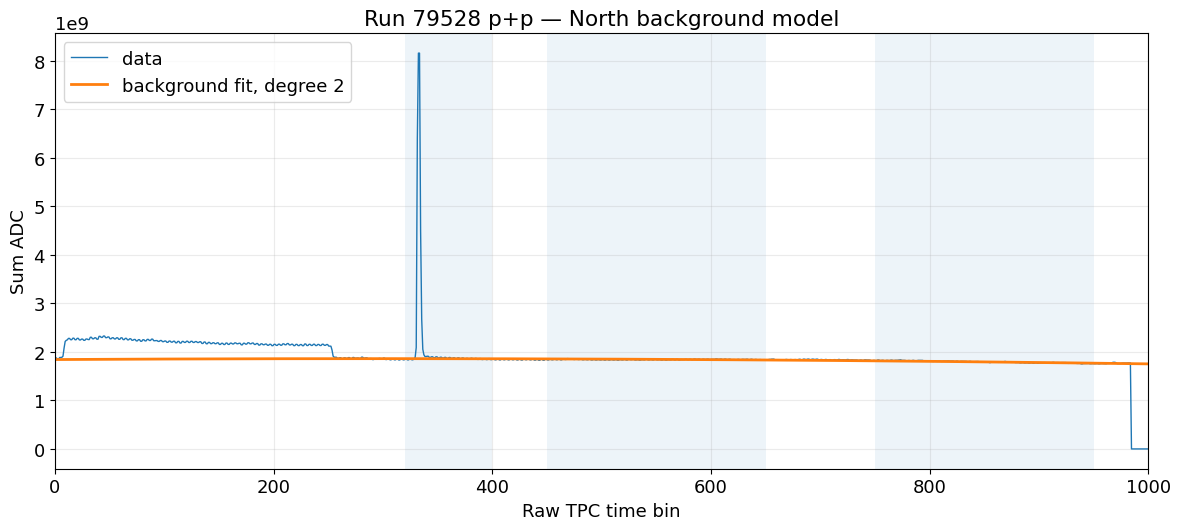

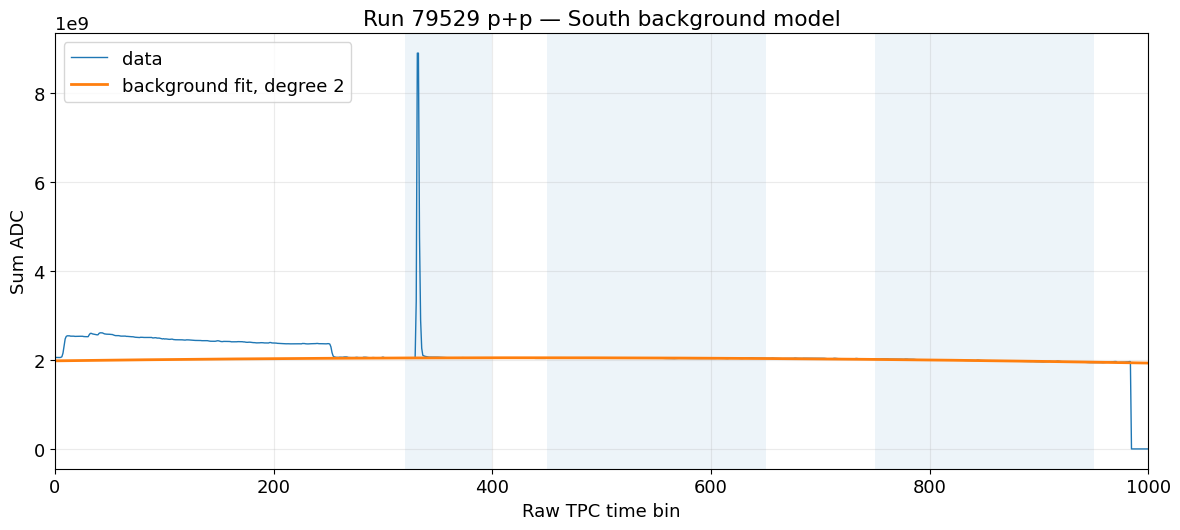

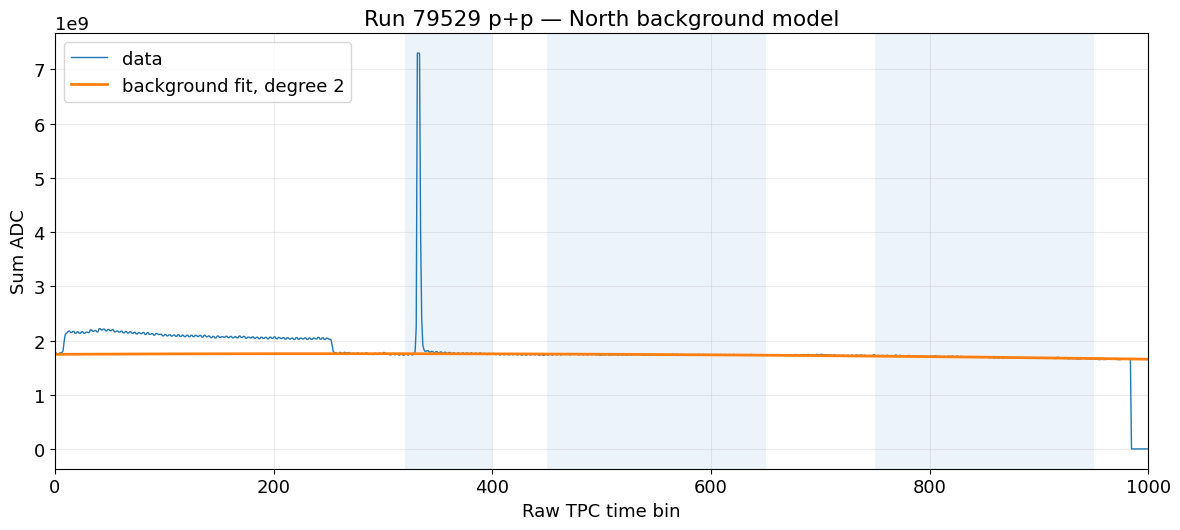

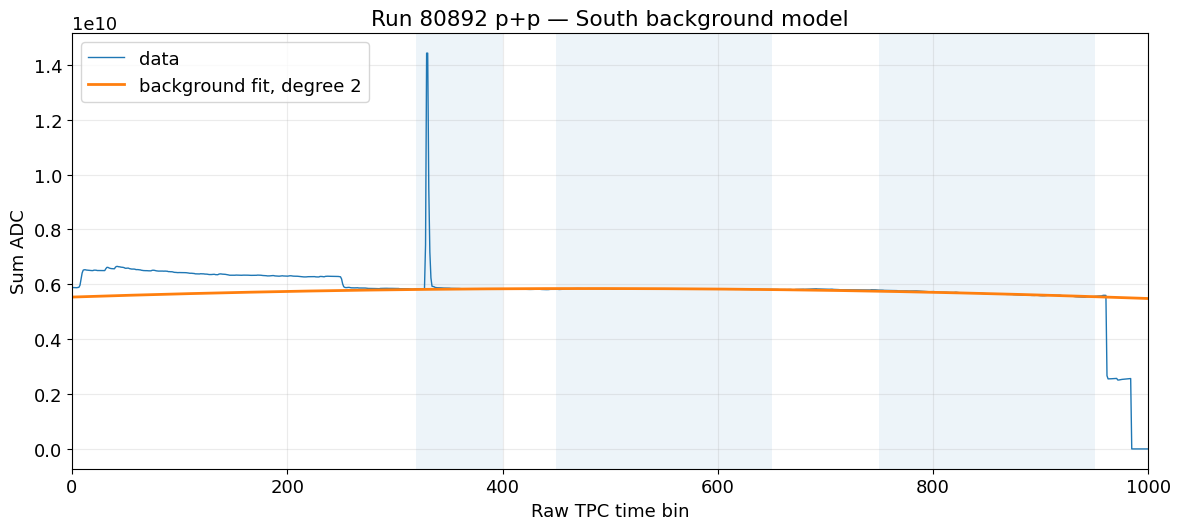

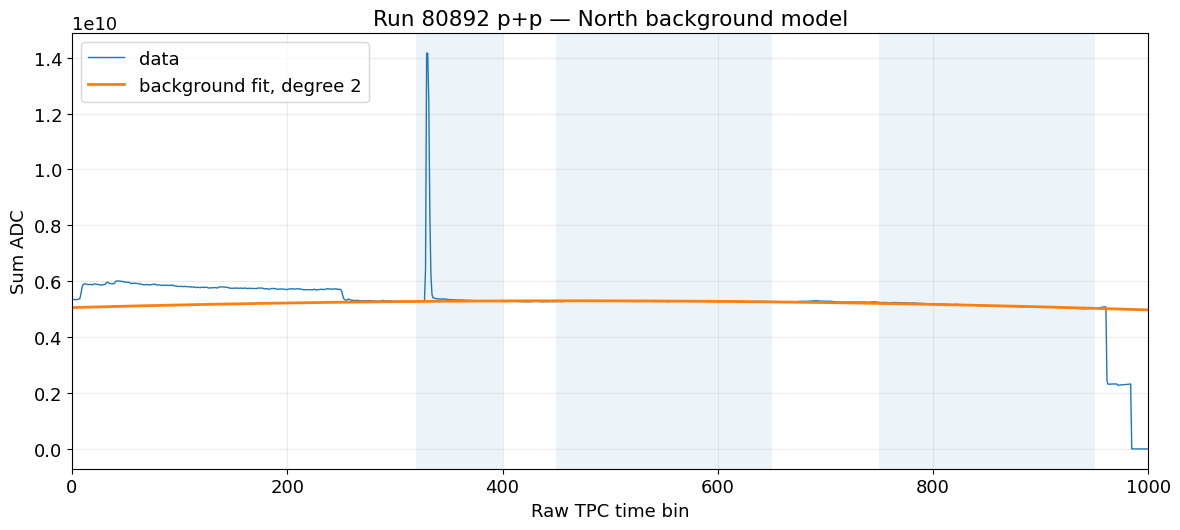

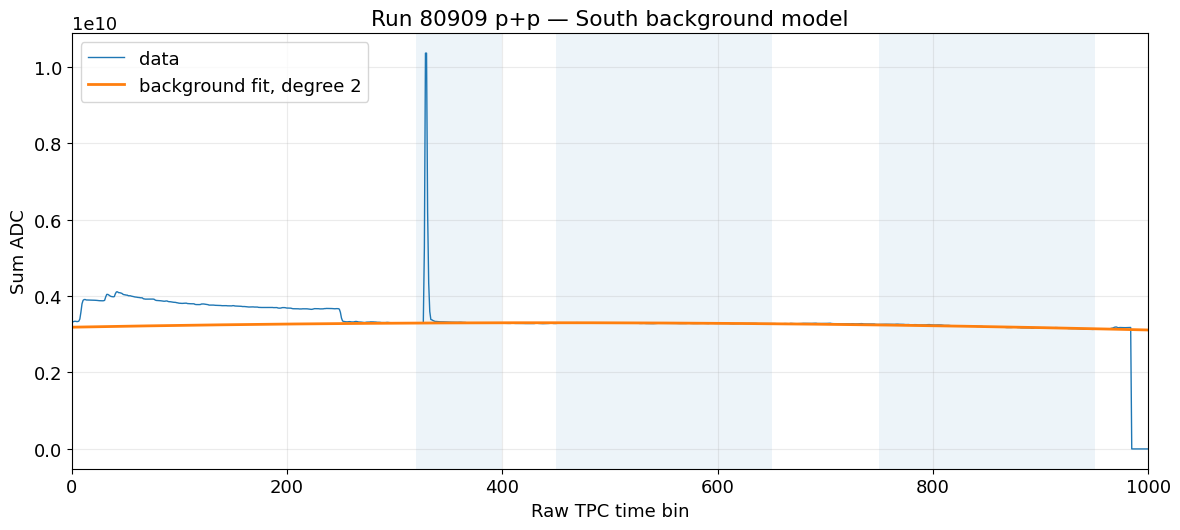

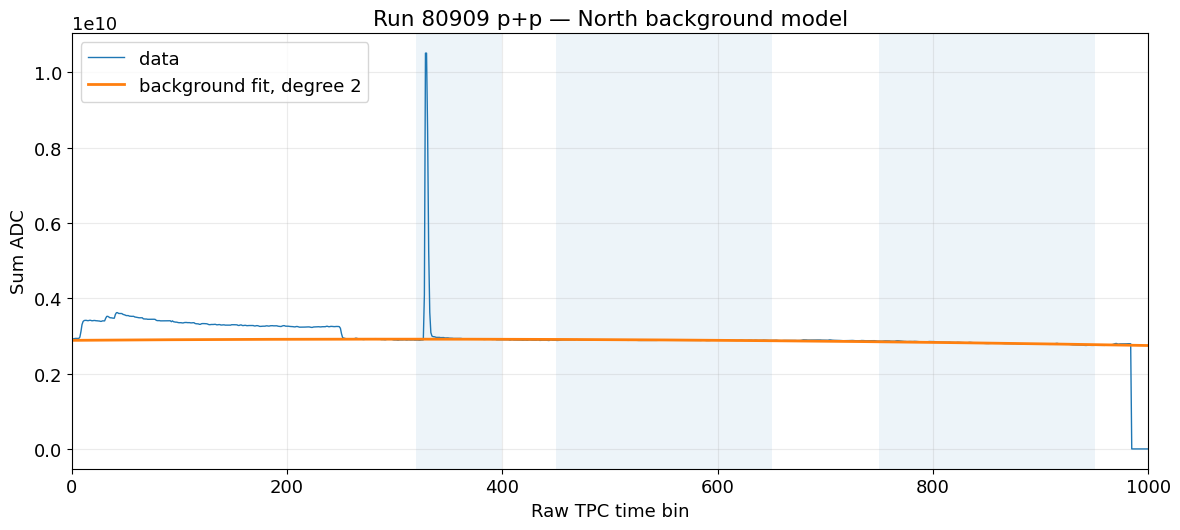

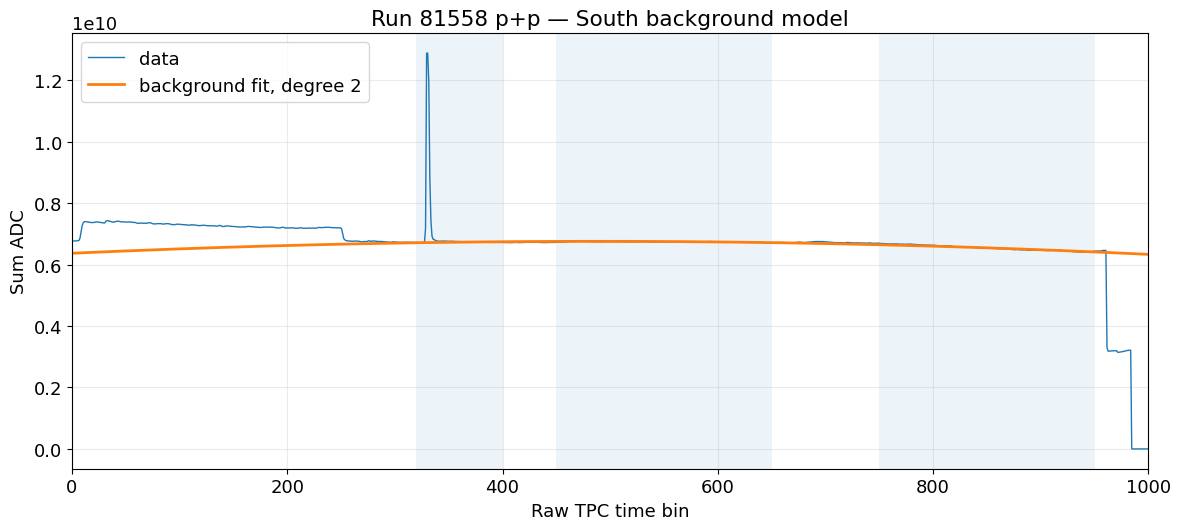

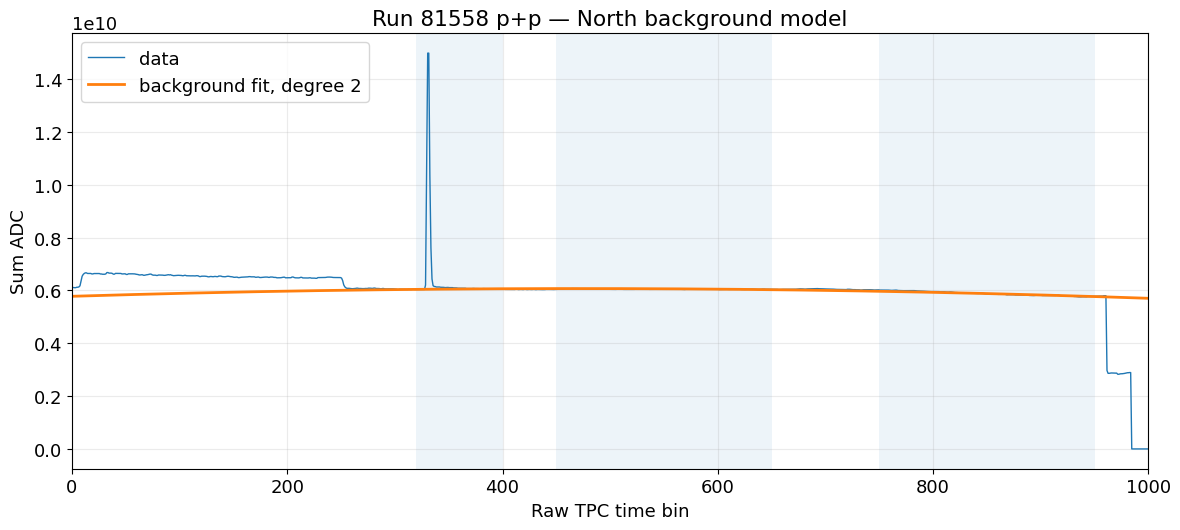

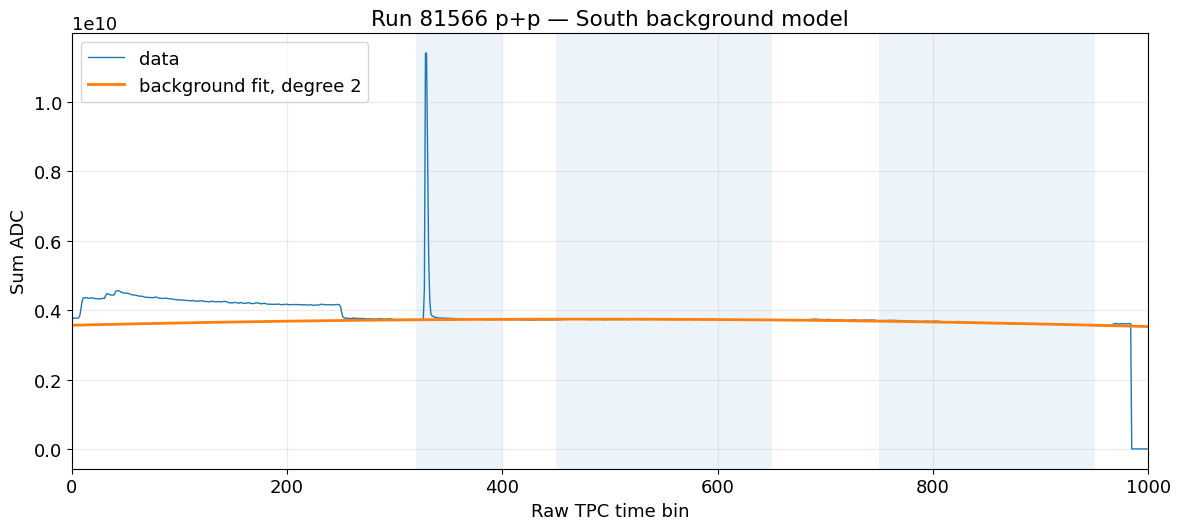

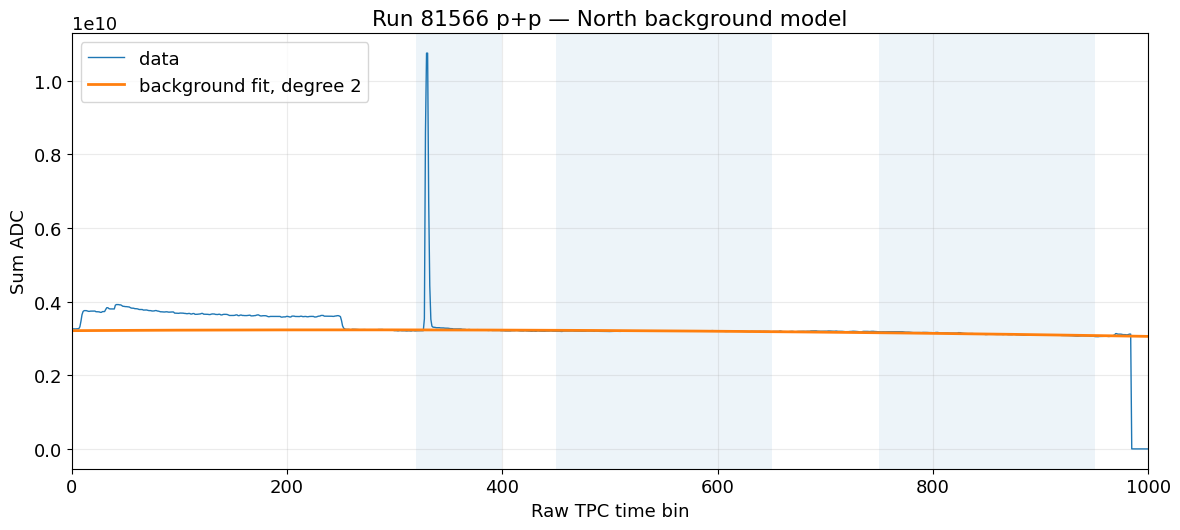

In [8]:

# ============================================================
# 2. Inspect background fit and pedestal subtraction run-by-run
# ============================================================

TIME_CORRECTED = {}

for run in AVAILABLE_RUNS:
    TIME_CORRECTED[run] = {}

    for side in (0, 1):
        if side not in DATA[run]["time"]:
            continue

        x, y, _ = DATA[run]["time"][side]
        y_sub, bg, p, used = subtract_time_background(x, y)
        y_norm = normalize_drift_signal(x, y_sub)

        TIME_CORRECTED[run][side] = {
            "x": x,
            "raw": y,
            "clean": display_clean(y),
            "bg": bg,
            "sub": y_sub,
            "norm": y_norm,
            "poly": p,
        }

        fig, ax = plt.subplots(figsize=(12, 5.5))
        ax.plot(x, display_clean(y), lw=1.0, label="data")
        ax.plot(x, bg, lw=2.0, label=f"background fit, degree {TIME_BG_POLY_DEGREE}")

        for lo, hi in TIME_BG_WINDOWS:
            ax.axvspan(lo, hi, alpha=0.08)

        ax.set_xlim(*TIME_FULL_XLIM)
        ax.set_xlabel("Raw TPC time bin")
        ax.set_ylabel("Sum ADC")
        ax.set_title(f"Run {run} {GROUP_OF_RUN[run]} — {SIDE_LABEL[side]} background model")
        ax.legend()
        fig.tight_layout()

        if SAVE_FIGURES:
            fig.savefig(OUTPUT_DIR / f"time_background_run{run}_side{side}.png", dpi=150)

        plt.show()


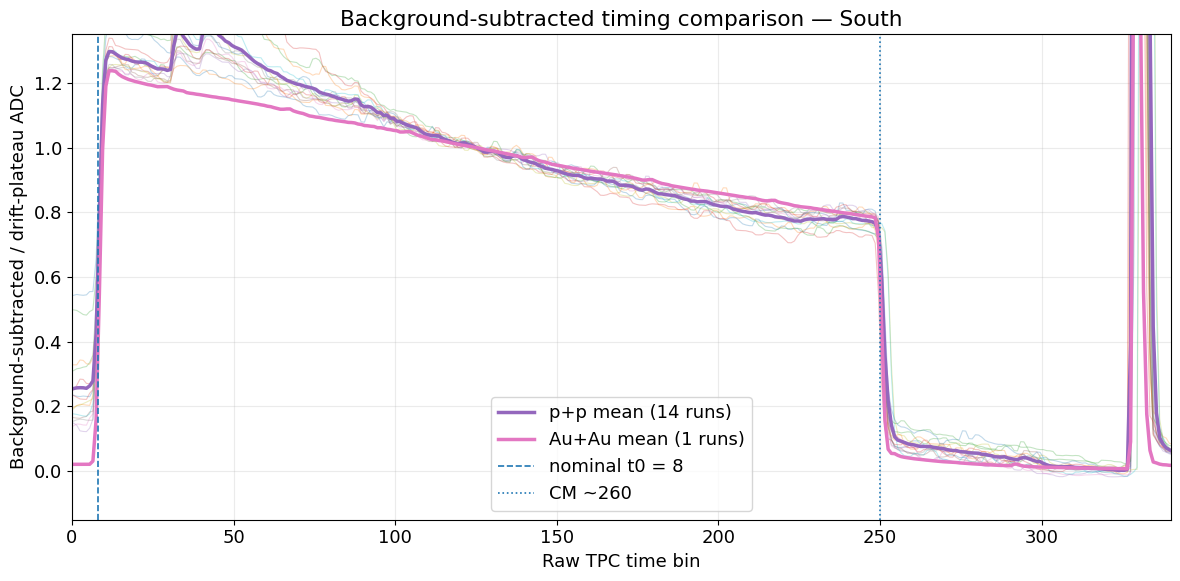

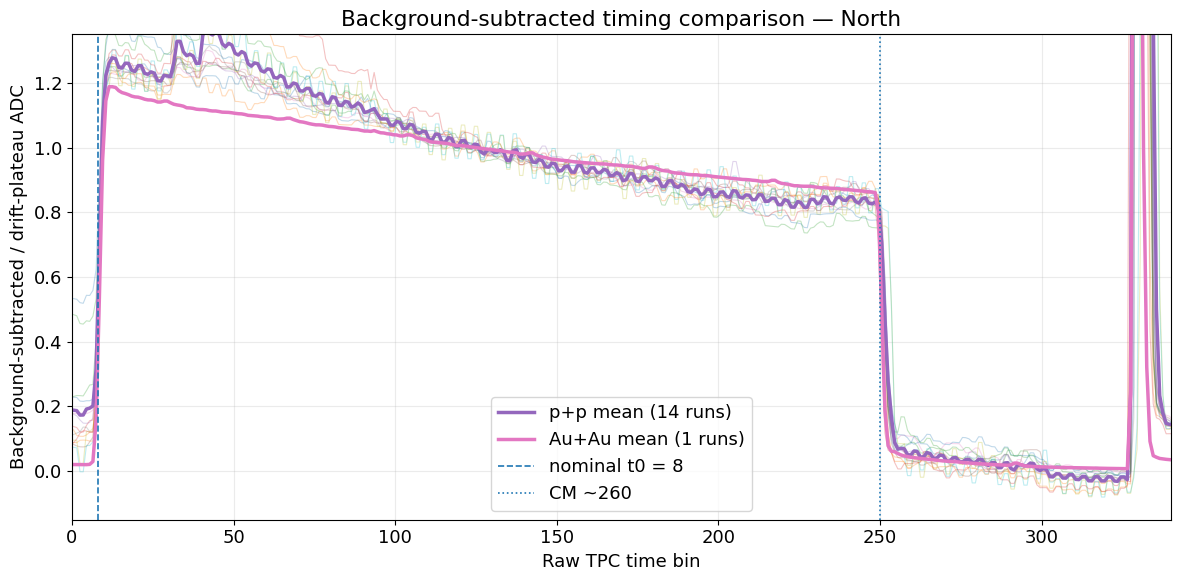

In [9]:

# ============================================================
# 3. p+p vs Au+Au after background subtraction
#    normalized to the active drift plateau
# ============================================================

for side in (0, 1):
    fig, ax = plt.subplots(figsize=(12, 6))

    for group, runs in RUN_GROUPS.items():
        group_curves = []
        x_group = None

        for run in runs:
            if run not in TIME_CORRECTED or side not in TIME_CORRECTED[run]:
                continue

            d = TIME_CORRECTED[run][side]
            x = d["x"]
            y = d["norm"]
            x_group = x
            group_curves.append(y)

            ax.plot(x, y, lw=0.8, alpha=0.28)

        if group_curves:
            mean = np.nanmean(np.vstack(group_curves), axis=0)
            ax.plot(x_group, mean, lw=2.5, label=f"{group} mean ({len(group_curves)} runs)")

    ax.axvline(T0_EXPECTED, ls="--", lw=1.2, label="nominal t0 = 8")
    ax.axvline(CM_EXPECTED, ls=":", lw=1.2, label="CM ~260")
    ax.set_xlim(0, 340)
    ax.set_ylim(-0.15, 1.35)
    ax.set_xlabel("Raw TPC time bin")
    ax.set_ylabel("Background-subtracted / drift-plateau ADC")
    ax.set_title(f"Background-subtracted timing comparison — {SIDE_LABEL[side]}")
    ax.legend()
    fig.tight_layout()

    if SAVE_FIGURES:
        fig.savefig(OUTPUT_DIR / f"time_subtracted_compare_side{side}.png", dpi=160)
        fig.savefig(OUTPUT_DIR / f"time_subtracted_compare_side{side}.pdf")

    plt.show()



## \(t_0\) edge near the pad plane

For this plot the normalization is **local**:

- level before the edge: `T0_LEFT_LEVEL`;
- plateau after the edge: `T0_RIGHT_LEVEL`.

The 50% crossing is used as the run-by-run \(t_0\) estimator.  
The 10–90% width is retained as a QA quantity for edge broadening/noise.


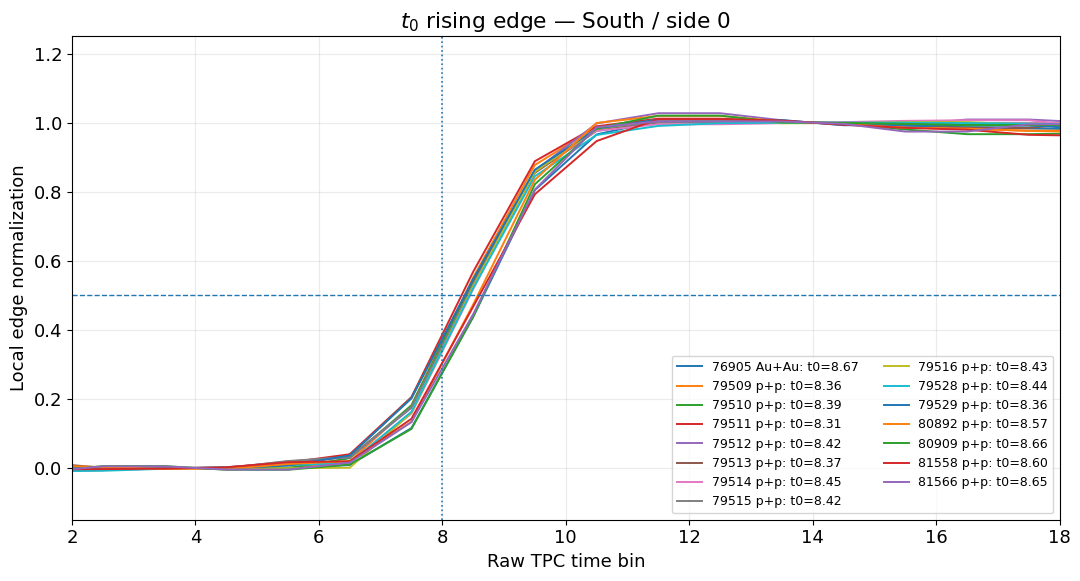

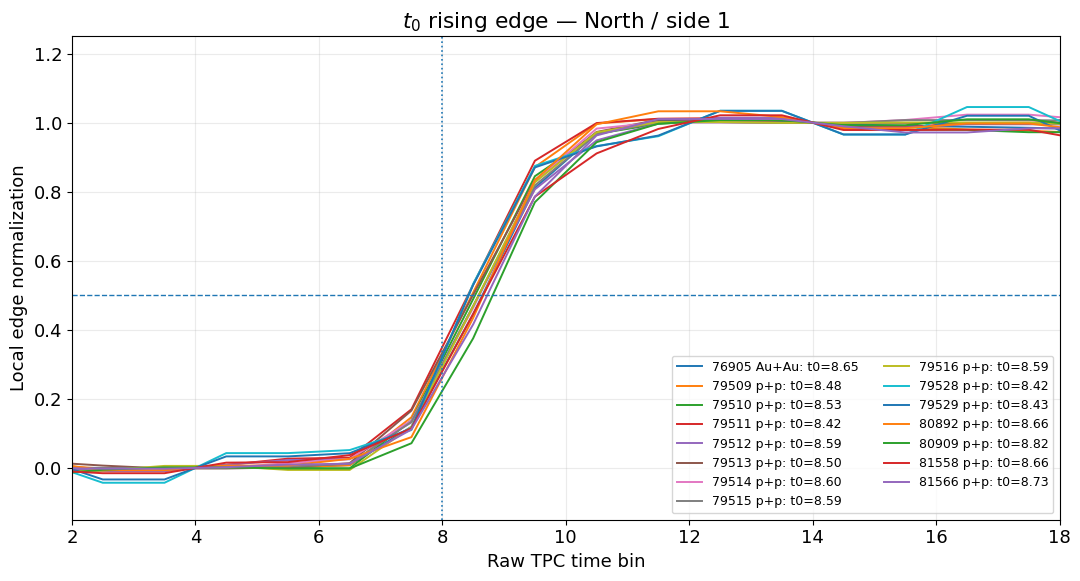

In [10]:

# ============================================================
# 4. t0 edge: local normalized comparison
# ============================================================

T0_RESULTS = {}

for side in (0, 1):
    fig, ax = plt.subplots(figsize=(11, 6))

    for run in AVAILABLE_RUNS:
        if side not in DATA[run]["time"]:
            continue

        x, y, _ = DATA[run]["time"][side]
        m = edge_metrics(
            x, y,
            T0_LEFT_LEVEL,
            T0_RIGHT_LEVEL,
            T0_SEARCH,
            expected=T0_EXPECTED,
        )

        T0_RESULTS[(run, side)] = m
        yn = normalize_between_levels(display_clean(y), m["left_level"], m["right_level"])

        ax.plot(x, yn, lw=1.4, label=f"{run} {GROUP_OF_RUN[run]}: t0={m['x50']:.2f}")

    ax.axhline(0.5, ls="--", lw=1)
    ax.axvline(T0_EXPECTED, ls=":", lw=1.2)
    ax.set_xlim(*T0_ZOOM)
    ax.set_ylim(-0.15, 1.25)
    ax.set_xlabel("Raw TPC time bin")
    ax.set_ylabel("Local edge normalization")
    ax.set_title(f"$t_0$ rising edge — {SIDE_LABEL[side]} / side {side}")
    ax.legend(fontsize=9, ncol=2)
    fig.tight_layout()

    if SAVE_FIGURES:
        fig.savefig(OUTPUT_DIR / f"t0_zoom_side{side}.png", dpi=170)
        fig.savefig(OUTPUT_DIR / f"t0_zoom_side{side}.pdf")

    plt.show()



## Central-membrane edge and data drift velocity

The central-membrane falling edge is extracted independently of the \(t_0\) edge.

\[
\Delta t_{\rm drift}
=
(t_{\rm CM}-t_0)\times 56.8~{\rm ns},
\]

\[
v_{\rm drift}^{\rm data}
=
\frac{102.605~{\rm cm}}{\Delta t_{\rm drift}}.
\]

The summary table reports the velocity in cm/\(\mu\)s.


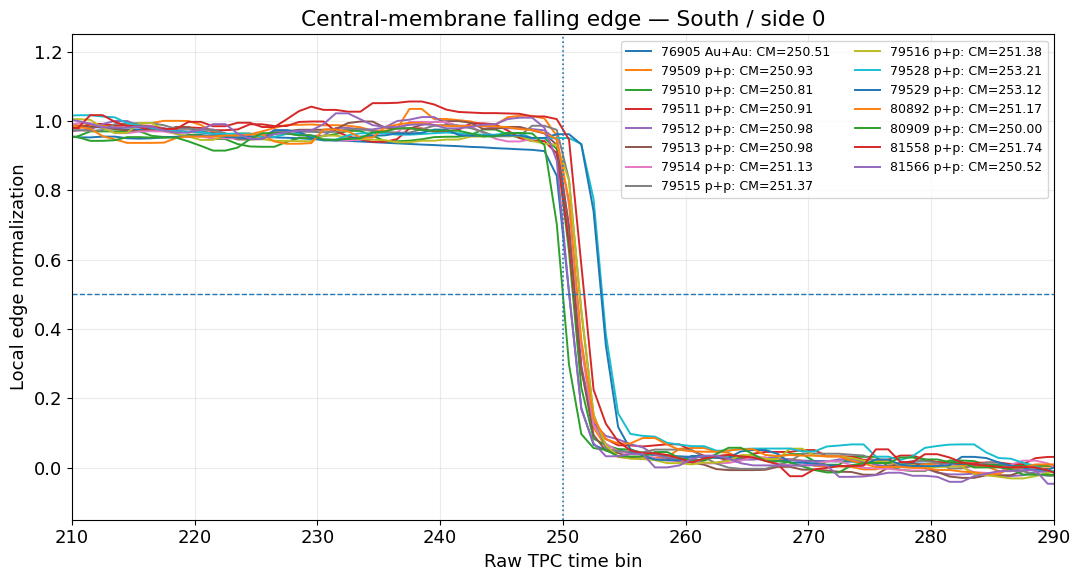

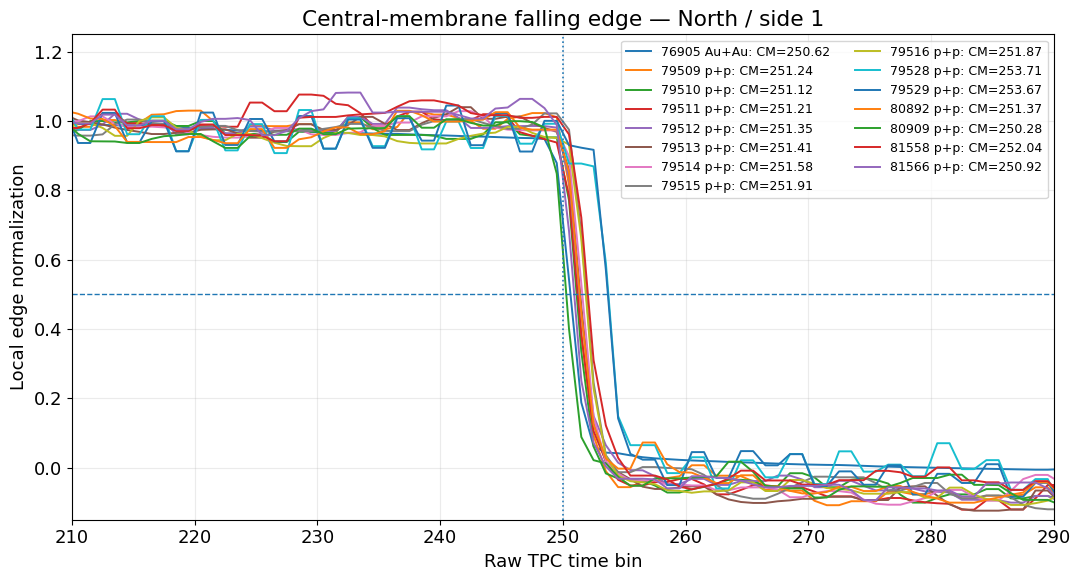

In [11]:
CM_RESULTS = {}

for side in (0, 1):
    fig, ax = plt.subplots(figsize=(11, 6))

    for run in AVAILABLE_RUNS:
        if side not in DATA[run]["time"]:
            continue

        x, y, _ = DATA[run]["time"][side]

        m = edge_metrics(
            x, y,
            CM_LEFT_LEVEL,
            CM_RIGHT_LEVEL,
            CM_SEARCH,
            expected=CM_EXPECTED,
        )

        CM_RESULTS[(run, side)] = m

        # Falling edge: high before CM -> low after CM
        yy = display_clean(y)
        yn = (
            (yy - m["right_level"])
            / (m["left_level"] - m["right_level"])
        )

        ax.plot(
            x,
            yn,
            lw=1.4,
            label=f"{run} {GROUP_OF_RUN[run]}: CM={m['x50']:.2f}",
        )

    ax.axhline(0.5, ls="--", lw=1)
    ax.axvline(CM_EXPECTED, ls=":", lw=1.2)

    ax.set_xlim(*CM_ZOOM)
    ax.set_ylim(-0.15, 1.25)

    ax.set_xlabel("Raw TPC time bin")
    ax.set_ylabel("Local edge normalization")
    ax.set_title(
        f"Central-membrane falling edge — {SIDE_LABEL[side]} / side {side}"
    )

    ax.legend(fontsize=9, ncol=2)
    fig.tight_layout()

    if SAVE_FIGURES:
        fig.savefig(
            OUTPUT_DIR / f"cm_time_zoom_side{side}.png",
            dpi=170,
        )
        fig.savefig(
            OUTPUT_DIR / f"cm_time_zoom_side{side}.pdf"
        )

    plt.show()

In [12]:

# ============================================================
# 6. Run-by-run t0 / CM / drift-velocity summary
# ============================================================

rows = []

for run in AVAILABLE_RUNS:
    for side in (0, 1):
        t0 = T0_RESULTS.get((run, side))
        cm = CM_RESULTS.get((run, side))
        if t0 is None or cm is None:
            continue

        t0_bin = t0["x50"]
        cm_bin = cm["x50"]
        dt_bins = cm_bin - t0_bin
        dt_ns = dt_bins * TPC_TIME_BIN_NS

        v_cm_us = np.nan
        if np.isfinite(dt_ns) and dt_ns > 0:
            v_cm_us = DRIFT_LENGTH_CM / dt_ns * 1000.0

        rows.append({
            "run": run,
            "system": GROUP_OF_RUN[run],
            "side": side,
            "side_name": SIDE_LABEL[side],
            "t0_bin_50": t0_bin,
            "t0_width_10_90_bins": t0["width_10_90"],
            "cm_bin_50": cm_bin,
            "cm_width_10_90_bins": cm["width_10_90"],
            "drift_bins": dt_bins,
            "drift_time_ns": dt_ns,
            "vdrift_data_cm_us": v_cm_us,
        })

SUMMARY = pd.DataFrame(rows).sort_values(["run", "side"]).reset_index(drop=True)
display(SUMMARY)

SUMMARY.to_csv(OUTPUT_DIR / "drift_t0_summary.csv", index=False)
print("saved:", OUTPUT_DIR / "drift_t0_summary.csv")


,run,system,side,side_name,t0_bin_50,t0_width_10_90_bins,cm_bin_50,cm_width_10_90_bins,drift_bins,drift_time_ns,vdrift_data_cm_us
0,76905,Au+Au,0,South,8.670114,2.734440,250.513850,3.496975,241.843737,13736.724244,7.449010
1,76905,Au+Au,1,North,8.648856,2.737936,250.619800,3.006078,241.970944,13743.949592,7.445094
2,79509,p+p,0,South,8.361653,2.702684,250.928387,3.089989,242.566735,13777.790525,7.426808
3,79509,p+p,1,North,8.477679,2.563061,251.240506,2.411635,242.762827,13788.928589,7.420809
4,79510,p+p,0,South,8.387933,2.857959,250.813867,2.824831,242.425934,13769.793052,7.431121
5,79510,p+p,1,North,8.530721,2.721747,251.121656,2.567207,242.590935,13779.165102,7.426067
6,79511,p+p,0,South,8.312508,2.749709,250.909591,3.614489,242.597082,13779.514283,7.425879
7,79511,p+p,1,North,8.415170,2.591603,251.205649,2.820181,242.790479,13790.499190,7.419963
8,79512,p+p,0,South,8.416030,2.799797,250.977769,3.588142,242.561739,13777.506758,7.426961
9,79512,p+p,1,North,8.592599,2.954837,251.348196,3.021433,242.755597,13788.517908,7.421030


saved: plots_drift_t0/drift_t0_summary.csv


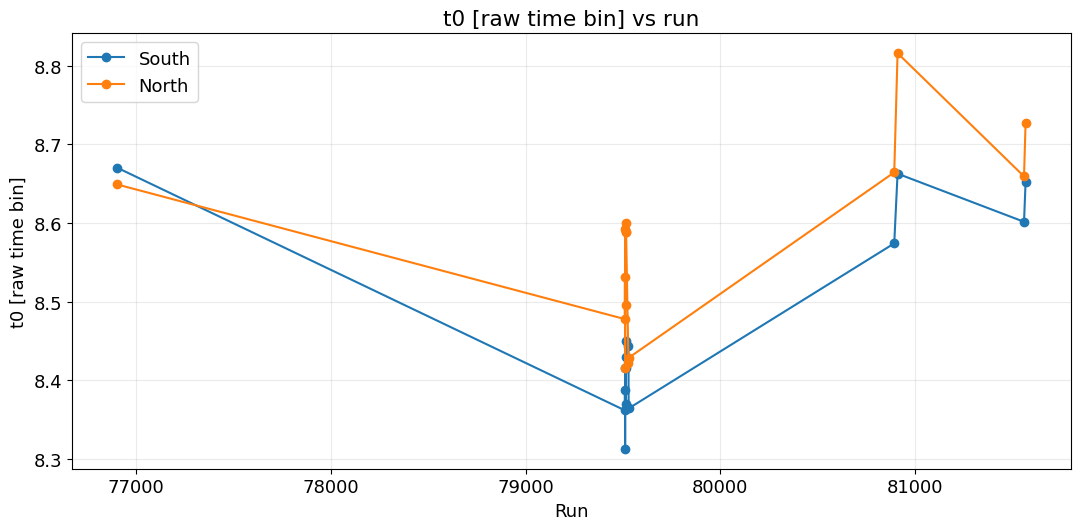

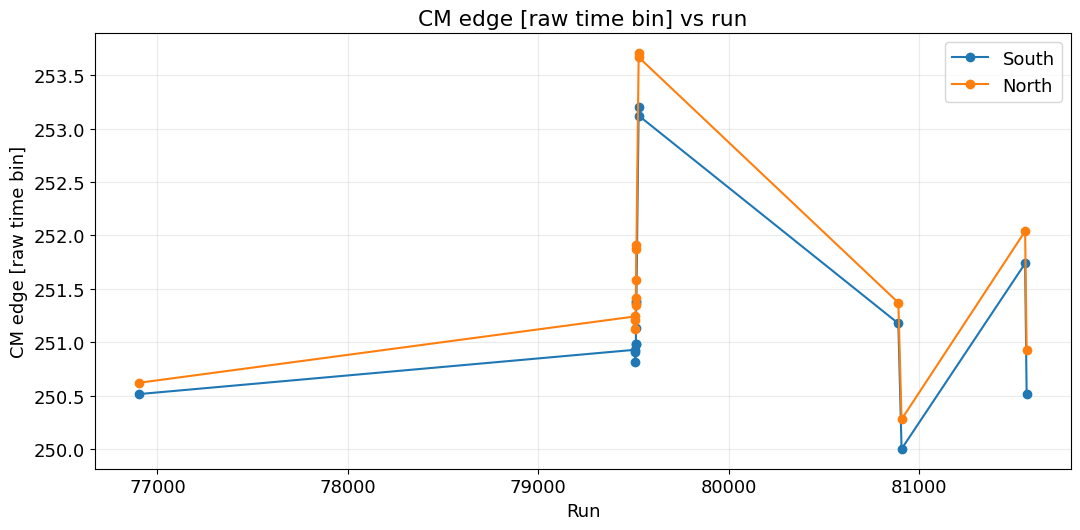

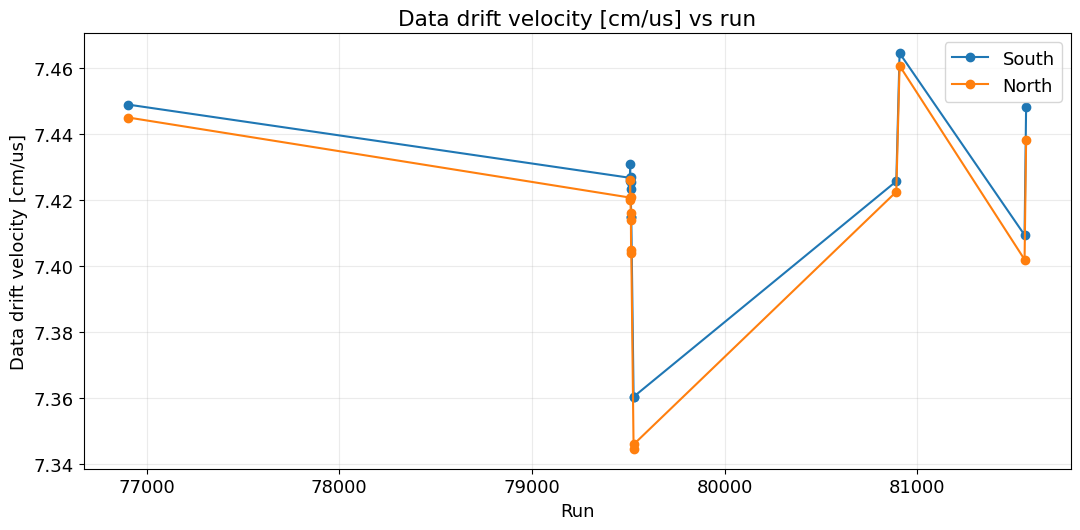

In [13]:

# ============================================================
# 7. Run-by-run extracted t0, CM time, and drift velocity
# ============================================================

if len(SUMMARY):
    for quantity, ylabel, fname in [
        ("t0_bin_50", "t0 [raw time bin]", "summary_t0"),
        ("cm_bin_50", "CM edge [raw time bin]", "summary_cm"),
        ("vdrift_data_cm_us", "Data drift velocity [cm/us]", "summary_vdrift"),
    ]:
        fig, ax = plt.subplots(figsize=(11, 5.5))

        for side in (0, 1):
            ss = SUMMARY[SUMMARY["side"] == side]
            ax.plot(ss["run"], ss[quantity], "o-", label=SIDE_LABEL[side])

        ax.set_xlabel("Run")
        ax.set_ylabel(ylabel)
        ax.set_title(ylabel + " vs run")
        ax.legend()
        fig.tight_layout()
        #ax.set_xlim(79500, 79535)

        if SAVE_FIGURES:
            fig.savefig(OUTPUT_DIR / f"{fname}.png", dpi=170)
            fig.savefig(OUTPUT_DIR / f"{fname}.pdf")

        plt.show()



## Run-index comparison with CDB drift velocity and \(t_0\)

The original run-number plots above are left unchanged.

The comparison below reads:

- `g_cdb` — CDB drift velocity;
- `g_cdb_t0_ns` — CDB \(t_0\) in the signed ns convention;

from `tpc_dv_postprocess_Long_Tony1.root`.

Only runs that exist **both** in the current timing analysis and in the reference
ROOT file are retained. They are then assigned a new consecutive `run_index =
0,1,2,...`.  The mapping `run_index -> actual run number` is printed explicitly
and also shown on a secondary top x-axis.

For the \(t_0\) comparison the CDB value is converted to the raw-bin convention as

\[
t_{0,\mathrm{CDB}}^{\rm raw\ bin}
=
-\frac{t_{0,\mathrm{CDB}}^{\rm ns}}{56.8~\mathrm{ns}}.
\]


In [14]:
# ============================================================
# 7b. Load CDB DV and t0 graphs from Long_Tony1 ROOT file
# ============================================================

def resolve_cdb_reference_file():
    for path in CDB_REFERENCE_FILE_CANDIDATES:
        if path.exists():
            return path
    return None


def tgraph_to_run_dict(graph):
    out = {}
    if not graph:
        return out

    for i in range(graph.GetN()):
        # ROOT 6.32 TGraph helpers
        x = float(graph.GetPointX(i))
        y = float(graph.GetPointY(i))

        if not np.isfinite(x) or not np.isfinite(y):
            continue

        run = int(round(x))
        out[run] = y

    return out


CDB_REFERENCE_FILE = resolve_cdb_reference_file()

CDB_DV_BY_RUN = {}
CDB_T0_NS_BY_RUN = {}

if CDB_REFERENCE_FILE is None:
    print("CDB reference ROOT file not found.")
    print("Edit CDB_REFERENCE_FILE_CANDIDATES in the configuration cell.")
else:
    print("CDB reference file:", CDB_REFERENCE_FILE)

    fref = root.TFile.Open(str(CDB_REFERENCE_FILE), "READ")

    if not fref or fref.IsZombie():
        print("ERROR: could not open", CDB_REFERENCE_FILE)
    else:
        g_dv = find_root_object(fref, CDB_DV_GRAPH_NAME)
        g_t0 = find_root_object(fref, CDB_T0_GRAPH_NAME)

        if not g_dv:
            print("ERROR: missing graph", CDB_DV_GRAPH_NAME)
        else:
            CDB_DV_BY_RUN = tgraph_to_run_dict(g_dv)

        if not g_t0:
            print("ERROR: missing graph", CDB_T0_GRAPH_NAME)
        else:
            CDB_T0_NS_BY_RUN = tgraph_to_run_dict(g_t0)

        fref.Close()

    print("CDB DV runs:", len(CDB_DV_BY_RUN))
    print("CDB t0 runs:", len(CDB_T0_NS_BY_RUN))


CDB reference file: ../distort/code/dv/input/tpc_dv_postprocess_whole.root
CDB DV runs: 152
CDB t0 runs: 152


In [15]:
# ============================================================
# 7c. Match by ACTUAL run number, then assign consecutive run index
# ============================================================

summary_runs = set(int(r) for r in SUMMARY["run"].unique())

# Require the run to exist in both CDB graphs so DV and t0 use exactly
# the same run-index mapping.
COMMON_CDB_RUNS = sorted(
    summary_runs
    & set(CDB_DV_BY_RUN)
    & set(CDB_T0_NS_BY_RUN)
)

comparison_rows = []

for run_index, run in enumerate(COMMON_CDB_RUNS):
    row = {
        "run_index": run_index,
        "run": run,
        "cdb_vdrift_cm_us": CDB_DV_BY_RUN[run],
        "cdb_t0_ns": CDB_T0_NS_BY_RUN[run],
        "cdb_t0_raw_bin": (
            CDB_T0_NS_TO_RAW_BIN_SIGN
            * CDB_T0_NS_BY_RUN[run]
            / TPC_TIME_BIN_NS
        ),
    }

    for side in (0, 1):
        ss = SUMMARY[
            (SUMMARY["run"] == run)
            & (SUMMARY["side"] == side)
        ]

        if len(ss):
            row[f"data_t0_side{side}"] = float(ss.iloc[0]["t0_bin_50"])
            row[f"data_cm_side{side}"] = float(ss.iloc[0]["cm_bin_50"])
            row[f"data_vdrift_side{side}"] = float(ss.iloc[0]["vdrift_data_cm_us"])
        else:
            row[f"data_t0_side{side}"] = np.nan
            row[f"data_cm_side{side}"] = np.nan
            row[f"data_vdrift_side{side}"] = np.nan

    comparison_rows.append(row)

CDB_COMPARISON = pd.DataFrame(comparison_rows)

print("Matched runs:", len(COMMON_CDB_RUNS))
display(CDB_COMPARISON)

if len(CDB_COMPARISON):
    CDB_COMPARISON.to_csv(
        OUTPUT_DIR / "data_vs_cdb_run_index_comparison.csv",
        index=False,
    )


Matched runs: 15


,run_index,run,cdb_vdrift_cm_us,cdb_t0_ns,cdb_t0_raw_bin,data_t0_side0,data_cm_side0,data_vdrift_side0,data_t0_side1,data_cm_side1,data_vdrift_side1
0,0,76905,8.119874,389.75,-6.861796,8.670114,250.513850,7.449010,8.648856,250.619800,7.445094
1,1,79509,7.423743,-461.00,8.116197,8.361653,250.928387,7.426808,8.477679,251.240506,7.420809
2,2,79510,7.421016,-482.00,8.485915,8.387933,250.813867,7.431121,8.530721,251.121656,7.426067
3,3,79511,7.422319,-438.00,7.711268,8.312508,250.909591,7.425879,8.415170,251.205649,7.419963
4,4,79512,7.416156,-431.00,7.588028,8.416030,250.977769,7.426961,8.592599,251.348196,7.421030
5,5,79513,7.413292,-424.00,7.464789,8.369954,250.980877,7.425455,8.495246,251.414783,7.416021
6,6,79514,7.410652,-416.00,7.323944,8.450009,251.131111,7.423308,8.599918,251.581026,7.414142
7,7,79515,7.406928,-428.00,7.535211,8.415220,251.367438,7.415024,8.588623,251.907519,7.403849
8,8,79516,7.402375,-420.00,7.394366,8.429729,251.382096,7.415019,8.588885,251.870513,7.404984
9,9,79528,7.346348,-418.00,7.359155,8.443454,253.205775,7.360187,8.421738,253.705885,7.344529


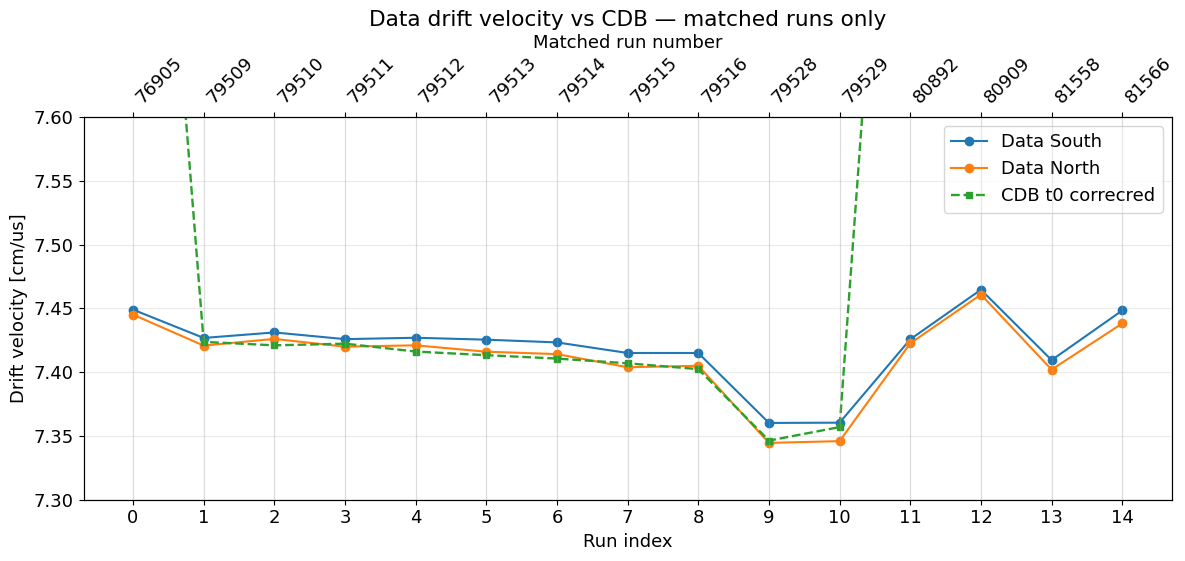

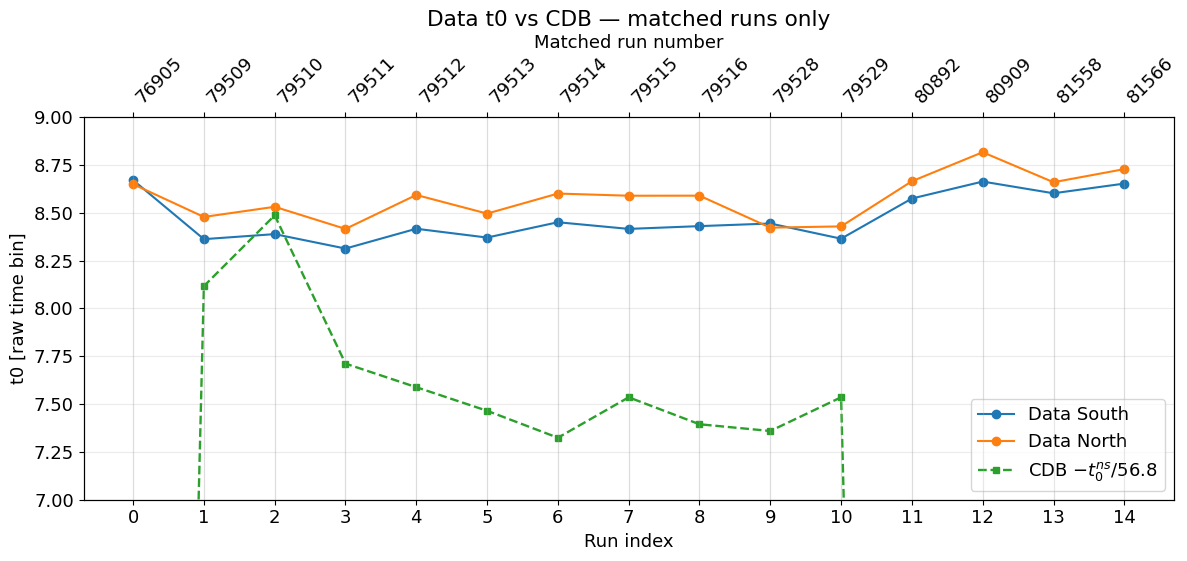

In [16]:
# ============================================================
# 7d. Data vs CDB as a function of consecutive RUN INDEX
# ============================================================

def add_run_number_top_axis(ax, run_indices, runs):
    """
    Primary x axis = consecutive run index.
    Secondary top axis = actual run number used for matching.
    """
    top = ax.twiny()
    top.set_xlim(ax.get_xlim())
    top.set_xticks(run_indices)
    top.set_xticklabels([str(r) for r in runs], rotation=45, ha="left")
    top.set_xlabel("Matched run number")
    return top


if len(CDB_COMPARISON):
    idx = CDB_COMPARISON["run_index"].to_numpy(dtype=int)
    runs = CDB_COMPARISON["run"].to_numpy(dtype=int)

    # --------------------------------------------------------
    # Drift velocity
    # --------------------------------------------------------
    fig, ax = plt.subplots(figsize=(12, 5.8))

    for side in (0, 1):
        ax.plot(
            idx,
            CDB_COMPARISON[f"data_vdrift_side{side}"],
            "o-",
            label=f"Data {SIDE_LABEL[side]}",
        )

    ax.plot(
        idx,
        CDB_COMPARISON["cdb_vdrift_cm_us"],
        "s--",
        lw=1.7,
        ms=5,
        label="CDB t0 correcred",
    )

    ax.set_xticks(idx)
    ax.set_xticklabels([str(i) for i in idx])
    ax.set_xlabel("Run index")
    ax.set_ylabel("Drift velocity [cm/us]")
    ax.set_title("Data drift velocity vs CDB — matched runs only")
    ax.legend()
    add_run_number_top_axis(ax, idx, runs)
    fig.tight_layout()
    ax.set_ylim(7.3, 7.6)

    if SAVE_FIGURES:
        fig.savefig(OUTPUT_DIR / "comparison_vdrift_data_cdb_run_index.png", dpi=170)
        fig.savefig(OUTPUT_DIR / "comparison_vdrift_data_cdb_run_index.pdf")

    plt.show()

    # --------------------------------------------------------
    # t0
    # --------------------------------------------------------
    fig, ax = plt.subplots(figsize=(12, 5.8))

    for side in (0, 1):
        ax.plot(
            idx,
            CDB_COMPARISON[f"data_t0_side{side}"],
            "o-",
            label=f"Data {SIDE_LABEL[side]}",
        )

    ax.plot(
        idx,
        CDB_COMPARISON["cdb_t0_raw_bin"],
        "s--",
        lw=1.7,
        ms=5,
        label=r"CDB $-t_0^{ns}/56.8$",
    )

    ax.set_xticks(idx)
    ax.set_xticklabels([str(i) for i in idx])
    ax.set_xlabel("Run index")
    ax.set_ylabel("t0 [raw time bin]")
    ax.set_title("Data t0 vs CDB — matched runs only")
    ax.legend()
    add_run_number_top_axis(ax, idx, runs)
    fig.tight_layout()
    ax.set_ylim(7, 9)
    #setting y limit to avoid the nonphysical t0=0 outliers in CDB

    if SAVE_FIGURES:
        fig.savefig(OUTPUT_DIR / "comparison_t0_data_cdb_run_index.png", dpi=170)
        fig.savefig(OUTPUT_DIR / "comparison_t0_data_cdb_run_index.pdf")

    plt.show()
else:
    print("No common runs between SUMMARY and the two CDB graphs.")



## PHGarfield-\(z\) comparison

For comparing North and South directly, define the **side-folded coordinate**

\[
u =
\begin{cases}
-z, & \text{South},\\
+z, & \text{North}.
\end{cases}
\]

Then the nominal active half-TPC is approximately

\[
0 < u < 102.605~{\rm cm}.
\]

Checks:

- **CM edge:** should be near \(u=0\). A displacement is a residual between the PHGarfield \(P/T\)-corrected mapping and the data.
- **Pad-plane / \(t_0\) edge:** should be near \(u\simeq102.605\) cm.


### Cleaning the nonphysical \(z\) branches

The low-ADC structures in the raw \(z\) histogram are not treated as statistical
fluctuations and are **not averaged into the physical curve**.

Instead, after folding South/North into the common coordinate \(u\):

1. split the \(z\) axis at the real physical boundaries \(u=0\) (CM) and
   \(u=102.605\) cm (pad plane);
2. inside each region, move in consecutive \(\sim1\) cm windows;
3. keep the **original point with the largest ADC** in each window;
4. optionally reject a remaining isolated selected point if it lies far below
   the neighboring selected maxima.

This is an upper-branch selection, not a rebin. The real edges at the CM and pad
plane are protected because no selection window is allowed to cross them.


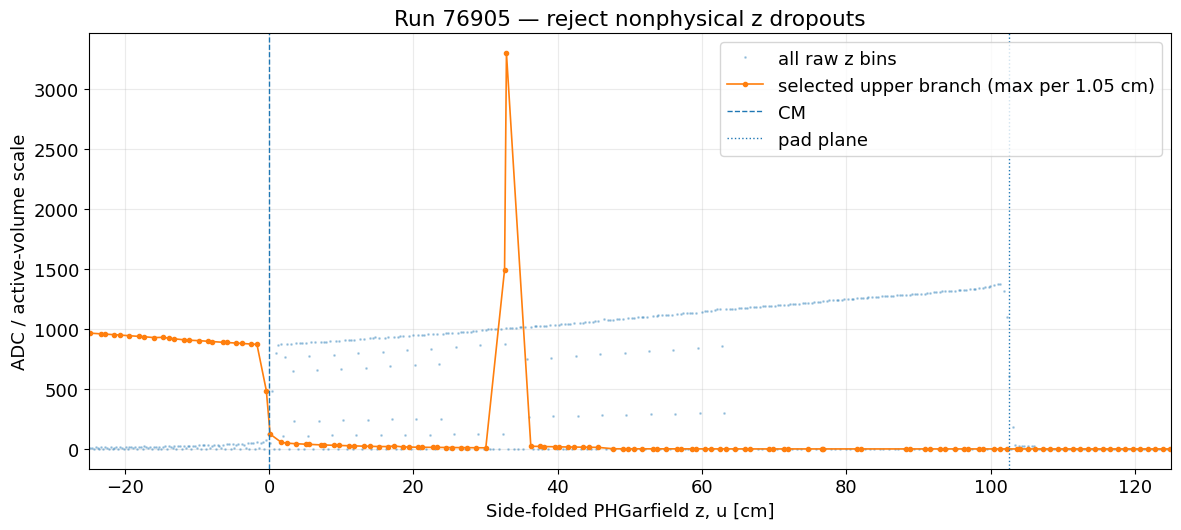

In [17]:
# ============================================================
# z cleaning diagnostic: raw points vs selected physical upper branch
# ============================================================

Z_DIAGNOSTIC_RUN = AVAILABLE_RUNS[0]
Z_DIAGNOSTIC_SIDE = 0

if Z_DIAGNOSTIC_SIDE in DATA[Z_DIAGNOSTIC_RUN]["z"]:
    z_raw, y_raw, _ = DATA[Z_DIAGNOSTIC_RUN]["z"][Z_DIAGNOSTIC_SIDE]

    sign = +1.0 if Z_DIAGNOSTIC_SIDE == 1 else -1.0
    u_raw = sign * z_raw
    order = np.argsort(u_raw)
    u_raw = u_raw[order]
    y_raw = y_raw[order]

    u_sel, y_sel = select_physical_z_branch(
        Z_DIAGNOSTIC_SIDE, z_raw, y_raw
    )

    # Same vertical scale for raw and selected data.
    scale_mask = (u_sel > 20) & (u_sel < 80)
    scale = np.nanmedian(y_sel[scale_mask]) if np.any(scale_mask) else np.nanmax(y_sel)

    fig, ax = plt.subplots(figsize=(12, 5.5))
    ax.plot(
        u_raw, y_raw / scale,
        ".", ms=2.0, alpha=0.30,
        label="all raw z bins"
    )
    ax.plot(
        u_sel, y_sel / scale,
        "o-", ms=3.0, lw=1.2,
        label=f"selected upper branch (max per {Z_MAX_WINDOW_CM:.2f} cm)"
    )

    ax.axvline(0, ls="--", lw=1, label="CM")
    ax.axvline(Z_PAD_CM, ls=":", lw=1, label="pad plane")
    ax.set_xlim(-25, 125)
    ax.set_xlabel("Side-folded PHGarfield z, u [cm]")
    ax.set_ylabel("ADC / active-volume scale")
    ax.set_title(
        f"Run {Z_DIAGNOSTIC_RUN} — reject nonphysical z dropouts"
    )
    ax.legend()
    fig.tight_layout()
    plt.show()


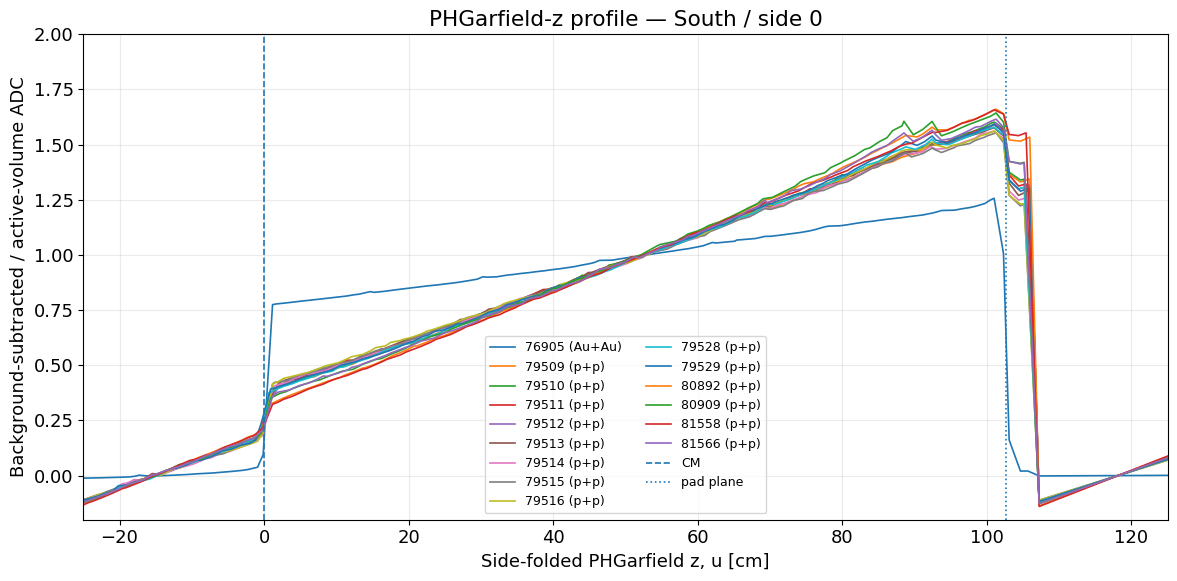

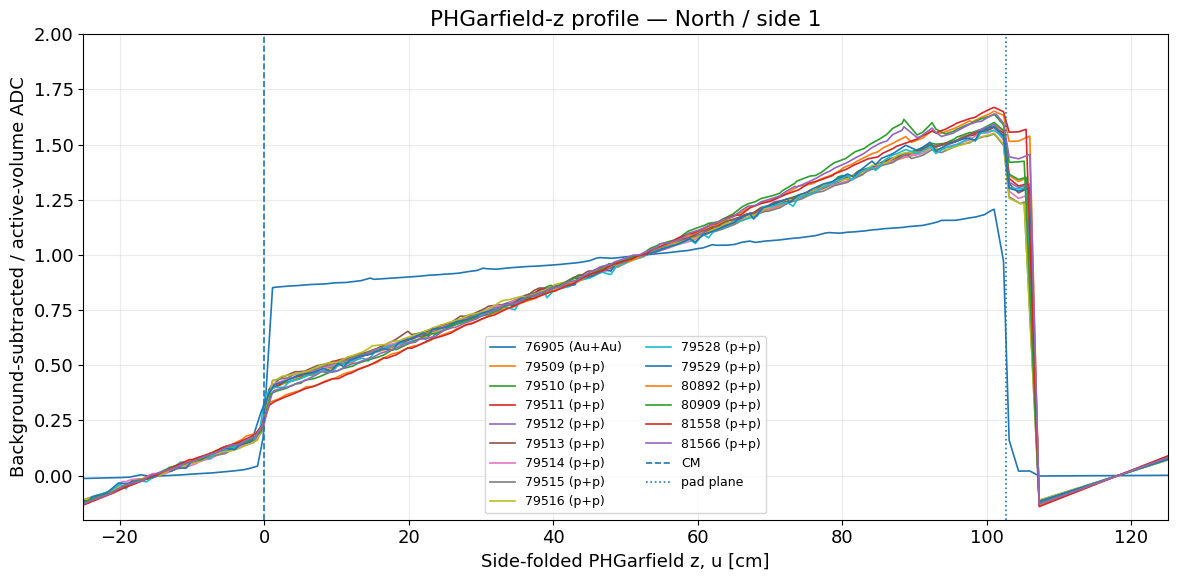

In [18]:

# ============================================================
# 8. Folded-z full profiles
# ============================================================

Z_FOLDED = {}

for run in AVAILABLE_RUNS:
    Z_FOLDED[run] = {}

    for side in (0, 1):
        if side not in DATA[run]["z"]:
            continue

        z, y, _ = DATA[run]["z"][side]
        u, yy = select_physical_z_branch(side, z, y)

        bg, p, used = robust_poly_background(
            u, yy, Z_BG_WINDOWS, degree=Z_BG_POLY_DEGREE
        )
        sub = yy - bg

        norm_level = window_median(u, sub, (20, 85))
        norm = sub / norm_level if np.isfinite(norm_level) and norm_level != 0 else np.full_like(sub, np.nan)

        Z_FOLDED[run][side] = {
            "u": u,
            "raw": yy,
            "bg": bg,
            "sub": sub,
            "norm": norm,
        }

for side in (0, 1):
    fig, ax = plt.subplots(figsize=(12, 6))

    for run in AVAILABLE_RUNS:
        if side not in Z_FOLDED.get(run, {}):
            continue
        d = Z_FOLDED[run][side]
        ax.plot(d["u"], d["norm"], lw=1.2, label=f"{run} ({GROUP_OF_RUN[run]})")

    ax.axvline(0, ls="--", lw=1.2, label="CM")
    ax.axvline(Z_PAD_CM, ls=":", lw=1.2, label="pad plane")
    ax.set_xlim(*Z_FULL_XLIM)
    ax.set_ylim(-0.2, 1.4)
    ax.set_xlabel("Side-folded PHGarfield z, u [cm]")
    ax.set_ylabel("Background-subtracted / active-volume ADC")
    ax.set_title(f"PHGarfield-z profile — {SIDE_LABEL[side]} / side {side}")
    ax.legend(fontsize=9, ncol=2)
    fig.tight_layout()
    ax.set_ylim(-0.2,2.0)

    if SAVE_FIGURES:
        fig.savefig(OUTPUT_DIR / f"z_folded_full_side{side}.png", dpi=170)
        fig.savefig(OUTPUT_DIR / f"z_folded_full_side{side}.pdf")

    plt.show()


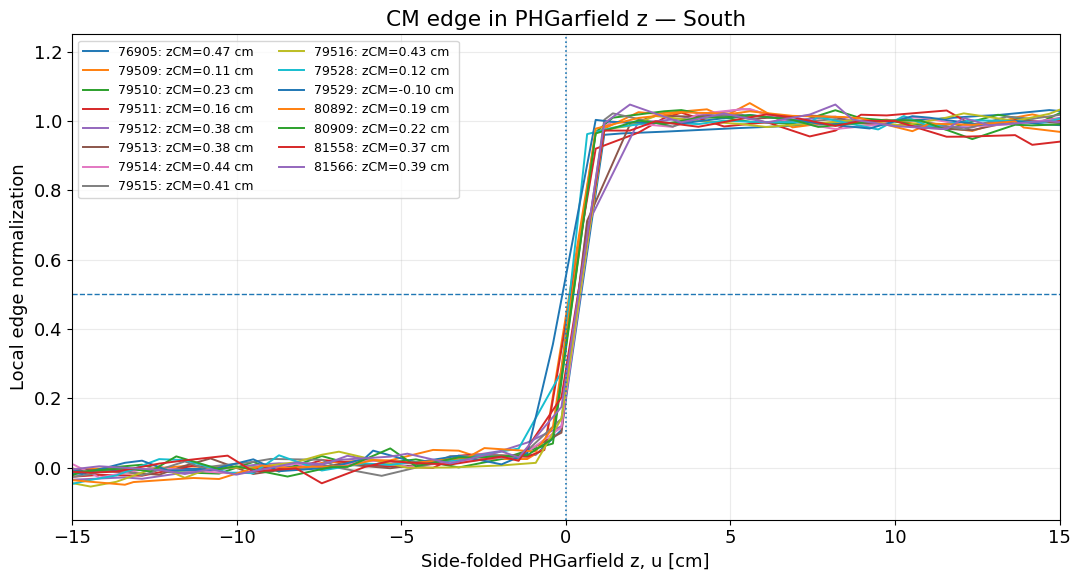

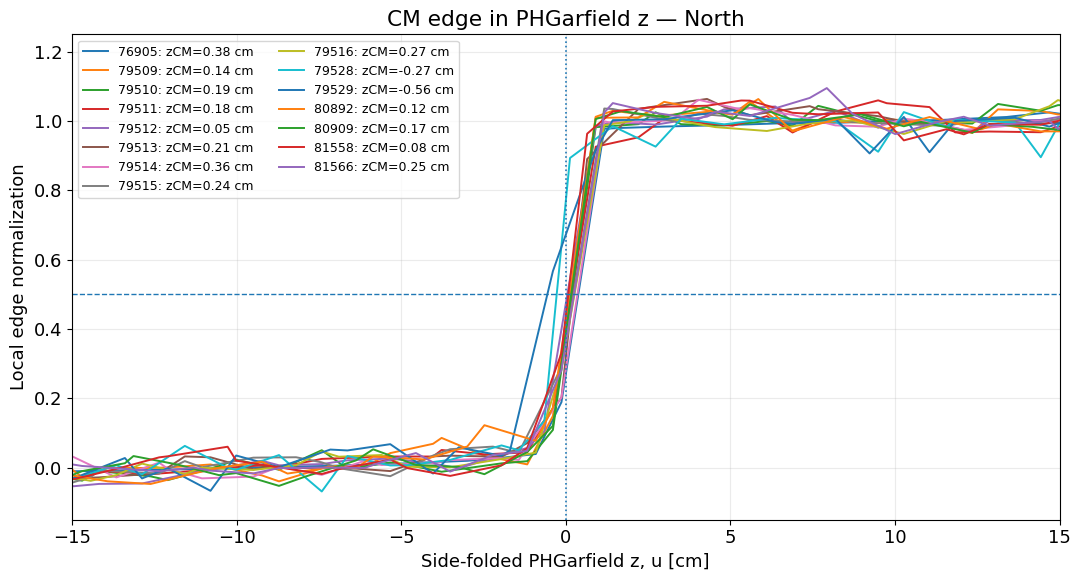

In [19]:

# ============================================================
# 9. PHGarfield-z CM edge near zero
# ============================================================

Z_CM_RESULTS = {}

for side in (0, 1):
    fig, ax = plt.subplots(figsize=(11, 6))

    for run in AVAILABLE_RUNS:
        if side not in Z_FOLDED.get(run, {}):
            continue

        d = Z_FOLDED[run][side]
        u = d["u"]
        y = d["raw"]

        m = edge_metrics(
            u, y,
            Z_CM_LEFT_LEVEL,
            Z_CM_RIGHT_LEVEL,
            Z_CM_SEARCH,
            expected=Z_CM_EXPECTED,
        )
        Z_CM_RESULTS[(run, side)] = m

        yn = normalize_between_levels(y, m["left_level"], m["right_level"])
        ax.plot(u, yn, lw=1.4, label=f"{run}: zCM={m['x50']:.2f} cm")

    ax.axhline(0.5, ls="--", lw=1)
    ax.axvline(0, ls=":", lw=1.2)
    ax.set_xlim(*Z_CM_ZOOM)
    ax.set_ylim(-0.15, 1.25)
    ax.set_xlabel("Side-folded PHGarfield z, u [cm]")
    ax.set_ylabel("Local edge normalization")
    ax.set_title(f"CM edge in PHGarfield z — {SIDE_LABEL[side]}")
    ax.legend(fontsize=9, ncol=2)
    fig.tight_layout()

    if SAVE_FIGURES:
        fig.savefig(OUTPUT_DIR / f"z_cm_zoom_side{side}.png", dpi=170)
        fig.savefig(OUTPUT_DIR / f"z_cm_zoom_side{side}.pdf")

    plt.show()


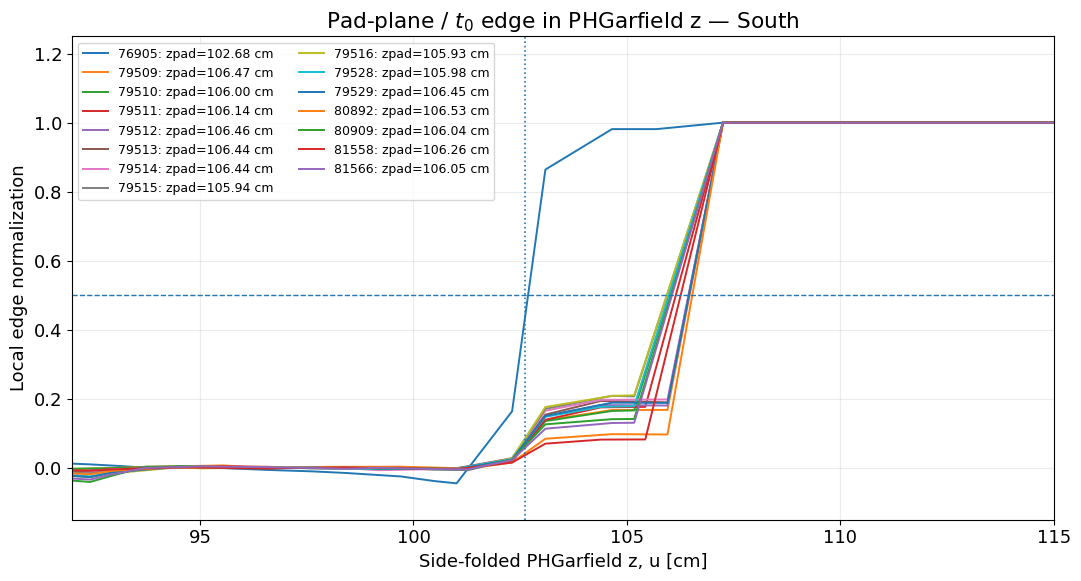

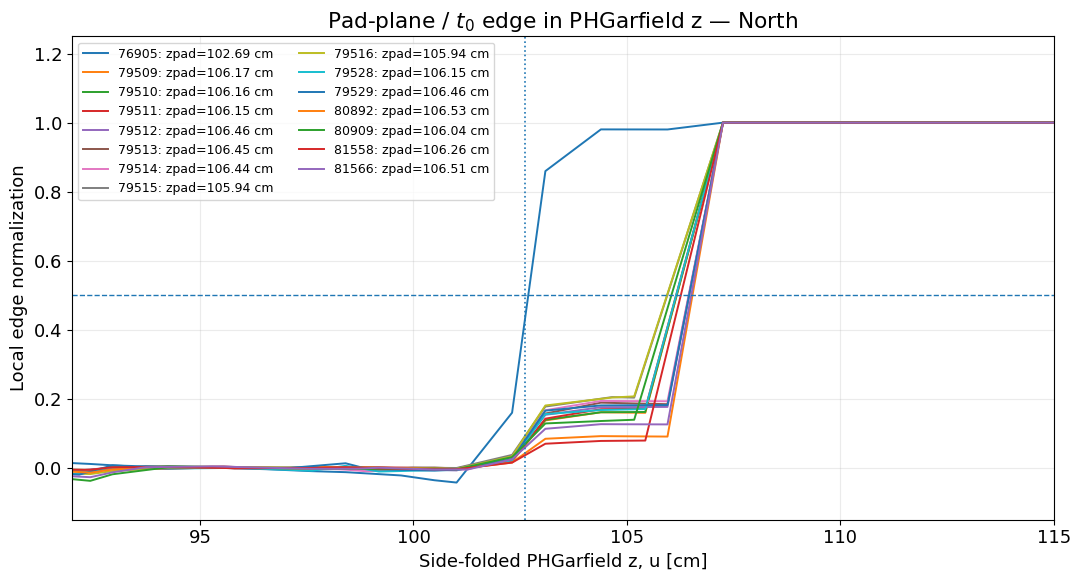

In [20]:

# ============================================================
# 10. PHGarfield-z pad-plane / t0 edge
# ============================================================

Z_PAD_RESULTS = {}

for side in (0, 1):
    fig, ax = plt.subplots(figsize=(11, 6))

    for run in AVAILABLE_RUNS:
        if side not in Z_FOLDED.get(run, {}):
            continue

        d = Z_FOLDED[run][side]
        u = d["u"]
        y = d["raw"]

        m = edge_metrics(
            u, y,
            Z_PAD_LEFT_LEVEL,
            Z_PAD_RIGHT_LEVEL,
            Z_PAD_SEARCH,
            expected=Z_PAD_EXPECTED,
        )
        Z_PAD_RESULTS[(run, side)] = m

        yn = normalize_between_levels(y, m["left_level"], m["right_level"])
        ax.plot(u, yn, lw=1.4, label=f"{run}: zpad={m['x50']:.2f} cm")

    ax.axhline(0.5, ls="--", lw=1)
    ax.axvline(Z_PAD_CM, ls=":", lw=1.2)
    ax.set_xlim(*Z_PAD_ZOOM)
    ax.set_ylim(-0.15, 1.25)
    ax.set_xlabel("Side-folded PHGarfield z, u [cm]")
    ax.set_ylabel("Local edge normalization")
    ax.set_title(f"Pad-plane / $t_0$ edge in PHGarfield z — {SIDE_LABEL[side]}")
    ax.legend(fontsize=9, ncol=2)
    fig.tight_layout()

    if SAVE_FIGURES:
        fig.savefig(OUTPUT_DIR / f"z_pad_zoom_side{side}.png", dpi=170)
        fig.savefig(OUTPUT_DIR / f"z_pad_zoom_side{side}.pdf")

    plt.show()


## Pad-plane edge after dedicated \(z\)-background subtraction

For p+p the selected physical \(z\) branch contains a large background, at roughly
the same level already visible for \(u<0\).  The background also has a small
\(z\)-dependence.

The corrected treatment uses only two background-controlled regions:

1. **\(u<0\)**: determine the background slope;
2. **\(103<u<105\) cm**: determine the background level near the pad plane.

The later sharp drop to zero around \(106\) cm is explicitly **not** used for the
background.  After constructing this line, it is subtracted from the cleaned upper
branch and the pad-plane edge is extracted only below \(105\) cm.


In [21]:
# ============================================================
# 10b. Dedicated z-background subtraction for pad-plane study
# ============================================================

Z_BG_SUBTRACTED = {}
z_bg_rows = []

for run in AVAILABLE_RUNS:
    Z_BG_SUBTRACTED[run] = {}

    for side in (0, 1):
        if side not in Z_FOLDED.get(run, {}):
            continue

        d = Z_FOLDED[run][side]
        u = np.asarray(d["u"], dtype=float)
        y = np.asarray(d["raw"], dtype=float)

        bg, info = z_background_from_negative_slope_and_pad_anchor(u, y)
        y_sub = y - bg

        edge = z_pad_edge_after_background(
            u,
            y_sub,
            info["crack_cm"],
        )

        Z_BG_SUBTRACTED[run][side] = {
            "u": u,
            "raw": y,
            "bg": bg,
            "sub": y_sub,
            "info": info,
            "edge": edge,
        }

        z_bg_rows.append({
            "run": run,
            "system": GROUP_OF_RUN[run],
            "side": side,
            "side_name": SIDE_LABEL[side],
            "first_crack_cm": info["crack_cm"],
            "bg_slope_adc_per_cm": info["slope_adc_per_cm"],
            "bg_anchor_u_cm": info["anchor_u_cm"],
            "bg_anchor_adc": info["anchor_adc"],
            "zpad_bgsub_50_cm": edge["x50"],
            "zpad_bgsub_width_10_90_cm": edge["width_10_90"],
            "zpad_bgsub_residual_cm": edge["x50"] - Z_PAD_CM
                if np.isfinite(edge["x50"]) else np.nan,
        })

Z_BG_SUMMARY = pd.DataFrame(z_bg_rows).sort_values(["run", "side"]).reset_index(drop=True)

display(Z_BG_SUMMARY)
Z_BG_SUMMARY.to_csv(OUTPUT_DIR / "z_pad_background_subtracted_summary.csv", index=False)


,run,system,side,side_name,first_crack_cm,bg_slope_adc_per_cm,bg_anchor_u_cm,bg_anchor_adc,zpad_bgsub_50_cm,zpad_bgsub_width_10_90_cm,zpad_bgsub_residual_cm
0,76905,Au+Au,0,South,101.66,2.590147e+07,103.87,1.653110e+09,102.628785,1.314332,0.023785
1,76905,Au+Au,1,North,101.66,2.650113e+07,103.74,1.531026e+09,102.633130,1.297989,0.028130
2,79509,p+p,0,South,101.66,1.037759e+06,103.87,2.519358e+09,102.681229,1.093690,0.076229
3,79509,p+p,1,North,101.66,1.121819e+06,103.74,2.291070e+09,102.668170,1.096616,0.063170
4,79510,p+p,0,South,101.66,1.170771e+06,103.87,2.487951e+09,102.678360,1.104174,0.073360
5,79510,p+p,1,North,101.66,1.180455e+06,103.74,2.256378e+09,102.653904,1.187977,0.048904
6,79511,p+p,0,South,101.66,1.340890e+06,103.74,2.333704e+09,102.689189,1.170899,0.084189
7,79511,p+p,1,North,101.66,1.060208e+06,103.74,2.109484e+09,102.676765,1.073517,0.071765
8,79512,p+p,0,South,101.79,7.917799e+05,103.74,2.254595e+09,102.666409,1.105292,0.061409
9,79512,p+p,1,North,101.66,1.070101e+06,103.74,2.046962e+09,102.618483,1.393309,0.013483


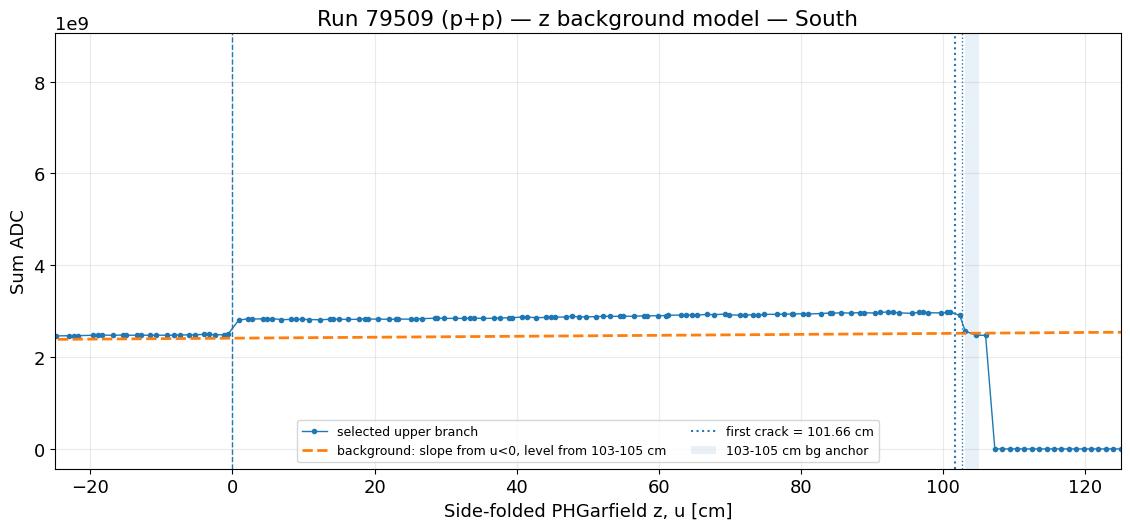

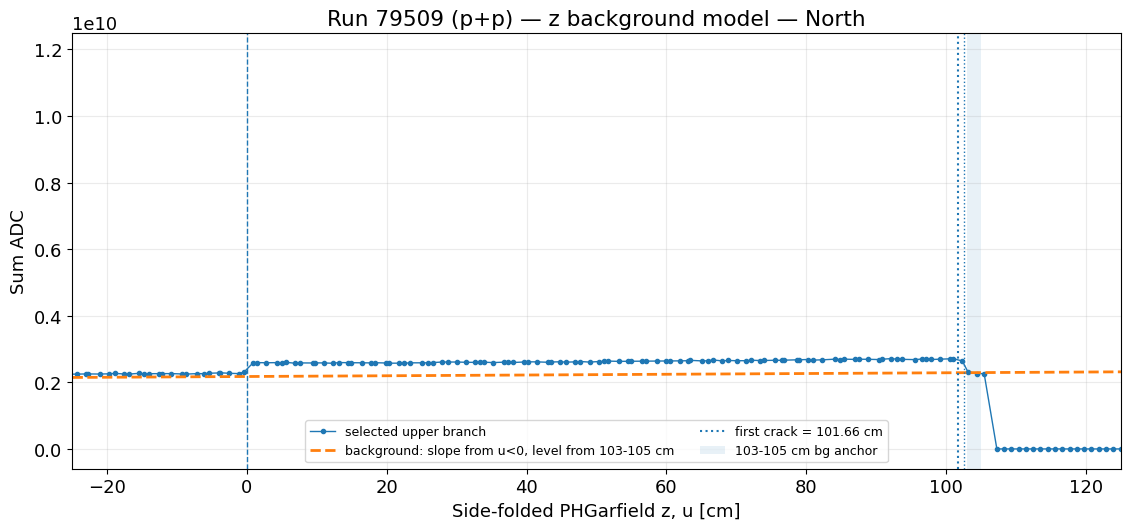

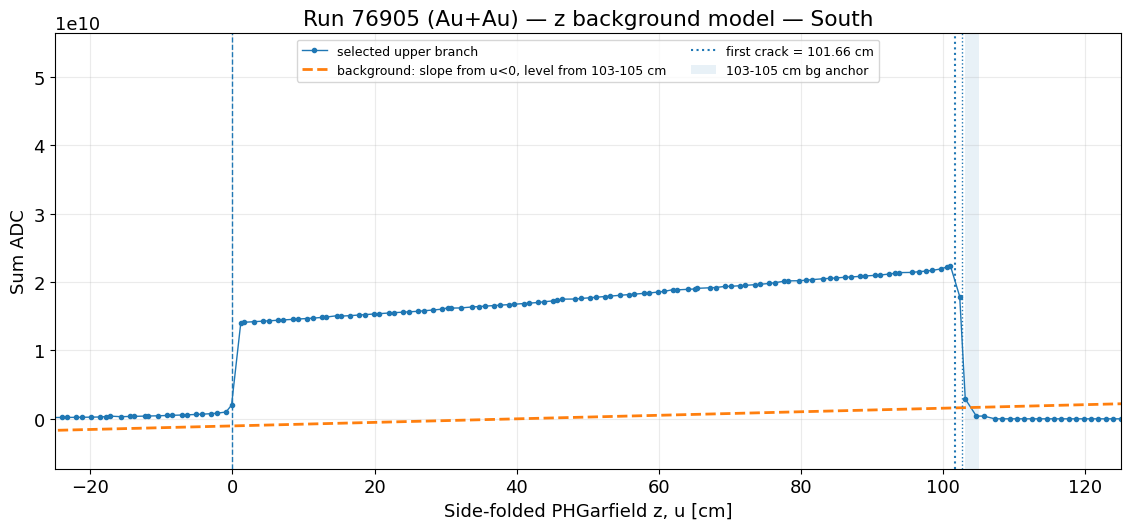

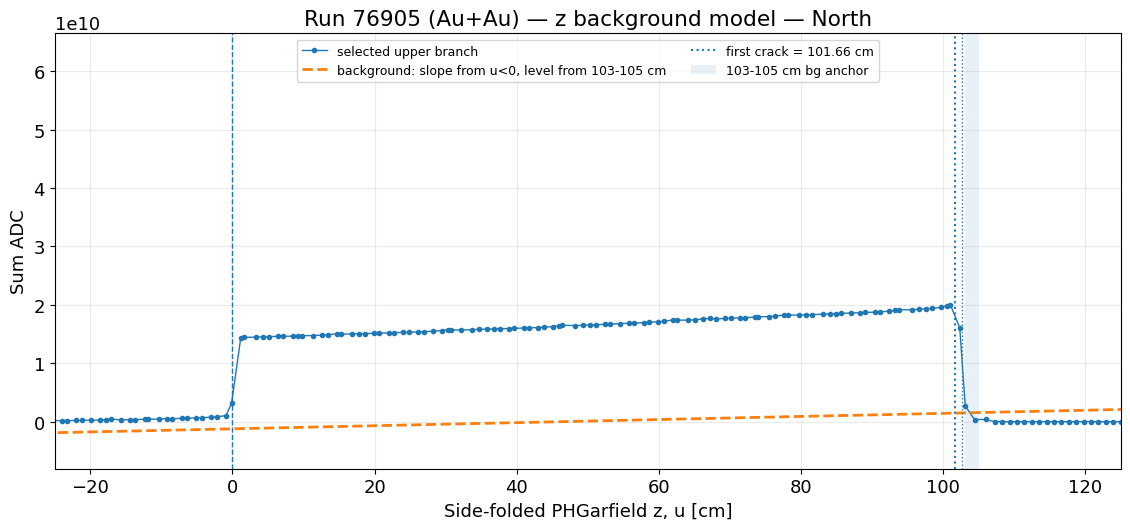

In [22]:
# ============================================================
# 10c. Background-model diagnostic
#      show one p+p and one Au+Au run when available
# ============================================================

diagnostic_runs = []

available_pp = [r for r in AVAILABLE_RUNS if GROUP_OF_RUN.get(r) == "p+p"]
available_auau = [r for r in AVAILABLE_RUNS if GROUP_OF_RUN.get(r) == "Au+Au"]

if available_pp:
    diagnostic_runs.append(available_pp[0])
if available_auau:
    diagnostic_runs.append(available_auau[0])

for run in diagnostic_runs:
    for side in (0, 1):
        if side not in Z_BG_SUBTRACTED.get(run, {}):
            continue

        d = Z_BG_SUBTRACTED[run][side]
        u = d["u"]
        y = d["raw"]
        bg = d["bg"]
        info = d["info"]

        fig, ax = plt.subplots(figsize=(11.5, 5.5))
        ax.plot(u, y, "o-", ms=3, lw=1.0, label="selected upper branch")
        ax.plot(
            u, bg, "--", lw=2.0,
            label="background: slope from u<0, level from 103-105 cm"
        )

        if np.isfinite(info["crack_cm"]):
            ax.axvline(
                info["crack_cm"],
                ls=":", lw=1.5,
                label=f"first crack = {info['crack_cm']:.2f} cm",
            )

        anchor_lo, anchor_hi = Z_BG_PAD_ANCHOR_WINDOW
        ax.axvspan(
            anchor_lo,
            anchor_hi,
            alpha=0.10,
            label="103-105 cm bg anchor",
        )

        ax.axvline(0, ls="--", lw=1)
        ax.axvline(Z_PAD_CM, ls=":", lw=1)

        ax.set_xlim(-25, 125)
        ax.set_xlabel("Side-folded PHGarfield z, u [cm]")
        ax.set_ylabel("Sum ADC")
        ax.set_title(
            f"Run {run} ({GROUP_OF_RUN[run]}) — z background model — {SIDE_LABEL[side]}"
        )
        ax.legend(fontsize=9, ncol=2)
        fig.tight_layout()

        if SAVE_FIGURES:
            fig.savefig(
                OUTPUT_DIR / f"z_background_model_run{run}_side{side}.png",
                dpi=170,
            )

        plt.show()


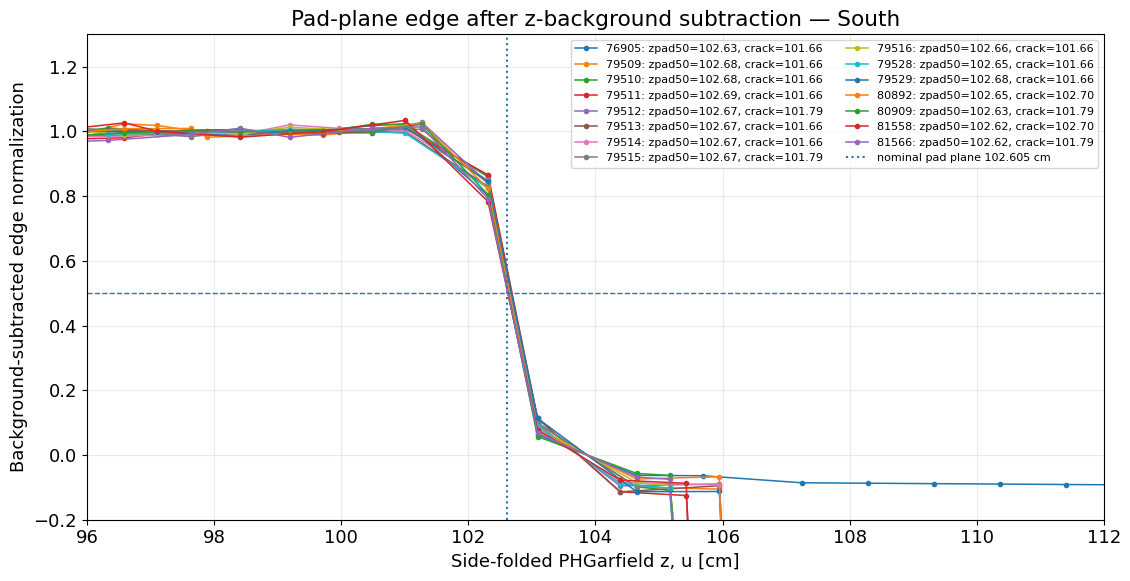

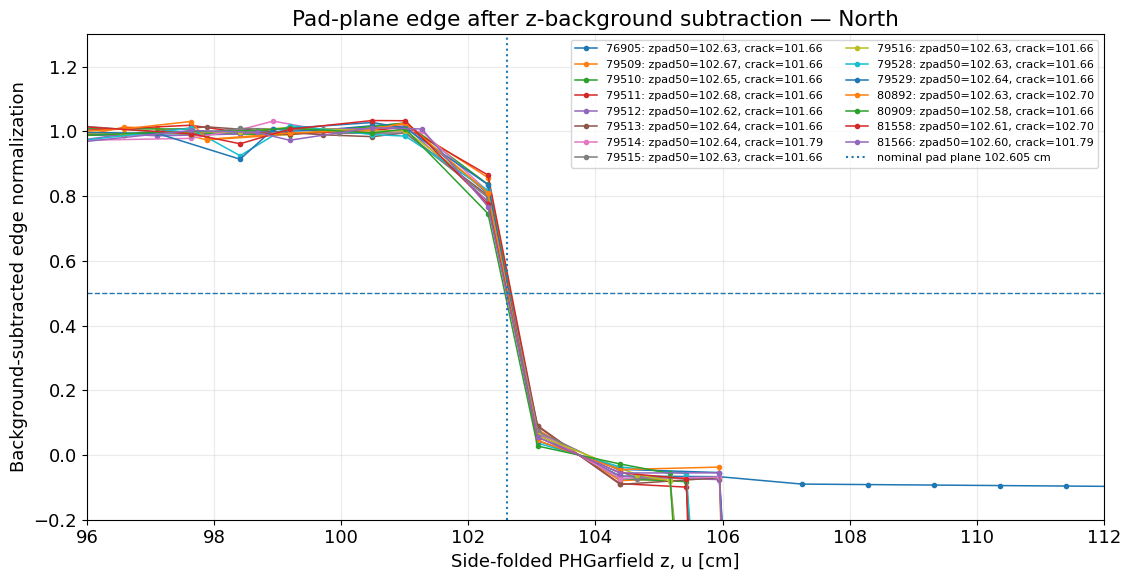

In [23]:
# ============================================================
# 10d. Pad-plane / t0 edge AFTER dedicated z-background subtraction
# ============================================================

Z_PAD_BG_RESULTS = {}

for side in (0, 1):
    fig, ax = plt.subplots(figsize=(11.5, 6))

    for run in AVAILABLE_RUNS:
        if side not in Z_BG_SUBTRACTED.get(run, {}):
            continue

        d = Z_BG_SUBTRACTED[run][side]
        u = d["u"]
        y_sub = d["sub"]
        edge = d["edge"]
        crack = d["info"]["crack_cm"]

        Z_PAD_BG_RESULTS[(run, side)] = edge

        left = edge["left_level"]
        right = edge["right_level"]
        denom = left - right

        # For a falling pad-plane edge, display 1 before the edge and 0 after it.
        if np.isfinite(denom) and denom != 0:
            yn = (y_sub - right) / denom
        else:
            yn = np.full_like(y_sub, np.nan)

        label = f"{run}"
        if np.isfinite(edge["x50"]):
            label += f": zpad50={edge['x50']:.2f}"
        if np.isfinite(crack):
            label += f", crack={crack:.2f}"

        ax.plot(u, yn, "o-", ms=3.0, lw=1.1, label=label)

    ax.axhline(0.5, ls="--", lw=1)
    ax.axvline(Z_PAD_CM, ls=":", lw=1.5, label=f"nominal pad plane {Z_PAD_CM:.3f} cm")

    ax.set_xlim(96, 112)
    ax.set_ylim(-0.20, 1.30)
    ax.set_xlabel("Side-folded PHGarfield z, u [cm]")
    ax.set_ylabel("Background-subtracted edge normalization")
    ax.set_title(
        f"Pad-plane edge after z-background subtraction — {SIDE_LABEL[side]}"
    )
    ax.legend(fontsize=8, ncol=2)
    fig.tight_layout()

    if SAVE_FIGURES:
        fig.savefig(
            OUTPUT_DIR / f"z_pad_bgsub_zoom_side{side}.png",
            dpi=170,
        )
        fig.savefig(
            OUTPUT_DIR / f"z_pad_bgsub_zoom_side{side}.pdf"
        )

    plt.show()


In [24]:
# ============================================================
# 10e. Check the z-background constraints numerically
# ============================================================

bg_check_rows = []

for run in AVAILABLE_RUNS:
    for side in (0, 1):
        if side not in Z_BG_SUBTRACTED.get(run, {}):
            continue

        d = Z_BG_SUBTRACTED[run][side]
        u = d["u"]
        y = d["raw"]
        bg = d["bg"]
        info = d["info"]

        neg_mask = window_mask(u, Z_BG_NEGATIVE_FIT_WINDOW)
        anchor_mask = window_mask(u, Z_BG_PAD_ANCHOR_WINDOW)

        bg_check_rows.append({
            "run": run,
            "system": GROUP_OF_RUN[run],
            "side": side,
            "side_name": SIDE_LABEL[side],
            "first_crack_cm": info["crack_cm"],
            "bg_slope_adc_per_cm": info["slope_adc_per_cm"],
            "raw_median_u_lt_0": float(np.median(y[neg_mask])) if np.any(neg_mask) else np.nan,
            "raw_median_103_105": float(np.median(y[anchor_mask])) if np.any(anchor_mask) else np.nan,
            "model_median_103_105": float(np.median(bg[anchor_mask])) if np.any(anchor_mask) else np.nan,
        })

Z_BG_CHECK = pd.DataFrame(bg_check_rows)
display(Z_BG_CHECK)


,run,system,side,side_name,first_crack_cm,bg_slope_adc_per_cm,raw_median_u_lt_0,raw_median_103_105,model_median_103_105
0,76905,Au+Au,0,South,101.66,2.590147e+07,3.968813e+08,1.653110e+09,1.653110e+09
1,76905,Au+Au,1,North,101.66,2.650113e+07,4.042548e+08,1.531026e+09,1.531026e+09
2,79509,p+p,0,South,101.66,1.037759e+06,2.477338e+09,2.519358e+09,2.519358e+09
3,79509,p+p,1,North,101.66,1.121819e+06,2.259112e+09,2.291070e+09,2.291070e+09
4,79510,p+p,0,South,101.66,1.170771e+06,2.447012e+09,2.487951e+09,2.487951e+09
5,79510,p+p,1,North,101.66,1.180455e+06,2.221925e+09,2.256378e+09,2.256378e+09
6,79511,p+p,0,South,101.66,1.340890e+06,2.284855e+09,2.333704e+09,2.333704e+09
7,79511,p+p,1,North,101.66,1.060208e+06,2.068237e+09,2.109484e+09,2.109484e+09
8,79512,p+p,0,South,101.79,7.917799e+05,2.216656e+09,2.254595e+09,2.254595e+09
9,79512,p+p,1,North,101.66,1.070101e+06,2.018256e+09,2.046962e+09,2.046962e+09



## Recover the effective PHGarfield drift velocity from the two edges

Because the same raw-time distribution was transformed into the PHGarfield-\(z\)
distribution, the slope of that transformation can be recovered directly from
the two corresponding edges.

For each run and side,

\[
v_{\rm PHG}^{\rm edge}
=
\frac{u_{\rm pad}^{\rm PHG}-u_{\rm CM}^{\rm PHG}}
     {(t_{\rm CM}-t_{\rm pad})\,\Delta t_{\rm bin}}.
\]

Here:

- \(t_{\rm pad}\) is the measured rising \(t_0\) edge in raw time bins;
- \(t_{\rm CM}\) is the measured falling CM edge in raw time bins;
- \(u_{\rm pad}^{\rm PHG}\) is the background-subtracted pad-plane edge in the
  PHGarfield-\(z\) histogram;
- \(u_{\rm CM}^{\rm PHG}\) is the CM edge in the cleaned PHGarfield-\(z\) histogram.

This is useful because the absolute PHGarfield \(t_0=8\) cancels in the edge
difference.  The result is the **effective PHGarfield mapping velocity** encoded
in the run/side \(t\rightarrow z\) transformation.

For comparison, the data drift velocity uses the physical drift distance,

\[
v_{\rm data}
=
\frac{102.605-0.28}
     {(t_{\rm CM}-t_{\rm pad})\,\Delta t_{\rm bin}}.
\]


In [25]:
# ============================================================
# 10f. Recover the effective PHGarfield velocity from time + z edges
# ============================================================

phg_rows = []

for run in AVAILABLE_RUNS:
    for side in (0, 1):

        t0 = T0_RESULTS.get((run, side))
        cm = CM_RESULTS.get((run, side))
        zcm = Z_CM_RESULTS.get((run, side))
        zpad = Z_PAD_BG_RESULTS.get((run, side))

        if t0 is None or cm is None or zcm is None or zpad is None:
            continue

        t_pad_bin = t0["x50"]
        t_cm_bin = cm["x50"]
        z_cm_cm = zcm["x50"]
        z_pad_cm = zpad["x50"]

        dt_bins = t_cm_bin - t_pad_bin
        dt_ns = dt_bins * TPC_TIME_BIN_NS
        dz_phg_cm = z_pad_cm - z_cm_cm

        v_phg_cm_us = np.nan
        v_data_cm_us_check = np.nan

        if (
            np.isfinite(dt_ns)
            and dt_ns > 0
            and np.isfinite(dz_phg_cm)
            and dz_phg_cm > 0
        ):
            v_phg_cm_us = dz_phg_cm / dt_ns * 1000.0
            v_data_cm_us_check = DRIFT_LENGTH_CM / dt_ns * 1000.0

        phg_rows.append({
            "run": run,
            "system": GROUP_OF_RUN[run],
            "side": side,
            "side_name": SIDE_LABEL[side],

            "t_pad_bin": t_pad_bin,
            "t_cm_bin": t_cm_bin,
            "dt_bins": dt_bins,
            "dt_ns": dt_ns,

            "z_pad_edge_cm": z_pad_cm,
            "z_cm_edge_cm": z_cm_cm,
            "dz_phg_cm": dz_phg_cm,

            "v_phg_edges_cm_us": v_phg_cm_us,
            "v_data_check_cm_us": v_data_cm_us_check,
        })

PHG_EDGE_SUMMARY = (
    pd.DataFrame(phg_rows)
    .sort_values(["run", "side"])
    .reset_index(drop=True)
)

display(PHG_EDGE_SUMMARY)

PHG_EDGE_SUMMARY.to_csv(
    OUTPUT_DIR / "phgarfield_velocity_from_time_z_edges.csv",
    index=False,
)


,run,system,side,side_name,t_pad_bin,t_cm_bin,dt_bins,dt_ns,z_pad_edge_cm,z_cm_edge_cm,dz_phg_cm,v_phg_edges_cm_us,v_data_check_cm_us
0,76905,Au+Au,0,South,8.670114,250.513850,241.843737,13736.724244,102.628785,0.467431,102.161353,7.437097,7.449010
1,76905,Au+Au,1,North,8.648856,250.619800,241.970944,13743.949592,102.633130,0.382432,102.250698,7.439688,7.445094
2,79509,p+p,0,South,8.361653,250.928387,242.566735,13777.790525,102.681229,0.111934,102.569295,7.444539,7.426808
3,79509,p+p,1,North,8.477679,251.240506,242.762827,13788.928589,102.668170,0.138469,102.529700,7.435654,7.420809
4,79510,p+p,0,South,8.387933,250.813867,242.425934,13769.793052,102.678360,0.232703,102.445657,7.439884,7.431121
5,79510,p+p,1,North,8.530721,251.121656,242.590935,13779.165102,102.653904,0.192044,102.461860,7.435999,7.426067
6,79511,p+p,0,South,8.312508,250.909591,242.597082,13779.514283,102.689189,0.155713,102.533476,7.441008,7.425879
7,79511,p+p,1,North,8.415170,251.205649,242.790479,13790.499190,102.676765,0.175858,102.500907,7.432719,7.419963
8,79512,p+p,0,South,8.416030,250.977769,242.561739,13777.506758,102.666409,0.382198,102.284211,7.424000,7.426961
9,79512,p+p,1,North,8.592599,251.348196,242.755597,13788.517908,102.618483,0.049258,102.569225,7.438742,7.421030


,run_index,run,cdb_vdrift_cm_us,data_vdrift_side0,phg_vdrift_side0,data_vdrift_side1,phg_vdrift_side1
0,0,76905,8.119874,7.449010,7.437097,7.445094,7.439688
1,1,79509,7.423743,7.426808,7.444539,7.420809,7.435654
2,2,79510,7.421016,7.431121,7.439884,7.426067,7.435999
3,3,79511,7.422319,7.425879,7.441008,7.419963,7.432719
4,4,79512,7.416156,7.426961,7.424000,7.421030,7.438742
5,5,79513,7.413292,7.425455,7.422897,7.416021,7.423878
6,6,79514,7.410652,7.423308,7.415891,7.414142,7.411056
7,7,79515,7.406928,7.415024,7.410066,7.403849,7.408761
8,8,79516,7.402375,7.415019,7.408501,7.404984,7.408178
9,9,79528,7.346348,7.360187,7.374887,7.344529,7.385922


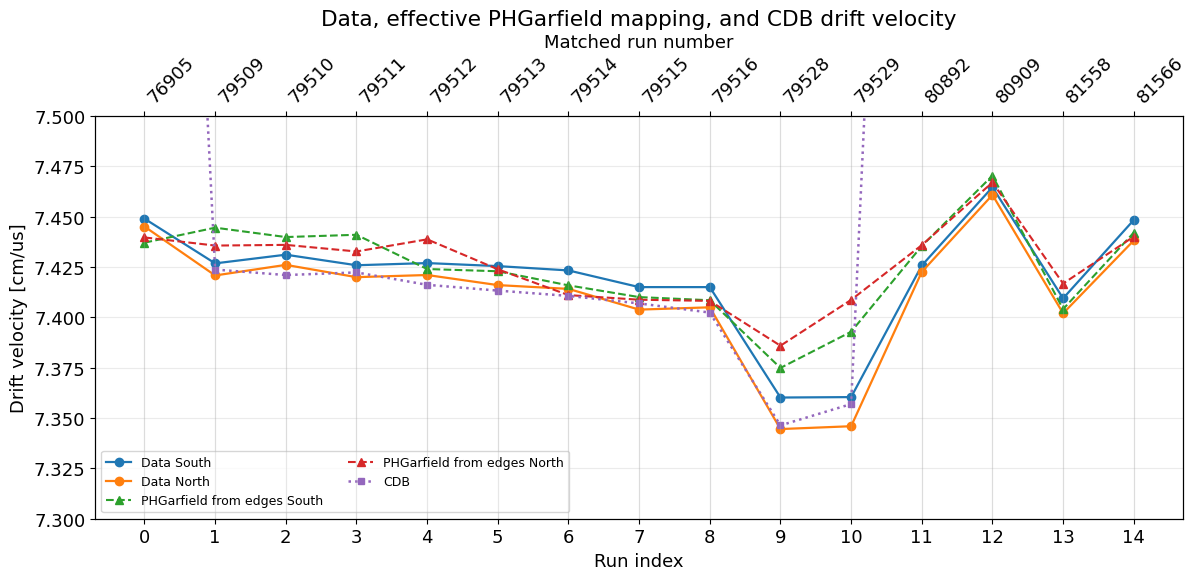

In [26]:
# ============================================================
# 10g. Data + recovered PHGarfield + CDB on the SAME run-index plot
# ============================================================

# Keep exactly the same matched-run list / run_index mapping as the
# existing Data-vs-CDB figure.
comparison_phg_rows = []

for _, base in CDB_COMPARISON.iterrows():
    run = int(base["run"])
    run_index = int(base["run_index"])

    row = {
        "run_index": run_index,
        "run": run,
        "cdb_vdrift_cm_us": float(base["cdb_vdrift_cm_us"]),
    }

    for side in (0, 1):
        row[f"data_vdrift_side{side}"] = float(base[f"data_vdrift_side{side}"])

        ss = PHG_EDGE_SUMMARY[
            (PHG_EDGE_SUMMARY["run"] == run)
            & (PHG_EDGE_SUMMARY["side"] == side)
        ]

        row[f"phg_vdrift_side{side}"] = (
            float(ss.iloc[0]["v_phg_edges_cm_us"])
            if len(ss)
            else np.nan
        )

    comparison_phg_rows.append(row)

CDB_COMPARISON_PHG = pd.DataFrame(comparison_phg_rows)

display(CDB_COMPARISON_PHG)


if len(CDB_COMPARISON_PHG):
    idx = CDB_COMPARISON_PHG["run_index"].to_numpy(dtype=int)
    runs = CDB_COMPARISON_PHG["run"].to_numpy(dtype=int)

    fig, ax = plt.subplots(figsize=(12, 6.0))

    # Data velocity from physical 102.325 cm drift length.
    for side in (0, 1):
        ax.plot(
            idx,
            CDB_COMPARISON_PHG[f"data_vdrift_side{side}"],
            "o-",
            lw=1.6,
            label=f"Data {SIDE_LABEL[side]}",
        )

    # Effective PHGarfield velocity recovered from the t->z mapping.
    for side in (0, 1):
        ax.plot(
            idx,
            CDB_COMPARISON_PHG[f"phg_vdrift_side{side}"],
            "^--",
            lw=1.5,
            ms=6,
            label=f"PHGarfield from edges {SIDE_LABEL[side]}",
        )

    # CDB reference.
    ax.plot(
        idx,
        CDB_COMPARISON_PHG["cdb_vdrift_cm_us"],
        "s:",
        lw=1.8,
        ms=5,
        label="CDB",
    )

    ax.set_xticks(idx)
    ax.set_xticklabels([str(i) for i in idx])
    ax.set_xlabel("Run index")
    ax.set_ylabel("Drift velocity [cm/us]")
    ax.set_title(
        "Data, effective PHGarfield mapping, and CDB drift velocity"
    )

    ax.legend(fontsize=9, ncol=2)
    add_run_number_top_axis(ax, idx, runs)

    fig.tight_layout()
    ax.set_ylim(7.3, 7.50)

    if SAVE_FIGURES:
        fig.savefig(
            OUTPUT_DIR / "comparison_vdrift_data_phg_cdb_run_index.png",
            dpi=170,
        )
        fig.savefig(
            OUTPUT_DIR / "comparison_vdrift_data_phg_cdb_run_index.pdf"
        )

    plt.show()


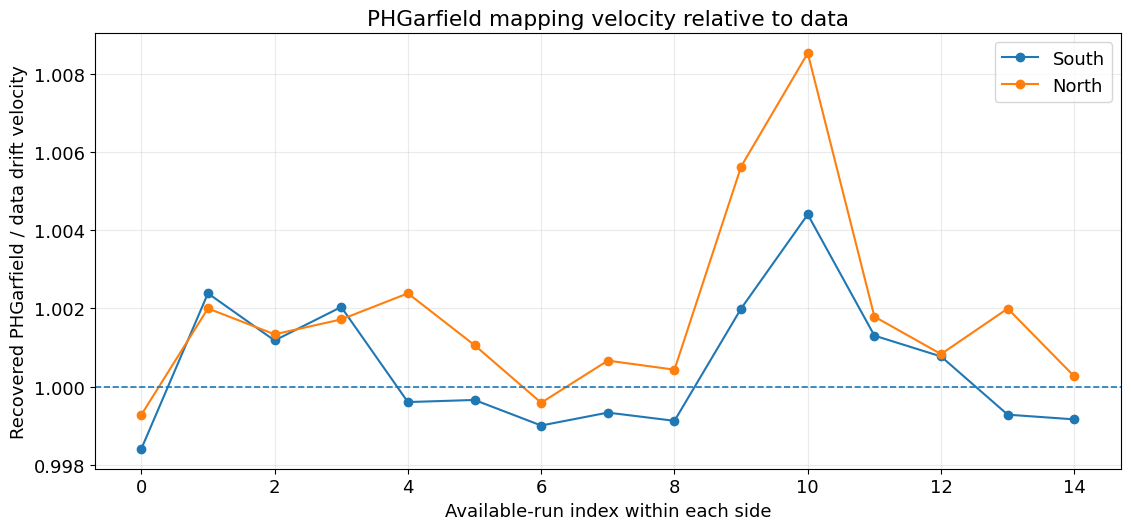

In [27]:
# ============================================================
# 10h. Useful diagnostic: PHGarfield effective velocity / data velocity
# ============================================================

fig, ax = plt.subplots(figsize=(11.5, 5.5))

for side in (0, 1):
    ss = PHG_EDGE_SUMMARY[PHG_EDGE_SUMMARY["side"] == side].copy()

    if not len(ss):
        continue

    ratio = (
        ss["v_phg_edges_cm_us"].to_numpy()
        / ss["v_data_check_cm_us"].to_numpy()
    )

    ax.plot(
        np.arange(len(ss)),
        ratio,
        "o-",
        label=SIDE_LABEL[side],
    )

ax.axhline(1.0, ls="--", lw=1.2)
ax.set_xlabel("Available-run index within each side")
ax.set_ylabel("Recovered PHGarfield / data drift velocity")
ax.set_title("PHGarfield mapping velocity relative to data")
ax.legend()
fig.tight_layout()

if SAVE_FIGURES:
    fig.savefig(
        OUTPUT_DIR / "ratio_phg_edges_over_data.png",
        dpi=170,
    )

plt.show()


In [28]:

# ============================================================
# 11. Add PHGarfield-z edge residuals to the summary
# ============================================================

z_rows = []

for run in AVAILABLE_RUNS:
    for side in (0, 1):
        cm = Z_CM_RESULTS.get((run, side))
        pad = Z_PAD_RESULTS.get((run, side))
        if cm is None or pad is None:
            continue

        z_rows.append({
            "run": run,
            "side": side,
            "phg_z_cm_edge_cm": cm["x50"],
            "phg_z_cm_width_10_90_cm": cm["width_10_90"],
            "phg_z_pad_edge_cm": pad["x50"],
            "phg_z_pad_residual_cm": pad["x50"] - Z_PAD_CM,
        })

Z_SUMMARY = pd.DataFrame(z_rows)
SUMMARY_FULL = SUMMARY.merge(Z_SUMMARY, on=["run", "side"], how="left")

display(SUMMARY_FULL)

SUMMARY_FULL.to_csv(OUTPUT_DIR / "drift_t0_z_summary.csv", index=False)
print("saved:", OUTPUT_DIR / "drift_t0_z_summary.csv")


,run,system,side,side_name,t0_bin_50,t0_width_10_90_bins,cm_bin_50,cm_width_10_90_bins,drift_bins,drift_time_ns,vdrift_data_cm_us,phg_z_cm_edge_cm,phg_z_cm_width_10_90_cm,phg_z_pad_edge_cm,phg_z_pad_residual_cm
0,76905,Au+Au,0,South,8.670114,2.734440,250.513850,3.496975,241.843737,13736.724244,7.449010,0.467431,1.303187,102.684360,0.079360
1,76905,Au+Au,1,North,8.648856,2.737936,250.619800,3.006078,241.970944,13743.949592,7.445094,0.382432,1.636911,102.689068,0.084068
2,79509,p+p,0,South,8.361653,2.702684,250.928387,3.089989,242.566735,13777.790525,7.426808,0.111934,1.369270,106.468633,3.863633
3,79509,p+p,1,North,8.477679,2.563061,251.240506,2.411635,242.762827,13788.928589,7.420809,0.138469,1.464580,106.165048,3.560048
4,79510,p+p,0,South,8.387933,2.857959,250.813867,2.824831,242.425934,13769.793052,7.431121,0.232703,1.157815,106.002206,3.397206
5,79510,p+p,1,North,8.530721,2.721747,251.121656,2.567207,242.590935,13779.165102,7.426067,0.192044,1.255315,106.163998,3.558998
6,79511,p+p,0,South,8.312508,2.749709,250.909591,3.614489,242.597082,13779.514283,7.425879,0.155713,1.436254,106.144547,3.539547
7,79511,p+p,1,North,8.415170,2.591603,251.205649,2.820181,242.790479,13790.499190,7.419963,0.175858,1.694160,106.151815,3.546815
8,79512,p+p,0,South,8.416030,2.799797,250.977769,3.588142,242.561739,13777.506758,7.426961,0.382198,2.260243,106.455297,3.850297
9,79512,p+p,1,North,8.592599,2.954837,251.348196,3.021433,242.755597,13788.517908,7.421030,0.049258,1.468650,106.460465,3.855465


saved: plots_drift_t0/drift_t0_z_summary.csv



## FEE-by-fee QA

The 2D histograms have:

- x axis = `fee = 26*hardware_sector + physical_FEE`, 312 FEEs per side;
- y axis = raw time bin or PHGarfield \(z\);
- bin content = summed cleaned ADC.

The next cells extract \(t_0\), CM time, data drift velocity, and CM-\(z\) edge separately for every fee.

Hardware sector = `fee // 26`; physical FEE number = `fee % 26`.
The hardware sector uses the unpacker sector convention before `mc_sectors` remapping.
Side-level time and z profiles above are projections of these same 2D histograms.


In [29]:
# ============================================================
# 12. FEE-level extraction helper
# ============================================================

def fee_edge_table(run, side):
    rows = []

    if run not in DATA:
        return pd.DataFrame()

    if side not in DATA[run]["time_fee"] or side not in DATA[run]["z_fee"]:
        return pd.DataFrame()

    fees, t, time2d, labels = DATA[run]["time_fee"][side]
    zmods, z, z2d, zlabels = DATA[run]["z_fee"][side]

    if time2d.shape[1] != z2d.shape[1] or not np.allclose(fees, zmods):
        raise ValueError(f"run {run}, side {side}: time/z FEE axes do not match")

    for imod in range(time2d.shape[1]):
        yt = time2d[:, imod]
        if np.sum(yt) <= 0 or np.sum(z2d[:, imod]) <= 0:
            continue  # No accepted samples: do not invent an edge for this FEE.

        # time-bin analysis remains unchanged
        t0 = edge_metrics(
            t, yt,
            T0_LEFT_LEVEL, T0_RIGHT_LEVEL,
            T0_SEARCH, expected=T0_EXPECTED
        )
        cm = edge_metrics(
            t, yt,
            CM_LEFT_LEVEL, CM_RIGHT_LEVEL,
            CM_SEARCH, expected=CM_EXPECTED
        )

        # z-only cleanup: select the physical upper branch for this fee
        u, yz = select_physical_z_branch(side, z, z2d[:, imod])

        zcm = edge_metrics(
            u, yz,
            Z_CM_LEFT_LEVEL, Z_CM_RIGHT_LEVEL,
            Z_CM_SEARCH, expected=0.0
        )

        dt_bins = cm["x50"] - t0["x50"]
        dt_ns = dt_bins * TPC_TIME_BIN_NS
        v = DRIFT_LENGTH_CM / dt_ns * 1000.0 if np.isfinite(dt_ns) and dt_ns > 0 else np.nan

        rows.append({
            "run": run,
            "side": side,
            "fee": int(round(fees[imod])),
            "hardware_sector": int(round(fees[imod])) // 26,
            "physical_fee": int(round(fees[imod])) % 26,
            "label": labels[imod] if imod < len(labels) and labels[imod] else str(int(round(fees[imod]))),
            "t0_bin": t0["x50"],
            "cm_bin": cm["x50"],
            "vdrift_cm_us": v,
            "z_cm_edge_cm": zcm["x50"],
        })

    return pd.DataFrame(rows)


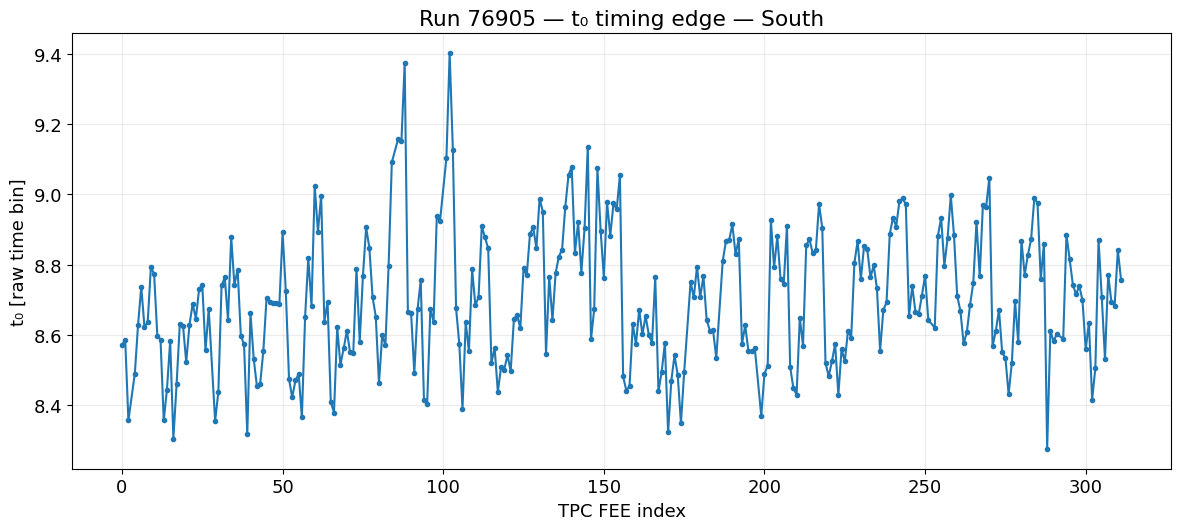

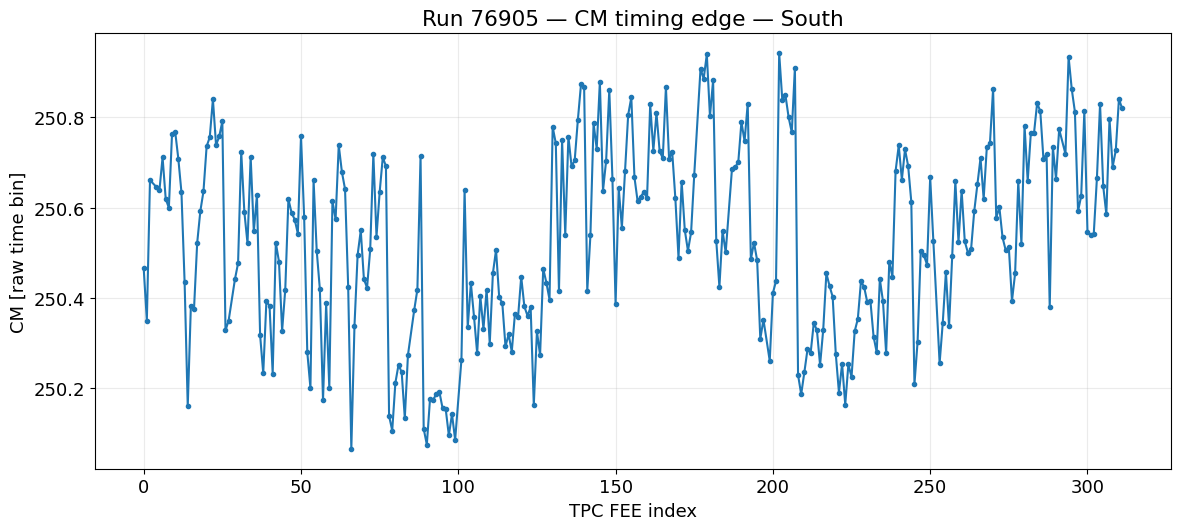

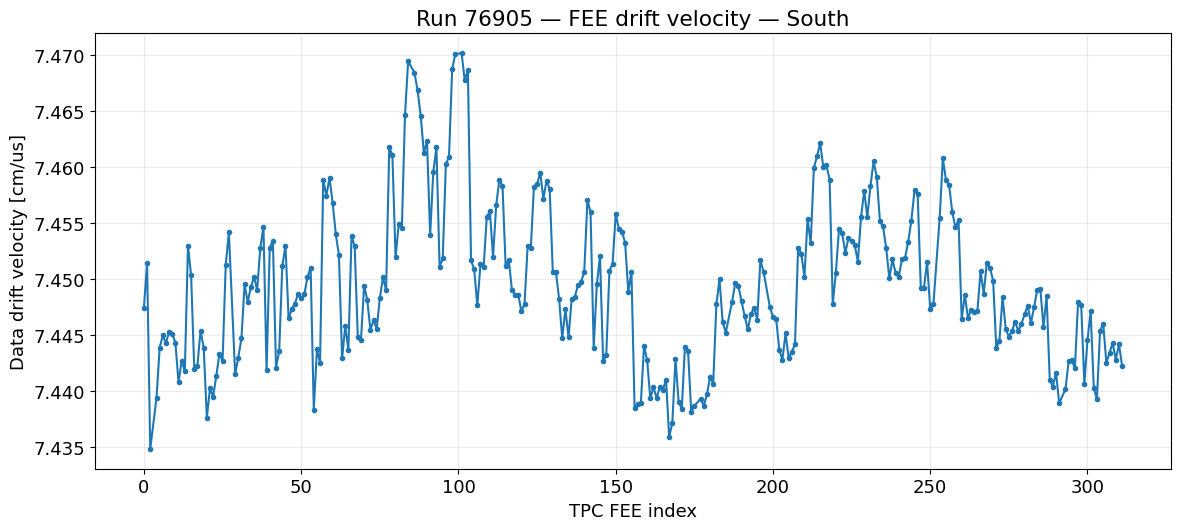

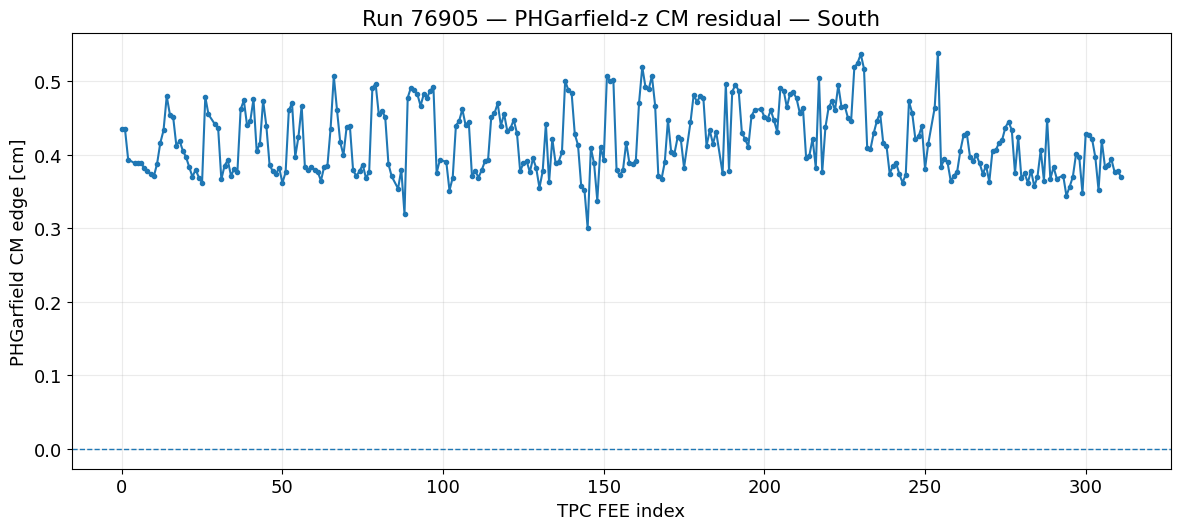

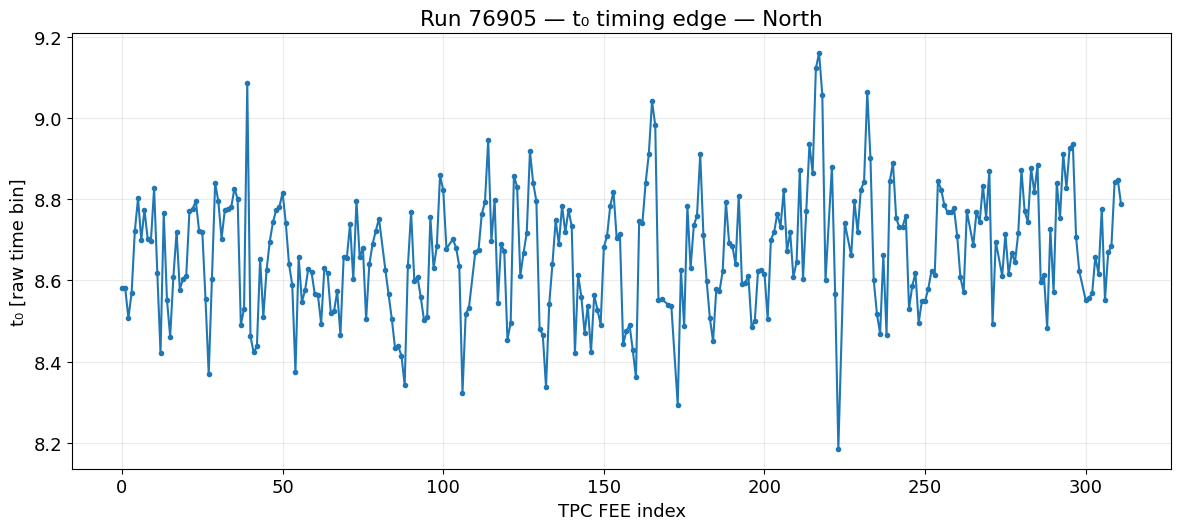

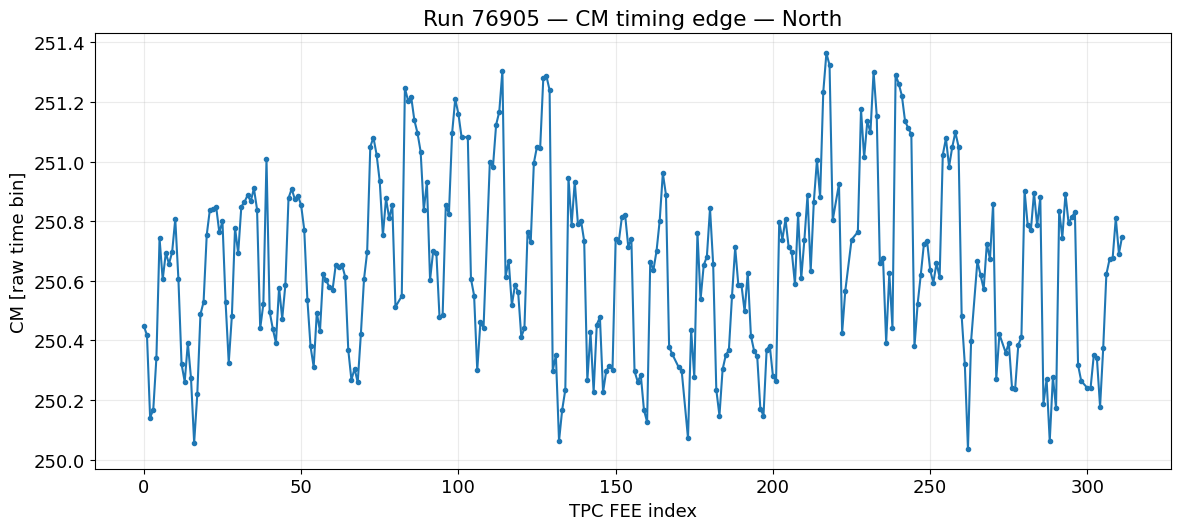

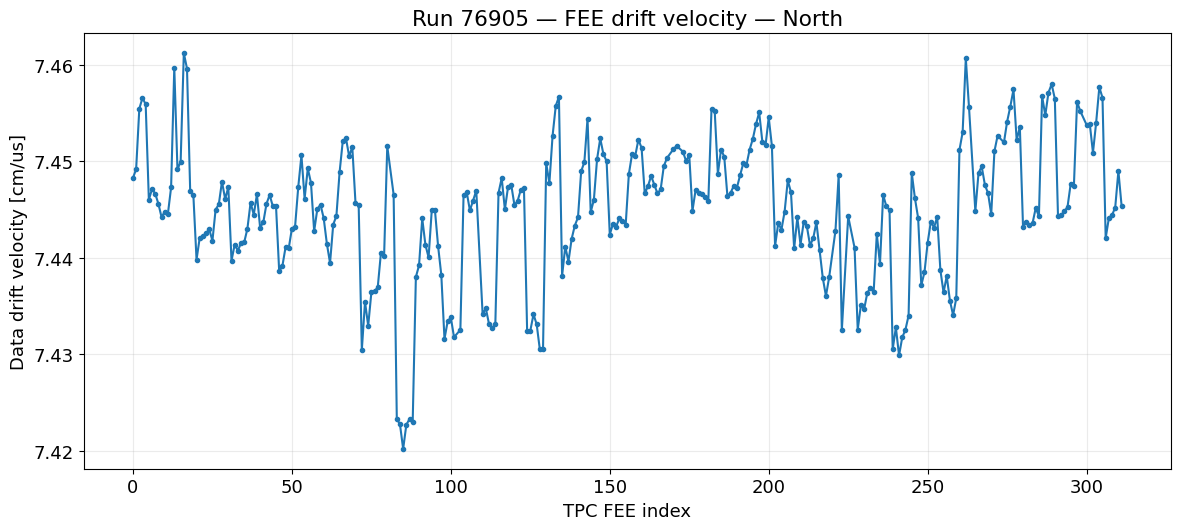

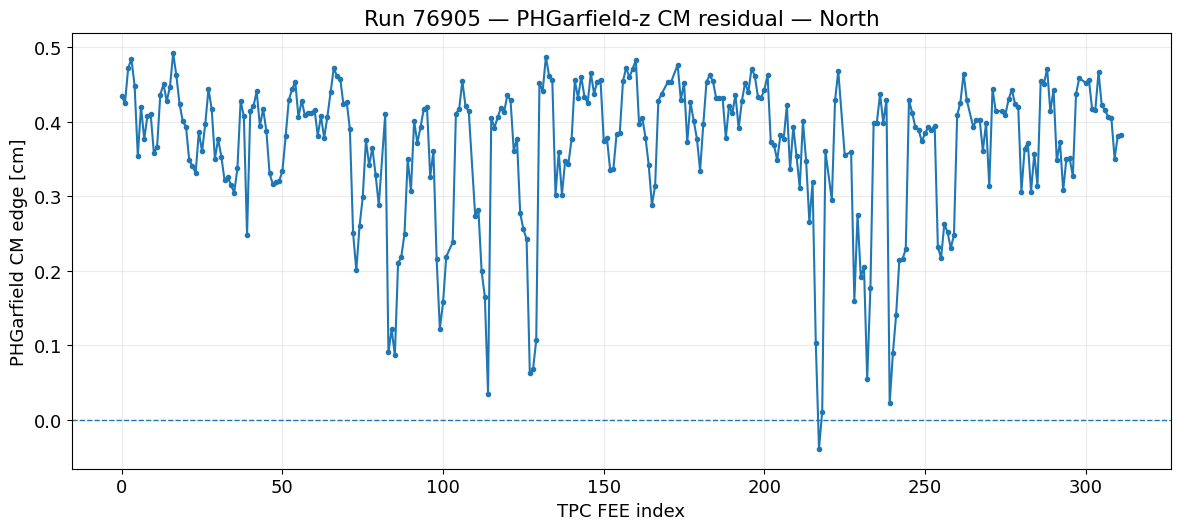

In [33]:
# ============================================================
# 13. Choose one run and inspect FEE-to-FEE calibration
# ============================================================

FEE_RUN = AVAILABLE_RUNS[0]   # edit as needed

for side in (0, 1):
    dfm = fee_edge_table(FEE_RUN, side)
    if dfm.empty:
        continue

    # Each quantity gets its own figure and independent y-axis.
    for quantity, ylabel, title, fname in [
        ("t0_bin", "t₀ [raw time bin]", "t₀ timing edge", "fees_t0"),
        ("cm_bin", "CM [raw time bin]", "CM timing edge", "fees_cm"),
        (
            "vdrift_cm_us",
            "Data drift velocity [cm/us]",
            "FEE drift velocity",
            "fees_vdrift",
        ),
        (
            "z_cm_edge_cm",
            "PHGarfield CM edge [cm]",
            "PHGarfield-z CM residual",
            "fees_zcm",
        ),
    ]:
        fig, ax = plt.subplots(figsize=(12, 5.5))

        ax.plot(dfm["fee"], dfm[quantity], "o-", ms=3)

        if quantity == "z_cm_edge_cm":
            ax.axhline(0.0, ls="--", lw=1)

        ax.set_xlabel("TPC FEE index")
        ax.set_ylabel(ylabel)
        ax.set_title(f"Run {FEE_RUN} — {title} — {SIDE_LABEL[side]}")
        fig.tight_layout()

        if SAVE_FIGURES:
            fig.savefig(
                OUTPUT_DIR / f"{fname}_run{FEE_RUN}_side{side}.png",
                dpi=160,
            )

        plt.show()

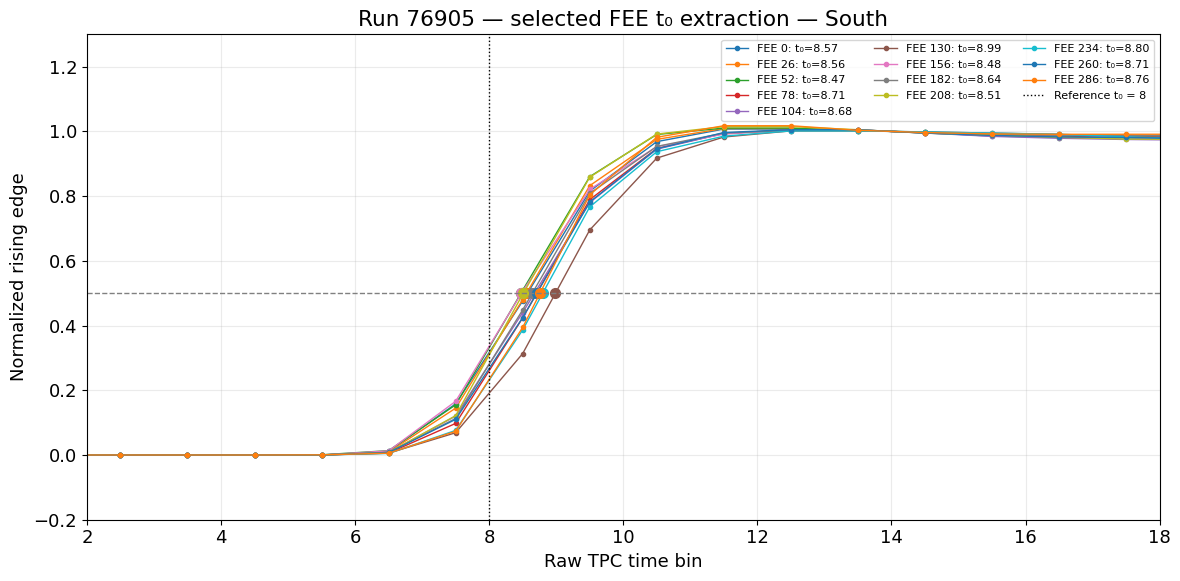

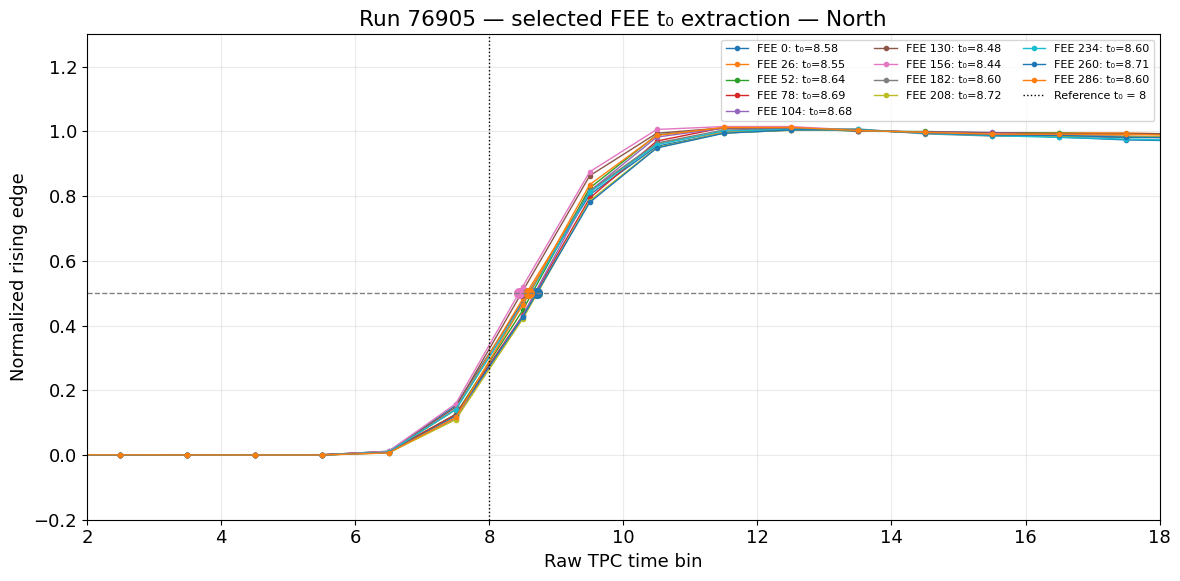

In [42]:
# ============================================================
# Selected FEEs: inspect the rising t0 edge
# ============================================================

SELECTED_RUN = AVAILABLE_RUNS[0]

LOCAL_FEE = 0                # choose 0–25
SELECTED_FEES = [26 * sector + LOCAL_FEE for sector in range(12)]
# SELECTED_FEES = [0, 10, 25, 80, 150, 250, 311]

for side in (0, 1):
    if side not in DATA[SELECTED_RUN]["time_fee"]:
        continue

    fees, t, time2d, labels = DATA[SELECTED_RUN]["time_fee"][side]

    fig, ax = plt.subplots(figsize=(12, 6))

    for fee in SELECTED_FEES:
        matches = np.flatnonzero(np.isclose(fees, fee))
        if not len(matches):
            print(f"Skip FEE {fee}: outside histogram range")
            continue

        y = time2d[:, matches[0]]
        if np.sum(y) <= 0:
            continue

        edge = edge_metrics(
            t, y,
            T0_LEFT_LEVEL, T0_RIGHT_LEVEL,
            T0_SEARCH, expected=T0_EXPECTED,
        )

        # Normalize the rising edge: baseline = 0, signal level = 1.
        yn = normalize_between_levels(
            display_clean(y),
            edge["left_level"],
            edge["right_level"],
        )

        if not np.any(np.isfinite(yn)):
            continue

        line, = ax.plot(
            t, yn, "o-", ms=3, lw=1,
            label=f"FEE {fee}: t₀={edge['x50']:.2f}",
        )

        if np.isfinite(edge["x50"]):
            ax.plot(
                edge["x50"], 0.5, "o",
                color=line.get_color(), ms=7,
            )

    ax.axhline(0.5, ls="--", color="gray", lw=1)
    ax.axvline(
        T0_EXPECTED, ls=":", color="black", lw=1,
        label=f"Reference t₀ = {T0_EXPECTED:g}",
    )

    ax.set_xlim(*T0_ZOOM)
    ax.set_ylim(-0.2, 1.3)
    ax.set_xlabel("Raw TPC time bin")
    ax.set_ylabel("Normalized rising edge")
    ax.set_title(
        f"Run {SELECTED_RUN} — selected FEE t₀ extraction — "
        f"{SIDE_LABEL[side]}"
    )
    ax.legend(fontsize=8, ncol=3)
    fig.tight_layout()

    if SAVE_FIGURES:
        fig.savefig(
            OUTPUT_DIR / f"selected_fees_t0_run{SELECTED_RUN}_side{side}.png",
            dpi=170,
        )

    plt.show()

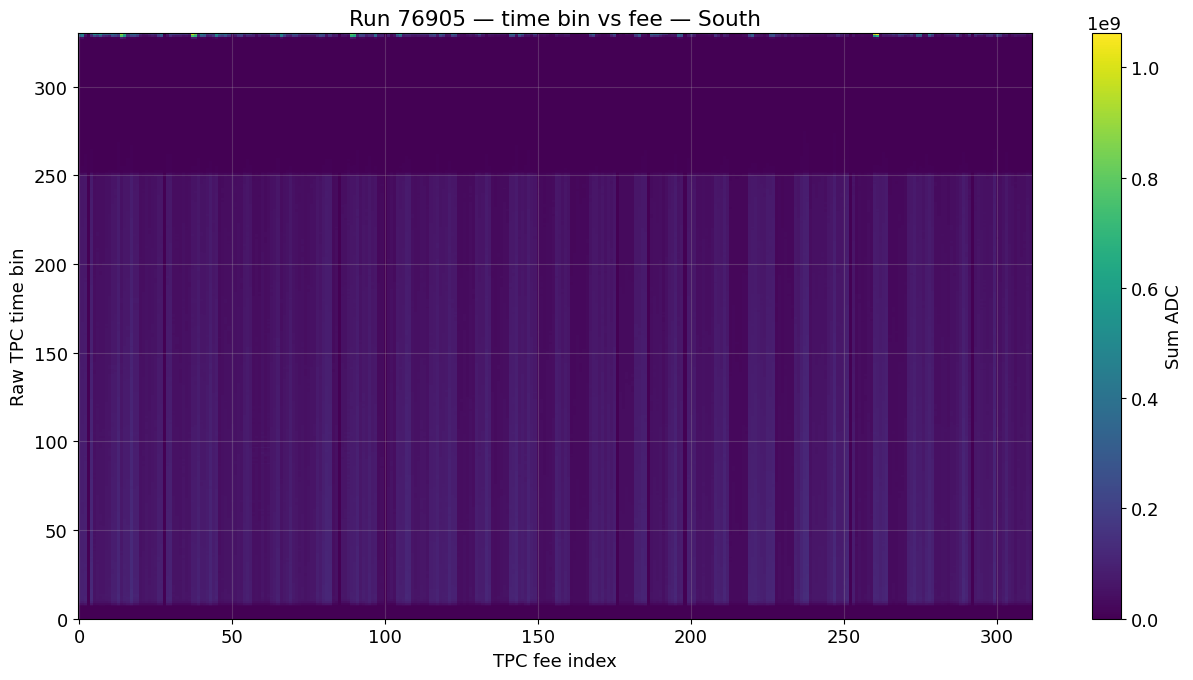

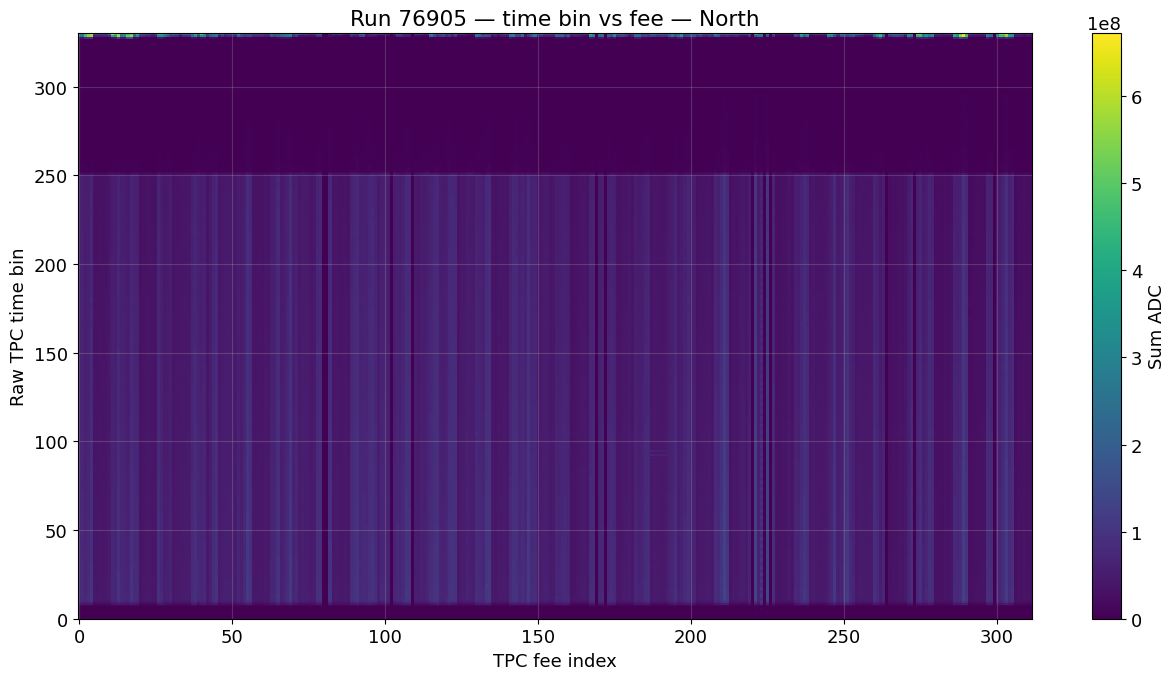

In [31]:

# ============================================================
# 14. Optional: show the actual 2D time-bin vs fee QA
# ============================================================

HEATMAP_RUN = FEE_RUN

for side in (0, 1):
    if side not in DATA[HEATMAP_RUN]["time_fee"]:
        continue

    fees, t, values, labels = DATA[HEATMAP_RUN]["time_fee"][side]

    fig, ax = plt.subplots(figsize=(13, 7))
    pcm = ax.pcolormesh(
        np.arange(values.shape[1] + 1) - 0.5,
        np.arange(values.shape[0] + 1),
        values,
        shading="auto",
    )
    fig.colorbar(pcm, ax=ax, label="Sum ADC")

    ax.set_ylim(0, 330)
    ax.set_xlabel("TPC fee index")
    ax.set_ylabel("Raw TPC time bin")
    ax.set_title(f"Run {HEATMAP_RUN} — time bin vs fee — {SIDE_LABEL[side]}")
    fig.tight_layout()

    if SAVE_FIGURES:
        fig.savefig(OUTPUT_DIR / f"time_vs_fee_run{HEATMAP_RUN}_side{side}.png", dpi=160)

    plt.show()



## First checks

1. **p+p background fit:** it should follow only the smooth out-of-drift component after the CM edge. If it follows physical structure, tighten `TIME_BG_WINDOWS`.
2. **\(t_0\):** compare the 50% rising-edge position between runs and South/North. The nominal PHGarfield reference is bin 8; the data value is measured independently.
3. **CM time:** compare the falling edge around \(\sim260\).
4. **Data drift velocity:** always use \(t_{\rm CM}-t_0\), not the absolute CM time.
5. **PHGarfield \(z\):** the CM edge should approach \(u=0\) when the run-dependent \(P/T\)-corrected drift mapping describes the data.
6. **FEEs:** abnormal fee \(t_0\), CM time, or \(z_{\rm CM}\) values can be isolated before forming the final calibration.

All numerical windows are intentionally centralized in the top configuration cell.
